### Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import os
from sentence_transformers import SentenceTransformer, util
import matplotlib.gridspec as gridspec
from nrclex import NRCLex

In [3]:
BASE = '/Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing'

folders = [
    f'{BASE}/data',
    f'{BASE}/data/modified',
    f'{BASE}/viz',
    f'{BASE}/viz/task1_social_impact',
    f'{BASE}/viz/task2_sentiment',
    f'{BASE}/viz/task3_emotion',
    f'{BASE}/viz/task4_eda',
    f'{BASE}/viz/task5_regression',
    f'{BASE}/models',
    f'{BASE}/outputs',
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✓ {folder}")

print("\nWorkspace ready.")

✓ /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/data
✓ /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/data/modified
✓ /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz
✓ /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task1_social_impact
✓ /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task2_sentiment
✓ /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task3_emotion
✓ /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task4_eda
✓ /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression
✓ /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/models
✓ /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/out

In [4]:
DATA    = f'{BASE}/data'
MOD     = f'{BASE}/data/modified'
VIZ1    = f'{BASE}/viz/task1_social_impact'
VIZ2    = f'{BASE}/viz/task2_sentiment'
VIZ3    = f'{BASE}/viz/task3_emotion'
VIZ4    = f'{BASE}/viz/task4_eda'
VIZ5    = f'{BASE}/viz/task5_regression'
MODELS  = f'{BASE}/models'
OUTPUTS = f'{BASE}/outputs'

print("Paths configured.")

Paths configured.


In [5]:
df = pd.read_csv(f'{DATA}/etsy.csv')

### Task 1 - SocialImpact Binary Variable

In [6]:
exclusion_patterns = [
    r'giveaway/donation',
    r'for profit or non.profit use',
    r'profit or non.profit',
    r'shelter the.*feet',
    r'shelter.*delicate',
    r'shelter.*baby',
    r'support\s+(our|my|a\s+small)\s+(family|business)',
    r'non.profit use only',
    r'personal or non.profit',
    r'foundation\s+(of\s+)?(the\s+)?(headband|crown|makeup|base|polish)',
    r'charity\s+events?',
    r'needed\s+a\s+(game|item)\s+for\s+a\s+fundraiser',
    r'money\s+will\s+be\s+refunded',
    r'fundrais\w+\s+promotion',
    r'dog\s+rescue\s+(business|themed|inspired)',
    r'contributes?\s+to\s+(good\s+posture|development|balance|muscle|barefoot|foot)',
    r'contributes?\s+to\s+(making|each|the\s+unique)',
    r'contributes?\s+towards?\s+the\s+maximum\s+barefoot',
    r'contributing\s+to\s+(the\s+most|your|my)',
    r'support\w*\s+a\s+local\s+family',
    r'dog\s+rescue\s+.{0,20}business',          # "dog rescue business" in customer review
    r'charitor\s+cab',                            # gemstone term, not charity
    r'money\s+will\s+go\s+towards\s+(more\s+)?treats',
    r'benevolent\s+dove',
]

In [7]:
# =============================================================================
# TIER 1: Donation-specific — explicit giving of money/proceeds
# =============================================================================

tier1_donation = [
    r'i\s+will\s+donat\w*',
    r'we\s+(will\s+)?donat\w*',
    r'donat\w*\s+(to|a\s+portion|all|proceeds|\d+%|percent|back)',
    r'donat\w*\s+(every|each|per)\s+(sale|purchase|order|item)',
    r'\d+\s*%\s*(of\s+)?(all\s+)?(proceeds|profits|sales|revenue|purchase)',
    r'(all|every|each)\s+(proceeds|profits|sales|revenue)\s+(go|are|will\s+be)\s+(donated|given)',
    r'portion\s+of\s+(the\s+)?(proceeds|profits|sales|revenue|every\s+sale|each\s+sale)',
    r'part\s+of\s+(the\s+)?(proceeds|profits|sales|revenue)',
    r'percentage\s+of\s+(the\s+)?(proceeds|profits|sales|revenue)',
    r'proceeds\s+(go|will|are|benefit|donated|support|from\s+sales)',
    r'all\s+proceeds\s+(go|will|are|benefit|donated)',
    r'every\s+(sale|purchase|order|item).{0,40}(donated|goes\s+to|benefit|support)',
    r'(sale|purchase|order|item).{0,40}(help|benefit|support).{0,40}(charity|rescue|fund|nonprofit)',
    r'fundrais\w+\s+(week|campaign|drive|event|initiative|effort)',
    r'i\s+will\s+fundrais\w*',
    r'we\s+(are\s+)?fundrais\w*',
    r'give\s+(a\s+)?(percentage|portion|part|percent|\d+%)',
    r'giving\s+(back\s+)?(a\s+)?(percentage|portion|part|percent|\d+%)',
    r'money\s+(go|will|goes|donated|raised).{0,30}(charity|rescue|fund|nonprofit|cause)',
    r'sales?\s+(benefit|support|help\s+fund|go\s+to|donated\s+to)',
    r'purchase\s+(benefit|support|help\s+fund|go\s+to|donated\s+to)',
    r'profit\w*\s+(go|are|will\s+be)\s+(donated|given|contributed)',
    r'gives?\s+\d+\s+meals?',
    r'feed\s+(an?\s+)?(infant|child|family|person)',
]

In [8]:
# =============================================================================
# TIER 2: Charity/organization-specific
# =============================================================================
tier2_charity = [
    r'\bcharit\w+\b',
    r'\bnonprofit\b',
    r'\bnon-profit\b',
    r'\bnot-for-profit\b',
    r'\b501\s*\(?\s*c\s*\)?\b',
    r'\bphilanthrop\w+\b',
    r'\bhumanitarian\b',
    r'\bngo\b',
    r'charitable\s+(organization|cause|giving|work|fund|donation|act|purpose)',
    r'charitable\s+contribution',
    r'registered\s+(charity|nonprofit|non-profit|foundation)',
    r'\bfoundation\b.{0,30}(donat|charity|nonprofit|proceeds|fund)',
    r'(donat|proceeds|fund).{0,30}\bfoundation\b',
    r'in\s+partnership\s+with\s+(a\s+)?(charity|nonprofit|foundation|rescue|shelter)',
    r'partner\w*\s+with\s+(a\s+)?(charity|nonprofit|foundation|rescue)',
]


In [9]:
# =============================================================================
# TIER 3: Cause-related
# =============================================================================
tier3_cause = [
    r'\bgive\s+back\b',
    r'\bgiving\s+back\b',
    r'animal\s+(rescue|shelter|welfare|sanctuary|conservation|rights)',
    r'dog\s+(rescue|shelter|sanctuary|adoption)',
    r'cat\s+(rescue|shelter|sanctuary|adoption)',
    r'pet\s+(rescue|shelter|adoption|welfare)',
    r'wildlife\s+(conservation|rescue|protection|sanctuary)',
    r'raising\s+awareness',
    r'awareness\s+of\s+(mental|physical|health|cancer|disease|illness)',
    r'mental\s+health\s+(awareness|cause|fund|initiative)',
    r'cancer\s+(research|fund|awareness|charity)',
    r'medical\s+(bills|fund|expenses|care|research)',
    r'memorial\s+fund',
    r'food\s+(bank|pantry|insecurity)',
    r'hunger\s+(relief|fund|initiative)',
    r'clean\s+(water|clothes)\s+(campaign|fund|initiative)',
    r'social\s+(impact|good|mission|cause)',
    r'community\s+(fund|initiative|benefit|development|outreach)',
    r'fair\s+trade\s+(certified|organization|fund|employment|wages)',
    r'sustainable\s+(and\s+)?well.paid\s+jobs',
    r'preservation\s+of\s+(traditional\s+)?artisan',
    r'girl\s+up',
    r'hope\s+for\s+paws',
    r'jack\s+vasel',
    r'30\s+millions?\s+d.amis',
    r'clean\s+clothes\s+campaign',
    r'milk\s+bank',
    r'old\s+dog\s+haven',
    r'queen.s\s+best\s+stumpy',
    r'american\s+cancer\s+society',
    r'stuffed\s+animal\s+fund',
    # Environmental social impact — deliberate sustainability commitment
    r'(all|our)\s+(packaging|materials)\s+(is|are)\s+(100%\s+)?recycled',
    r'recycled.{0,20}packaging.{0,20}recycled',
    r'do\s+not\s+wish\s+to\s+contribute\s+to\s+the\s+loss\s+of\s+our\s+natural\s+resources',
]

In [10]:
all_patterns = tier1_donation + tier2_charity + tier3_cause
combined_pattern = '|'.join(all_patterns)

In [11]:
def is_social_impact(text):
    text_lower = str(text).lower()
    if not re.search(combined_pattern, text_lower):
        return 0
    if any(re.search(p, text_lower) for p in exclusion_patterns):
        return 0
    return 1

print("Computing SocialImpact...")
df['SocialImpact'] = df['description'].apply(is_social_impact)

total = len(df)
si1   = df['SocialImpact'].sum()
si0   = total - si1

print(f"\n{'='*55}")
print(f"      SocialImpact — Final Verified Summary")
print(f"{'='*55}")
print(f"  SocialImpact = 1:  {si1:>6,}  ({si1/total*100:.2f}%)")
print(f"  SocialImpact = 0:  {si0:>6,}  ({si0/total*100:.2f}%)")
print(f"  Total:             {total:>6,}")
print(f"{'='*55}")

Computing SocialImpact...

      SocialImpact — Final Verified Summary
  SocialImpact = 1:      35  (0.34%)
  SocialImpact = 0:  10,371  (99.66%)
  Total:             10,406


In [12]:
# To verify all flagged listings
si1_listings = df[df['SocialImpact']==1][['name','description']].reset_index(drop=True)
print(f"\nAll SocialImpact=1 listings ({len(si1_listings)} total):")
for i, row in si1_listings.iterrows():
    print(f"\n{'='*70}")
    print(f"#{i+1} | {row['name'][:80]}")
    print(f"{'-'*70}")
    print(row['description'][:300])


All SocialImpact=1 listings (35 total):

#1 | Weddings - Matching/co-ordinating Girls & Grooms men Cravats, Hankies/Bridesmaid
----------------------------------------------------------------------
Beautiful Silk Designs Originally made for your Special DAY
& for those loved ones around you.  

We Help to design or realize your WEDDING & Special Occasion dream ideas; any suggestions at all we will help you choose and guide you through pitfalls and pleasantries!

Just Convo me or Email me Direc

#2 | Skull Bobby Hair Pin - Express Yourself!
----------------------------------------------------------------------
Add Style and Personality to Your Hair Today!

• The perfect hair accessory with endless uses
• Secures your hair and completes the perfect hairstyle
• About 2.25 inches long
• Contact us for the 3 inch long U shape bun pin version
• Experienced seller with excellent reviews
• Handmade in the USA
• 

#3 | CustomDog Portrait, 8x10 Pet Portrait, Custom Pet Portrait, Painted Pet Por

In [13]:
df.to_csv(f'{MOD}/etsy_master.csv', index=False)
print(f"Saved: {MOD}/etsy_master.csv")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/data/modified/etsy_master.csv


### Task 2 - HandMade Binary Variable

In [14]:
df = pd.read_csv(f'{MOD}/etsy_master.csv')

In [15]:
tier1_handmade = [
    r'\bhandmade\b',
    r'\bhand-made\b',
    r'\bhand\s+made\b',
]

tier2_craft = [
    r'\bhandcrafted\b',
    r'\bhand-crafted\b',
    r'\bhand\s+crafted\b',
    r'\bhandbuilt\b',
    r'\bhand-built\b',
    r'\bhand\s+built\b',
]

tier3_technique = [
    r'\bhand\s+sewn\b',
    r'\bhand-sewn\b',
    r'\bhand\s+painted\b',
    r'\bhand-painted\b',
    r'\bhand\s+knitted\b',
    r'\bhand-knitted\b',
    r'\bhand\s+knit\b',
    r'\bhand\s+embroidered\b',
    r'\bhand-embroidered\b',
    r'\bhand\s+stitched\b',
    r'\bhand-stitched\b',
    r'\bhand\s+woven\b',
    r'\bhand-woven\b',
    r'\bhand\s+beaded\b',
    r'\bhand-beaded\b',
    r'\bhand\s+carved\b',
    r'\bhand-carved\b',
    r'\bhand\s+stamped\b',
    r'\bhand-stamped\b',
    r'\bhand\s+printed\b',
    r'\bhand-printed\b',
    r'\bmade\s+by\s+hand\b',
    r'\bmade\s+by\s+(me|us)\s+by\s+hand\b',
]

In [16]:
all_patterns     = tier1_handmade + tier2_craft + tier3_technique
combined_pattern = '|'.join(all_patterns)

In [17]:
df['Handmade'] = (
    df['description']
    .str.lower()
    .str.contains(combined_pattern, regex=True, na=False)
    .astype(int)
)

/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_1845/1473592387.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(combined_pattern, regex=True, na=False)


In [18]:
total = len(df)
hm1   = df['Handmade'].sum()
hm0   = total - hm1

print(f"\n{'='*55}")
print(f"         Handmade Variable Summary")
print(f"{'='*55}")
print(f"  Handmade = 1:  {hm1:>6,}  ({hm1/total*100:.2f}%)")
print(f"  Handmade = 0:  {hm0:>6,}  ({hm0/total*100:.2f}%)")
print(f"  Total:         {total:>6,}")
print(f"{'='*55}")


         Handmade Variable Summary
  Handmade = 1:   3,671  (35.28%)
  Handmade = 0:   6,735  (64.72%)
  Total:         10,406


In [19]:
# =============================================================================
# Tier-level breakdown — which patterns contributed most
# =============================================================================
print("\nTier 1 — Direct handmade variants:")
for pat in tier1_handmade:
    count = df['description'].str.lower().str.contains(pat, regex=True, na=False).sum()
    if count > 0:
        print(f"  '{pat}': {count:,}")

print("\nTier 2 — Craft process variants:")
for pat in tier2_craft:
    count = df['description'].str.lower().str.contains(pat, regex=True, na=False).sum()
    if count > 0:
        print(f"  '{pat}': {count:,}")

print("\nTier 3 — Specific technique variants:")
for pat in tier3_technique:
    count = df['description'].str.lower().str.contains(pat, regex=True, na=False).sum()
    if count > 0:
        print(f"  '{pat}': {count:,}")


Tier 1 — Direct handmade variants:
  '\bhandmade\b': 2,612
  '\bhand-made\b': 47
  '\bhand\s+made\b': 304

Tier 2 — Craft process variants:
  '\bhandcrafted\b': 456
  '\bhand-crafted\b': 52
  '\bhand\s+crafted\b': 80

Tier 3 — Specific technique variants:
  '\bhand\s+sewn\b': 179
  '\bhand-sewn\b': 59
  '\bhand\s+painted\b': 140
  '\bhand-painted\b': 45
  '\bhand\s+knitted\b': 63
  '\bhand-knitted\b': 12
  '\bhand\s+knit\b': 35
  '\bhand\s+embroidered\b': 24
  '\bhand-embroidered\b': 4
  '\bhand\s+stitched\b': 50
  '\bhand-stitched\b': 15
  '\bhand\s+woven\b': 6
  '\bhand-woven\b': 4
  '\bhand\s+beaded\b': 52
  '\bhand-beaded\b': 6
  '\bhand\s+carved\b': 2
  '\bhand-carved\b': 1
  '\bhand\s+stamped\b': 20
  '\bhand-stamped\b': 26
  '\bhand\s+printed\b': 14
  '\bhand-printed\b': 6
  '\bmade\s+by\s+hand\b': 125


/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_1845/598830076.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = df['description'].str.lower().str.contains(pat, regex=True, na=False).sum()


In [20]:
# =============================================================================
# Overlap check — how many listings are both Handmade=1 AND SocialImpact=1 to check cause for multicollinearity
# =============================================================================
df_check = pd.read_csv(f'{MOD}/etsy_master.csv')[['SocialImpact']].copy()
df_check['Handmade'] = df['Handmade'].values

overlap = ((df_check['Handmade']==1) & (df_check['SocialImpact']==1)).sum()
print(f"\n{'='*55}")
print(f"Overlap Check")
print(f"{'='*55}")
print(f"  Handmade=1 AND SocialImpact=1: {overlap:,} listings")
print(f"  % of SocialImpact=1 that are also Handmade: "
      f"{overlap/df_check['SocialImpact'].sum()*100:.1f}%")
print(f"  % of Handmade=1 that are also SocialImpact: "
      f"{overlap/df_check['Handmade'].sum()*100:.1f}%")
print(f"  Correlation: "
      f"{df_check['Handmade'].corr(df_check['SocialImpact']):.4f}")


Overlap Check
  Handmade=1 AND SocialImpact=1: 10 listings
  % of SocialImpact=1 that are also Handmade: 28.6%
  % of Handmade=1 that are also SocialImpact: 0.3%
  Correlation: -0.0082


In [21]:
# =============================================================================
# check to verify quality
# =============================================================================
print(f"\n{'='*70}")
print("Spot Check — 10 Random Handmade=1 Listings")
print(f"{'='*70}")
sample = df[df['Handmade']==1][['name','description']].sample(10, random_state=42)
for i, (_, row) in enumerate(sample.iterrows(), 1):
    # Find matched keyword
    desc_lower = row['description'].lower()
    matched = next((p for p in all_patterns
                    if re.search(p, desc_lower)), 'unknown')
    print(f"\n#{i} | Matched: '{matched}'")
    print(f"  {row['name'][:80]}")
    print(f"  {row['description'][:200]}...")



Spot Check — 10 Random Handmade=1 Listings

#1 | Matched: '\bhandcrafted\b'
  As Seen on Reign | Lace Pearl Bridal Crown | Vintage Inspired Wedding Tiara | We
  &quot;Orange Blossom&quot; Crown
Inspired by traditional orange blossom bridal tiaras, the Orange Blossom Crown blends pretty, handcrafted lace flowers with delicate wired vines and freshwater pearls ...

#2 | Matched: '\bhandmade\b'
  TUSK LEATHER Sandals Tan Slingback no strap | Womens Leather Sandals / Womens Sh
  Beautiful Soft Leather Slingback no strap, handmade by our amazing team of shoemakers in the tropical island of Bali. 

We do not mass produce our collection through large factories - i.e China

We ar...

#3 | Matched: '\bhandmade\b'
  Baby Bunny Booties. crochet baby booties. Easter gift for baby girl. Baby easter
  These lovely Bunny booties will not only keep Babies feet warm but will look so cute as well. They are made by myself out of a soft acrylic yarn. The soles are dusky pink to co-ordinate with Bunnies e

In [22]:
master = pd.read_csv(f'{MOD}/etsy_master.csv')
master['Handmade'] = df['Handmade'].values
master.to_csv(f'{MOD}/etsy_master.csv', index=False)
print(f"Saved: {MOD}/etsy_master.csv")
print(f"Columns: {master.columns.tolist()}")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/data/modified/etsy_master.csv
Columns: ['url', 'name', 'price', 'currency', 'availability', 'description', 'category', 'brand', 'average_rating', 'reviews_count', 'images', 'product_details', 'scraped_at', 'SocialImpact', 'Handmade']


### Task 3 - Feature Extraction (Lexical Div, FP Ratio, Readability, Personalization, Trust Factor)

In [23]:
import textstat

In [24]:
df = pd.read_csv(f'{MOD}/etsy_master.csv')
print(f"Loaded: {df.shape[0]:,} rows")

Loaded: 10,406 rows


In [25]:
def lexical_diversity(text):
    words = str(text).lower().split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df['lexical_diversity'] = df['description'].apply(lexical_diversity)
print(f"\n✓ Lexical Diversity computed")
print(f"  Mean:   {df['lexical_diversity'].mean():.4f}")
print(f"  Median: {df['lexical_diversity'].median():.4f}")
print(f"  Std:    {df['lexical_diversity'].std():.4f}")



✓ Lexical Diversity computed
  Mean:   0.6904
  Median: 0.6860
  Std:    0.1163


In [26]:
def first_person_ratio(text):
    words       = str(text).lower().split()
    first_person = ['i', 'me', 'my', 'mine', 'myself']
    count_fp    = sum(word in first_person for word in words)
    return count_fp / len(words) if len(words) > 0 else 0

df['first_person_ratio'] = df['description'].apply(first_person_ratio)
print(f"\n✓ First Person Ratio computed")
print(f"  Mean:   {df['first_person_ratio'].mean():.4f}")
print(f"  Median: {df['first_person_ratio'].median():.4f}")
print(f"  Std:    {df['first_person_ratio'].std():.4f}")


✓ First Person Ratio computed
  Mean:   0.0121
  Median: 0.0072
  Std:    0.0150


In [27]:
def readability_score(text):
    try:
        return textstat.flesch_reading_ease(str(text))
    except:
        return np.nan

df['readability_score'] = df['description'].apply(readability_score)
print(f"\n✓ Readability Score (Flesch Reading Ease) computed")
print(f"  Mean:   {df['readability_score'].mean():.4f}")
print(f"  Median: {df['readability_score'].median():.4f}")
print(f"  Std:    {df['readability_score'].std():.4f}")
print(f"  Min:    {df['readability_score'].min():.4f}")
print(f"  Max:    {df['readability_score'].max():.4f}")


✓ Readability Score (Flesch Reading Ease) computed
  Mean:   61.1267
  Median: 62.7773
  Std:    14.7597
  Min:    -138.5350
  Max:    121.2200


In [28]:
personalization_patterns = [
    r'\bcustom(iz|is)ed?\b',
    r'\bpersonali(z|s)ed?\b',
    r'\bmade\s+to\s+order\b',
    r'\bmade\s+for\s+you\b',
    r'\bmade\s+just\s+for\s+you\b',
    r'\byour\s+(name|initials|text|photo|choice|design)\b',
    r'\bchoose\s+your\b',
    r'\bpick\s+your\b',
    r'\bcustom\s+(order|design|made|gift|listing)\b',
    r'\bbespoke\b',
    r'\btailor(ed)?\s+(to|for)\s+you\b',
    r'\byour\s+own\s+design\b',
    r'\bone\s+of\s+a\s+kind\b',
    r'\bunique\s+to\s+you\b',
]

personalization_pattern = '|'.join(personalization_patterns)

In [29]:
df['personalization'] = (
    df['description']
    .str.lower()
    .str.contains(personalization_pattern, regex=True, na=False)
    .astype(int)
)

print(f"\n✓ Personalization Flagging computed")
print(f"  Personalization = 1: {df['personalization'].sum():,} "
      f"({df['personalization'].mean()*100:.2f}%)")
print(f"  Personalization = 0: {(df['personalization']==0).sum():,} "
      f"({(df['personalization']==0).mean()*100:.2f}%)")



✓ Personalization Flagging computed
  Personalization = 1: 3,709 (35.64%)
  Personalization = 0: 6,697 (64.36%)


/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_1845/2600743205.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(personalization_pattern, regex=True, na=False)


In [30]:
trust_patterns = [
    r'\bfree\s+(returns?|shipping|delivery|exchange)\b',
    r'\bmoney\s+back\s+guarantee\b',
    r'\bfull\s+refund\b',
    r'\b100%\s+(satisfaction|refund|money\s+back)\b',
    r'\bsatisfaction\s+guaranteed\b',
    r'\bfast\s+(shipping|delivery|dispatch)\b',
    r'\bquick\s+(shipping|delivery|dispatch)\b',
    r'\bships?\s+(within|in)\s+\d+\s+(day|business)',
    r'\bsecure\s+(checkout|payment|transaction)\b',
    r'\btracked\s+(shipping|delivery|post)\b',
    r'\binsured\s+(shipping|delivery|post)\b',
    r'\bno\s+questions?\s+asked\b',
    r'\bhassle[\s-]free\s+(returns?|refund|exchange)\b',
    r'\bwarranty\b',
    r'\bguaranteed\b',
]

trust_pattern = '|'.join(trust_patterns)

In [31]:
df['trust_factor'] = (
    df['description']
    .str.lower()
    .str.contains(trust_pattern, regex=True, na=False)
    .astype(int)
)

print(f"\n✓ Trust Factor computed")
print(f"  Trust Factor = 1: {df['trust_factor'].sum():,} "
      f"({df['trust_factor'].mean()*100:.2f}%)")
print(f"  Trust Factor = 0: {(df['trust_factor']==0).sum():,} "
      f"({(df['trust_factor']==0).mean()*100:.2f}%)")

/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_1845/3472718333.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(trust_pattern, regex=True, na=False)



✓ Trust Factor computed
  Trust Factor = 1: 1,119 (10.75%)
  Trust Factor = 0: 9,287 (89.25%)


In [32]:
print(f"\n{'='*60}")
print("Task 3b — Linguistic Features Summary")
print(f"{'='*60}")
print(f"  {'Feature':<25} {'Type':<12} {'Mean/Rate':>10}")
print(f"  {'-'*50}")
print(f"  {'Lexical Diversity':<25} {'Continuous':<12} "
      f"{df['lexical_diversity'].mean():>10.4f}")
print(f"  {'First Person Ratio':<25} {'Continuous':<12} "
      f"{df['first_person_ratio'].mean():>10.4f}")
print(f"  {'Readability Score':<25} {'Continuous':<12} "
      f"{df['readability_score'].mean():>10.4f}")
print(f"  {'Personalization':<25} {'Binary':<12} "
      f"{df['personalization'].mean()*100:>9.2f}%")
print(f"  {'Trust Factor':<25} {'Binary':<12} "
      f"{df['trust_factor'].mean()*100:>9.2f}%")


Task 3b — Linguistic Features Summary
  Feature                   Type          Mean/Rate
  --------------------------------------------------
  Lexical Diversity         Continuous       0.6904
  First Person Ratio        Continuous       0.0121
  Readability Score         Continuous      61.1267
  Personalization           Binary           35.64%
  Trust Factor              Binary           10.75%


In [33]:
df['LogReviewCount'] = np.log(df['reviews_count'] + 1)

print(f"\n{'='*60}")
print("Correlation with LogReviewCount")
print(f"{'='*60}")
ling_features = ['lexical_diversity', 'first_person_ratio',
                 'readability_score', 'personalization', 'trust_factor']
for feat in ling_features:
    corr = df[feat].corr(df['LogReviewCount'])
    print(f"  {feat:<25} r = {corr:>8.4f}")



Correlation with LogReviewCount
  lexical_diversity         r =  -0.1947
  first_person_ratio        r =   0.0207
  readability_score         r =  -0.0359
  personalization           r =   0.0775
  trust_factor              r =   0.1254


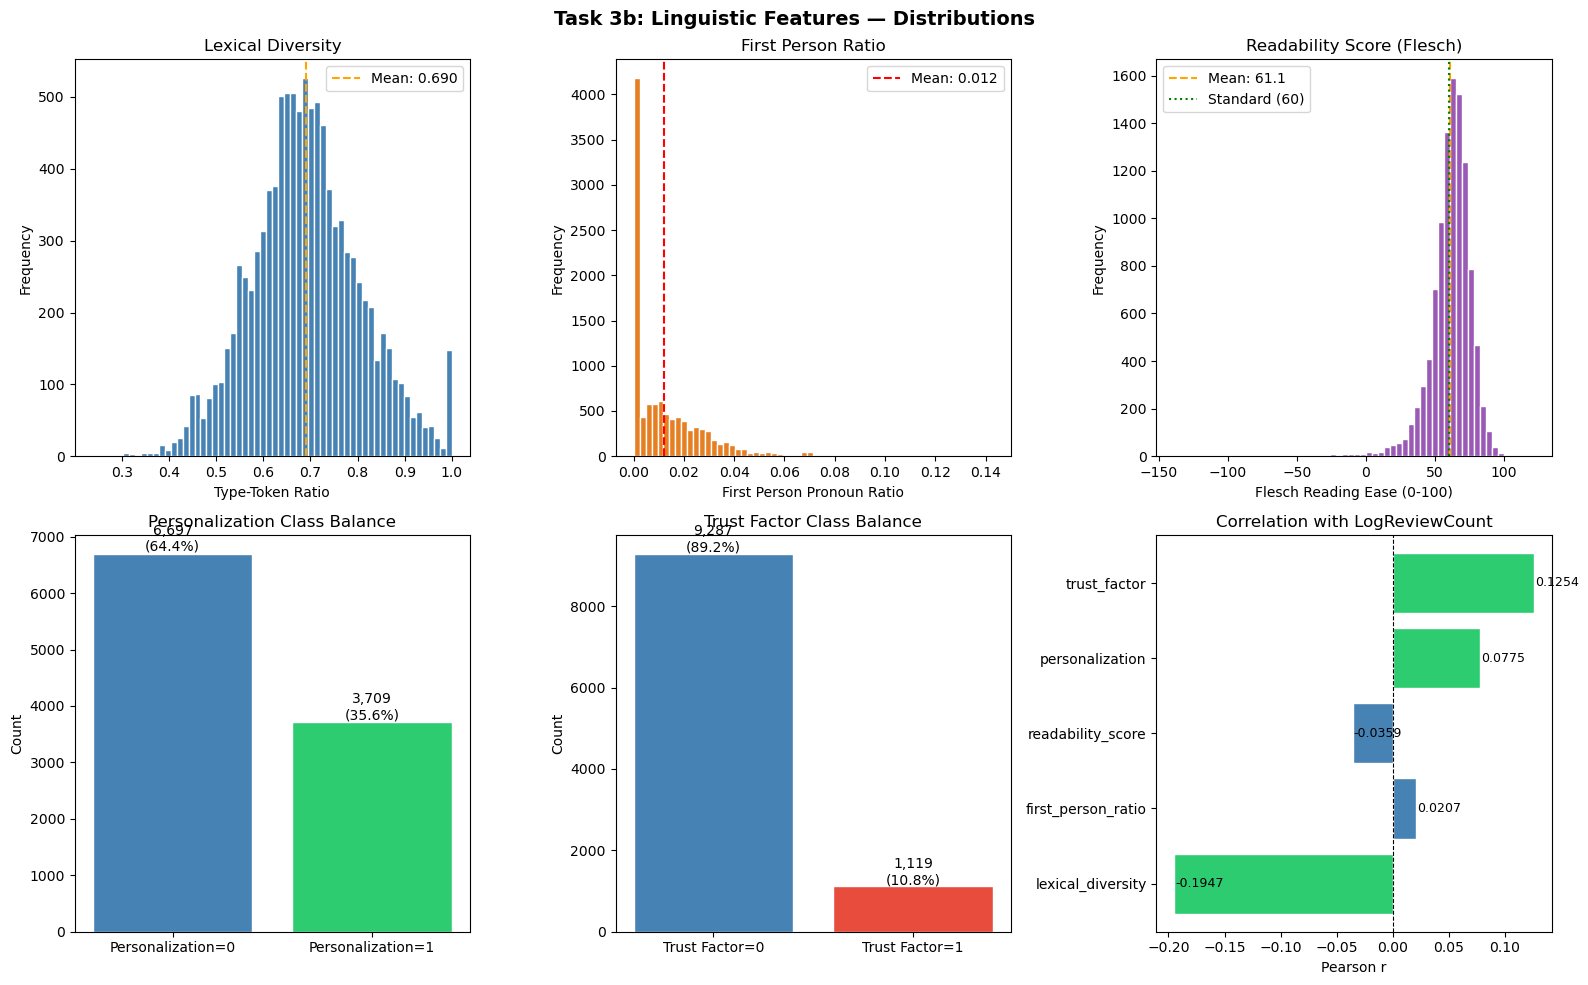


Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task3_emotion/linguistic_features.png


In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Task 3b: Linguistic Features — Distributions',
             fontsize=14, fontweight='bold')

# 1. Lexical Diversity
axes[0,0].hist(df['lexical_diversity'], bins=60,
               color='steelblue', edgecolor='white')
axes[0,0].axvline(df['lexical_diversity'].mean(), color='orange',
                   linestyle='--',
                   label=f"Mean: {df['lexical_diversity'].mean():.3f}")
axes[0,0].set_title('Lexical Diversity')
axes[0,0].set_xlabel('Type-Token Ratio')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# 2. First Person Ratio
axes[0,1].hist(df['first_person_ratio'], bins=60,
               color='#e67e22', edgecolor='white')
axes[0,1].axvline(df['first_person_ratio'].mean(), color='red',
                   linestyle='--',
                   label=f"Mean: {df['first_person_ratio'].mean():.3f}")
axes[0,1].set_title('First Person Ratio')
axes[0,1].set_xlabel('First Person Pronoun Ratio')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# 3. Readability Score
axes[0,2].hist(df['readability_score'].dropna(), bins=60,
               color='#9b59b6', edgecolor='white')
axes[0,2].axvline(df['readability_score'].mean(), color='orange',
                   linestyle='--',
                   label=f"Mean: {df['readability_score'].mean():.1f}")
axes[0,2].axvline(60, color='green', linestyle=':',
                   label='Standard (60)')
axes[0,2].set_title('Readability Score (Flesch)')
axes[0,2].set_xlabel('Flesch Reading Ease (0-100)')
axes[0,2].set_ylabel('Frequency')
axes[0,2].legend()

# 4. Personalization class balance
axes[1,0].bar(['Personalization=0', 'Personalization=1'],
               [(df['personalization']==0).sum(),
                df['personalization'].sum()],
               color=['steelblue', '#2ecc71'], edgecolor='white')
axes[1,0].set_title('Personalization Class Balance')
axes[1,0].set_ylabel('Count')
for i, v in enumerate([(df['personalization']==0).sum(),
                        df['personalization'].sum()]):
    axes[1,0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)',
                   ha='center', fontsize=10)

# 5. Trust Factor class balance
axes[1,1].bar(['Trust Factor=0', 'Trust Factor=1'],
               [(df['trust_factor']==0).sum(),
                df['trust_factor'].sum()],
               color=['steelblue', '#e74c3c'], edgecolor='white')
axes[1,1].set_title('Trust Factor Class Balance')
axes[1,1].set_ylabel('Count')
for i, v in enumerate([(df['trust_factor']==0).sum(),
                        df['trust_factor'].sum()]):
    axes[1,1].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)',
                   ha='center', fontsize=10)

# 6. Correlation bar chart
corrs = [df[f].corr(df['LogReviewCount']) for f in ling_features]
colors_corr = ['#2ecc71' if abs(c) > 0.05 else 'steelblue' for c in corrs]
axes[1,2].barh(ling_features, corrs,
               color=colors_corr, edgecolor='white')
axes[1,2].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,2].set_title('Correlation with LogReviewCount')
axes[1,2].set_xlabel('Pearson r')
for i, v in enumerate(corrs):
    axes[1,2].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{VIZ3}/linguistic_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved: {VIZ3}/linguistic_features.png")

In [35]:
# Clip readability to valid Flesch range
df['readability_score'] = df['readability_score'].clip(lower=0, upper=100)
print(f"Readability clipped — Min: {df['readability_score'].min():.2f}, "
      f"Max: {df['readability_score'].max():.2f}")
df.to_csv(f'{MOD}/etsy_master.csv', index=False)

Readability clipped — Min: 0.00, Max: 100.00


In [36]:
df.to_csv(f'{MOD}/etsy_master.csv', index=False)
print(f"Saved: {MOD}/etsy_master.csv")
print(f"\nNew columns added: {ling_features}")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/data/modified/etsy_master.csv

New columns added: ['lexical_diversity', 'first_person_ratio', 'readability_score', 'personalization', 'trust_factor']


### Task 4 - Sentiment Analysis

In [37]:
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [38]:
df = pd.read_csv(f'{MOD}/etsy_master.csv')
print(f"Loaded: {df.shape[0]:,} rows")

Loaded: 10,406 rows


In [39]:
analyzer = SentimentIntensityAnalyzer()

In [40]:
print("Computing sentiment scores...")

df['SentimentScore'] = df['description'].fillna('').apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

print("Done.")

print(f"\n{'='*50}")
print(f"        SentimentScore Summary")
print(f"{'='*50}")
print(f"  Mean:   {df['SentimentScore'].mean():.4f}")
print(f"  Median: {df['SentimentScore'].median():.4f}")
print(f"  Std:    {df['SentimentScore'].std():.4f}")
print(f"  Min:    {df['SentimentScore'].min():.4f}")
print(f"  Max:    {df['SentimentScore'].max():.4f}")

Computing sentiment scores...
Done.

        SentimentScore Summary
  Mean:   0.8964
  Median: 0.9752
  Std:    0.2187
  Min:    -0.9983
  Max:    0.9999


In [41]:
positive = (df['SentimentScore'] >  0.05).sum()
neutral  = (df['SentimentScore'].between(-0.05, 0.05)).sum()
negative = (df['SentimentScore'] < -0.05).sum()
total    = len(df)

print(f"\n  Positive (> 0.05):       {positive:>6,}  ({positive/total*100:.1f}%)")
print(f"  Neutral  (-0.05–0.05):   {neutral:>6,}  ({neutral/total*100:.1f}%)")
print(f"  Negative (< -0.05):      {negative:>6,}  ({negative/total*100:.1f}%)")
print(f"{'='*50}")


  Positive (> 0.05):       10,115  (97.2%)
  Neutral  (-0.05–0.05):      202  (1.9%)
  Negative (< -0.05):          89  (0.9%)


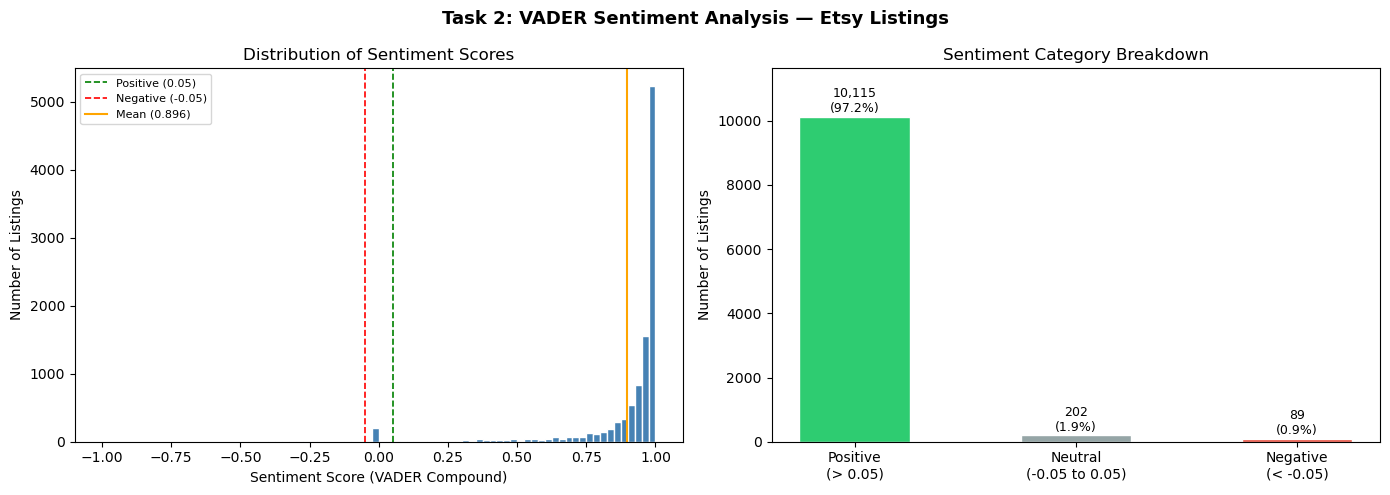

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task2_sentiment/sentiment_analysis.png


In [42]:
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0])
ax1.hist(df['SentimentScore'], bins=80, color='steelblue', edgecolor='white')
ax1.axvline(0.05,  color='green',  linestyle='--', linewidth=1.2, label='Positive (0.05)')
ax1.axvline(-0.05, color='red',    linestyle='--', linewidth=1.2, label='Negative (-0.05)')
ax1.axvline(df['SentimentScore'].mean(), color='orange', linestyle='-',
            linewidth=1.5, label=f"Mean ({df['SentimentScore'].mean():.3f})")
ax1.set_xlabel('Sentiment Score (VADER Compound)')
ax1.set_ylabel('Number of Listings')
ax1.set_title('Distribution of Sentiment Scores')
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[1])
labels  = ['Positive\n(> 0.05)', 'Neutral\n(-0.05 to 0.05)', 'Negative\n(< -0.05)']
counts  = [positive, neutral, negative]
colors  = ['#2ecc71', '#95a5a6', '#e74c3c']
bars    = ax2.bar(labels, counts, color=colors, edgecolor='white', width=0.5)
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}\n({count/total*100:.1f}%)',
             ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('Number of Listings')
ax2.set_title('Sentiment Category Breakdown')
ax2.set_ylim(0, max(counts) * 1.15)

plt.suptitle('Task 2: VADER Sentiment Analysis — Etsy Listings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ2}/sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ2}/sentiment_analysis.png")

In [43]:
df.to_csv(f'{MOD}/etsy_master.csv', index=False)
print(f"Saved: {MOD}/etsy_master.csv")
print(f"Columns: {df.columns.tolist()}")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/data/modified/etsy_master.csv
Columns: ['url', 'name', 'price', 'currency', 'availability', 'description', 'category', 'brand', 'average_rating', 'reviews_count', 'images', 'product_details', 'scraped_at', 'SocialImpact', 'Handmade', 'lexical_diversity', 'first_person_ratio', 'readability_score', 'personalization', 'trust_factor', 'LogReviewCount', 'SentimentScore']


### Task 5 - Emotion Analysis

In [44]:
df = pd.read_csv(f'{MOD}/etsy_master.csv')

In [45]:
EMOTIONS = ['joy', 'sadness', 'surprise', 'disgust', 'anger', 'fear']

In [46]:
_analyzer = NRCLex('happy')   # loading lexicon once with a dummy word
_lexicon  = _analyzer.__lexicon__

def get_emotion_scores(text):
    text = str(text).lower() if text else ''
    words = text.split()

    # Count emotion words using the cached lexicon
    raw = {}
    for word in words:
        if word in _lexicon:
            for emotion in _lexicon[word]:
                raw[emotion] = raw.get(emotion, 0) + 1

    total = sum(raw.values())
    return {e: raw.get(e, 0) / total if total > 0 else 0.0 for e in EMOTIONS}


In [47]:
emotion_scores = df['description'].apply(get_emotion_scores)
emotion_df     = pd.DataFrame(emotion_scores.tolist())

for e in EMOTIONS:
    df[f'emotion_{e}'] = emotion_df[e]

In [48]:
# -----------------------------------------------------------------------------
# Summary stats
# -----------------------------------------------------------------------------
print(f"\n{'='*55}")
print(f"         Emotion Score Summary (Normalized)")
print(f"{'='*55}")
print(f"  {'Emotion':<12} {'Mean':>8} {'Median':>8} {'Std':>8} {'Max':>8}")
print(f"  {'-'*48}")
for e in EMOTIONS:
    col = f'emotion_{e}'
    print(f"  {e:<12} {df[col].mean():>8.4f} {df[col].median():>8.4f} "
          f"{df[col].std():>8.4f} {df[col].max():>8.4f}")
print(f"{'='*55}")

no_emotion = (emotion_df.sum(axis=1) == 0).sum()
print(f"\n  Descriptions with no emotional words: {no_emotion:,} ({no_emotion/len(df)*100:.1f}%)")


         Emotion Score Summary (Normalized)
  Emotion          Mean   Median      Std      Max
  ------------------------------------------------
  joy            0.1661   0.1695   0.0773   1.0000
  sadness        0.0392   0.0260   0.0529   1.0000
  surprise       0.0407   0.0357   0.0423   0.5000
  disgust        0.0104   0.0000   0.0246   0.5000
  anger          0.0231   0.0000   0.0371   0.5000
  fear           0.0199   0.0000   0.0359   1.0000

  Descriptions with no emotional words: 341 (3.3%)


/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_1845/3016686426.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(emotion_data, labels=EMOTIONS, patch_artist=True,


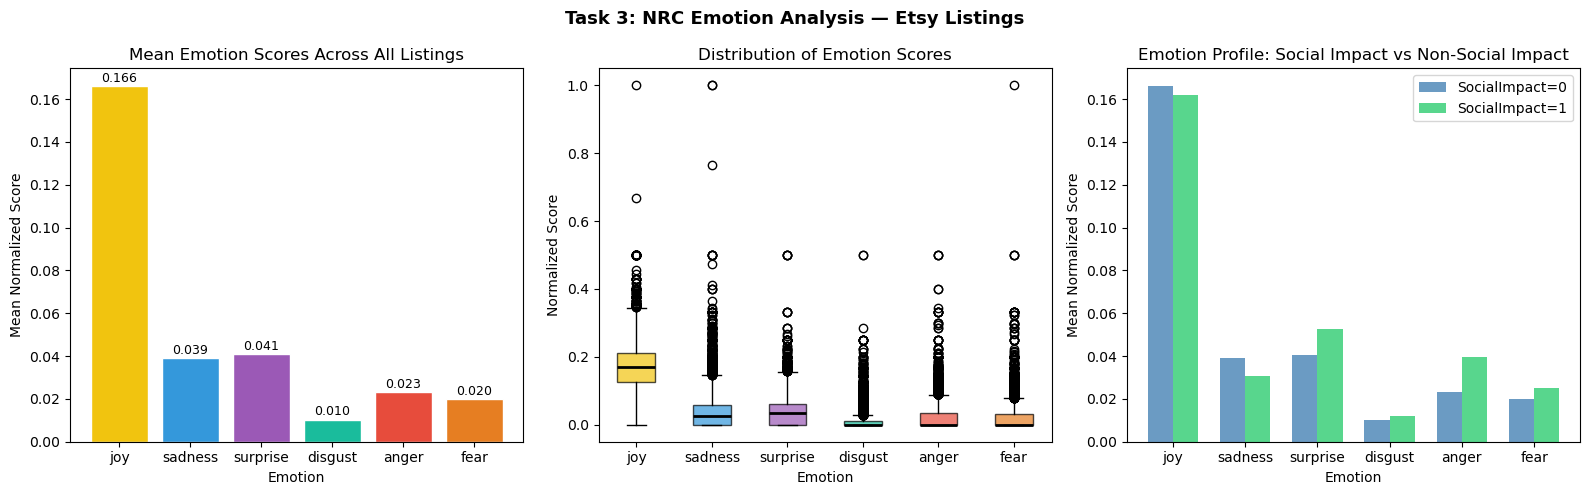

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task3_emotion/emotion_analysis.png


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#f1c40f', '#3498db', '#9b59b6', '#1abc9c', '#e74c3c', '#e67e22']

# Plot 1: Mean emotion scores
means = [df[f'emotion_{e}'].mean() for e in EMOTIONS]
axes[0].bar(EMOTIONS, means, color=colors, edgecolor='white')
axes[0].set_title('Mean Emotion Scores Across All Listings')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Mean Normalized Score')
for i, v in enumerate(means):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

# Plot 2: Box plots
emotion_data = [df[f'emotion_{e}'] for e in EMOTIONS]
bp = axes[1].boxplot(emotion_data, labels=EMOTIONS, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Distribution of Emotion Scores')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Normalized Score')

# Plot 3: SocialImpact=1 vs SocialImpact=0
si1_means = [df[df['SocialImpact']==1][f'emotion_{e}'].mean() for e in EMOTIONS]
si0_means = [df[df['SocialImpact']==0][f'emotion_{e}'].mean() for e in EMOTIONS]
x     = np.arange(len(EMOTIONS))
width = 0.35
axes[2].bar(x - width/2, si0_means, width, label='SocialImpact=0', color='steelblue', alpha=0.8)
axes[2].bar(x + width/2, si1_means, width, label='SocialImpact=1', color='#2ecc71',   alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(EMOTIONS)
axes[2].set_title('Emotion Profile: Social Impact vs Non-Social Impact')
axes[2].set_xlabel('Emotion')
axes[2].set_ylabel('Mean Normalized Score')
axes[2].legend()

plt.suptitle('Task 3: NRC Emotion Analysis — Etsy Listings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ3}/emotion_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ3}/emotion_analysis.png")

In [50]:
df.to_csv(f'{MOD}/etsy_master.csv', index=False)
print(f"Saved: {MOD}/etsy_master.csv")
print(f"Columns: {df.columns.tolist()}")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/data/modified/etsy_master.csv
Columns: ['url', 'name', 'price', 'currency', 'availability', 'description', 'category', 'brand', 'average_rating', 'reviews_count', 'images', 'product_details', 'scraped_at', 'SocialImpact', 'Handmade', 'lexical_diversity', 'first_person_ratio', 'readability_score', 'personalization', 'trust_factor', 'LogReviewCount', 'SentimentScore', 'emotion_joy', 'emotion_sadness', 'emotion_surprise', 'emotion_disgust', 'emotion_anger', 'emotion_fear']


### Task 6 - Data Visualization

In [51]:
df = pd.read_csv(f'{MOD}/etsy_master.csv')

df['LogReviewCount'] = np.log(df['reviews_count'] + 1)
df['LogPrice']       = np.log(df['price'] + 1)
df['top_category']   = df['category'].apply(lambda x: x.split(' < ')[0].strip())

df.to_csv(f'{MOD}/etsy_master.csv', index=False)

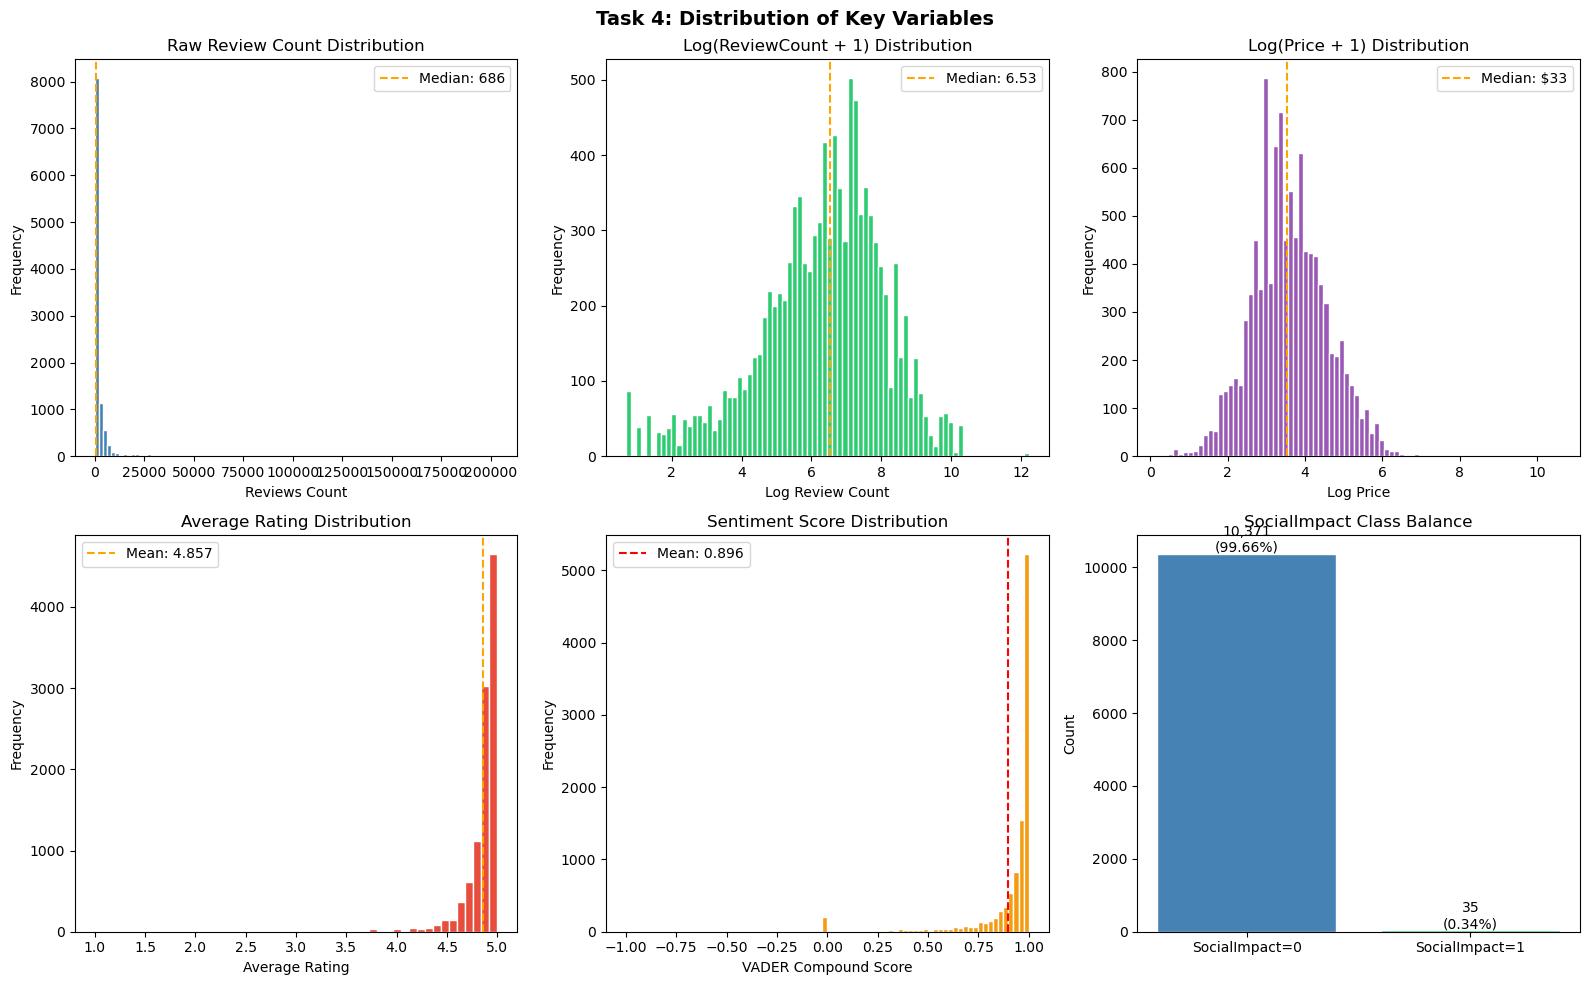

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task4_eda/fig1_distributions.png


In [52]:
# =============================================================================
# FIGURE 1: Distributions of Key Variables
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Task 4: Distribution of Key Variables', fontsize=14, fontweight='bold')

# 1. Raw Review Count
axes[0,0].hist(df['reviews_count'], bins=100, color='steelblue', edgecolor='white')
axes[0,0].set_title('Raw Review Count Distribution')
axes[0,0].set_xlabel('Reviews Count')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(df['reviews_count'].median(), color='orange', linestyle='--',
                   label=f"Median: {df['reviews_count'].median():.0f}")
axes[0,0].legend()

# 2. Log Review Count
axes[0,1].hist(df['LogReviewCount'], bins=80, color='#2ecc71', edgecolor='white')
axes[0,1].set_title('Log(ReviewCount + 1) Distribution')
axes[0,1].set_xlabel('Log Review Count')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(df['LogReviewCount'].median(), color='orange', linestyle='--',
                   label=f"Median: {df['LogReviewCount'].median():.2f}")
axes[0,1].legend()

# 3. Log Price
axes[0,2].hist(df['LogPrice'], bins=80, color='#9b59b6', edgecolor='white')
axes[0,2].set_title('Log(Price + 1) Distribution')
axes[0,2].set_xlabel('Log Price')
axes[0,2].set_ylabel('Frequency')
axes[0,2].axvline(df['LogPrice'].median(), color='orange', linestyle='--',
                   label=f"Median: ${df['price'].median():.0f}")
axes[0,2].legend()

# 4. Average Rating
axes[1,0].hist(df['average_rating'], bins=50, color='#e74c3c', edgecolor='white')
axes[1,0].set_title('Average Rating Distribution')
axes[1,0].set_xlabel('Average Rating')
axes[1,0].set_ylabel('Frequency')
axes[1,0].axvline(df['average_rating'].mean(), color='orange', linestyle='--',
                   label=f"Mean: {df['average_rating'].mean():.3f}")
axes[1,0].legend()

# 5. Sentiment Score
axes[1,1].hist(df['SentimentScore'], bins=80, color='#f39c12', edgecolor='white')
axes[1,1].set_title('Sentiment Score Distribution')
axes[1,1].set_xlabel('VADER Compound Score')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(df['SentimentScore'].mean(), color='red', linestyle='--',
                   label=f"Mean: {df['SentimentScore'].mean():.3f}")
axes[1,1].legend()

# 6. SocialImpact Class Balance
si_counts = df['SocialImpact'].value_counts()
axes[1,2].bar(['SocialImpact=0', 'SocialImpact=1'],
               [si_counts[0], si_counts[1]],
               color=['steelblue', '#2ecc71'], edgecolor='white')
axes[1,2].set_title('SocialImpact Class Balance')
axes[1,2].set_ylabel('Count')
for i, v in enumerate([si_counts[0], si_counts[1]]):
    axes[1,2].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.2f}%)',
                   ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{VIZ4}/fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ4}/fig1_distributions.png")

/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_1845/3527078022.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp  = axes[0,0].boxplot([si0, si1],


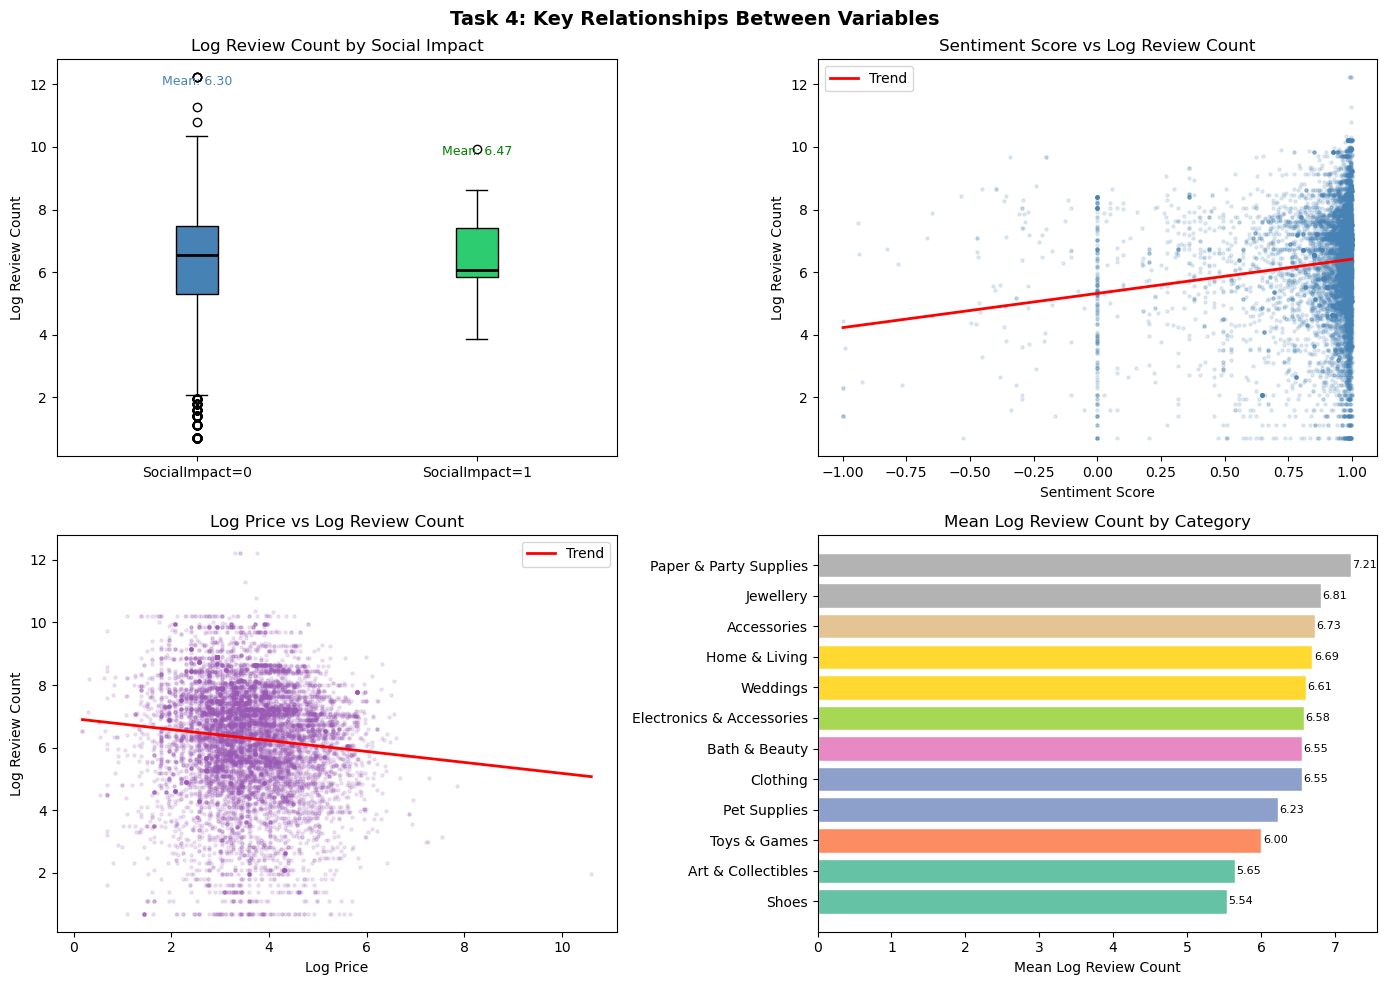

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task4_eda/fig2_relationships.png


In [53]:
# =============================================================================
# FIGURE 2: Key Relationships
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Task 4: Key Relationships Between Variables', fontsize=14, fontweight='bold')

# 1. LogReviewCount by SocialImpact
si0 = df[df['SocialImpact']==0]['LogReviewCount']
si1 = df[df['SocialImpact']==1]['LogReviewCount']
bp  = axes[0,0].boxplot([si0, si1],
                         labels=['SocialImpact=0', 'SocialImpact=1'],
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('#2ecc71')
axes[0,0].set_title('Log Review Count by Social Impact')
axes[0,0].set_ylabel('Log Review Count')
axes[0,0].text(1, si0.max()*0.98, f'Mean: {si0.mean():.2f}', ha='center', fontsize=9, color='steelblue')
axes[0,0].text(2, si1.max()*0.98, f'Mean: {si1.mean():.2f}', ha='center', fontsize=9, color='green')

# 2. SentimentScore vs LogReviewCount
axes[0,1].scatter(df['SentimentScore'], df['LogReviewCount'],
                   alpha=0.15, s=5, color='steelblue')
z = np.polyfit(df['SentimentScore'], df['LogReviewCount'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['SentimentScore'].min(), df['SentimentScore'].max(), 100)
axes[0,1].plot(x_line, p(x_line), color='red', linewidth=2, label='Trend')
axes[0,1].set_title('Sentiment Score vs Log Review Count')
axes[0,1].set_xlabel('Sentiment Score')
axes[0,1].set_ylabel('Log Review Count')
axes[0,1].legend()

# 3. Log Price vs LogReviewCount
axes[1,0].scatter(df['LogPrice'], df['LogReviewCount'],
                   alpha=0.15, s=5, color='#9b59b6')
z2 = np.polyfit(df['LogPrice'], df['LogReviewCount'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['LogPrice'].min(), df['LogPrice'].max(), 100)
axes[1,0].plot(x_line2, p2(x_line2), color='red', linewidth=2, label='Trend')
axes[1,0].set_title('Log Price vs Log Review Count')
axes[1,0].set_xlabel('Log Price')
axes[1,0].set_ylabel('Log Review Count')
axes[1,0].legend()

# 4. Mean LogReviewCount by Category
cat_means = (df.groupby('top_category')['LogReviewCount']
               .mean()
               .sort_values(ascending=True))
colors_cat = plt.cm.Set2(np.linspace(0, 1, len(cat_means)))
axes[1,1].barh(cat_means.index, cat_means.values, color=colors_cat, edgecolor='white')
axes[1,1].set_title('Mean Log Review Count by Category')
axes[1,1].set_xlabel('Mean Log Review Count')
for i, v in enumerate(cat_means.values):
    axes[1,1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{VIZ4}/fig2_relationships.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ4}/fig2_relationships.png")

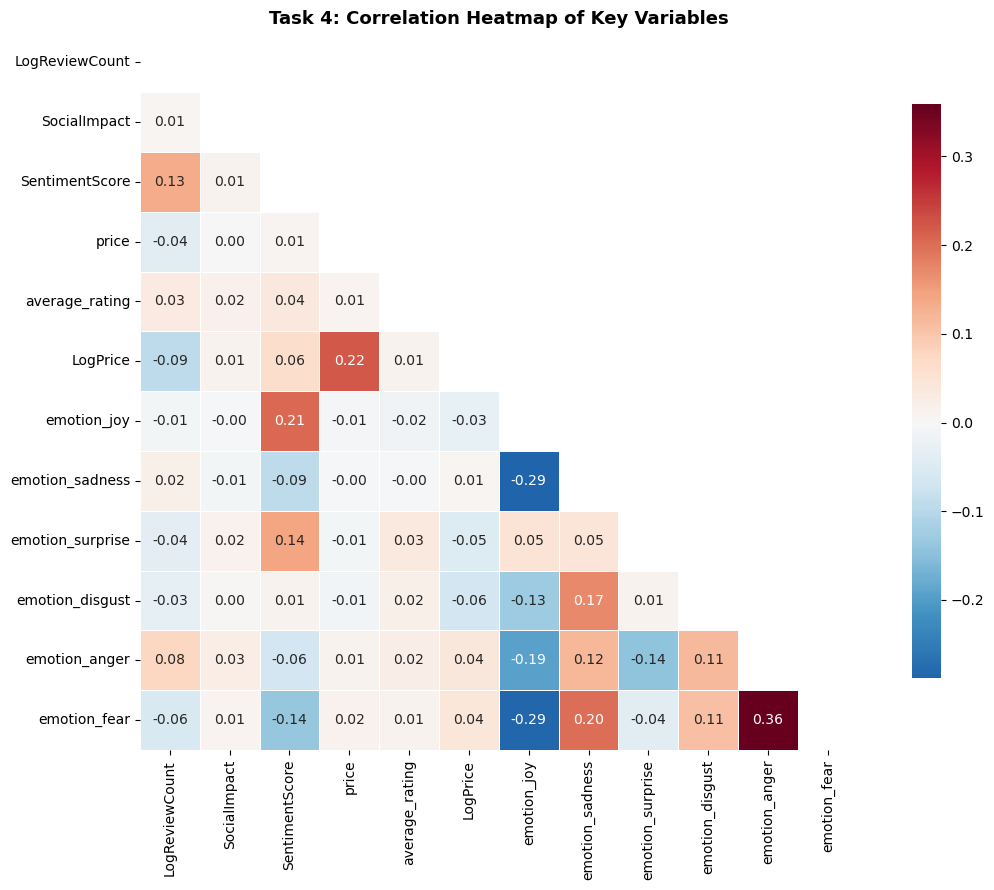

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task4_eda/fig3_correlation_heatmap.png


In [54]:
# =============================================================================
# FIGURE 3: Correlation Heatmap
# =============================================================================
numeric_cols = [
    'LogReviewCount', 'SocialImpact', 'SentimentScore',
    'price', 'average_rating', 'LogPrice',
    'emotion_joy', 'emotion_sadness', 'emotion_surprise',
    'emotion_disgust', 'emotion_anger', 'emotion_fear'
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr,
            annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            mask=np.triu(np.ones_like(corr, dtype=bool)),
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Task 4: Correlation Heatmap of Key Variables',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ4}/fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ4}/fig3_correlation_heatmap.png")

In [55]:
# =============================================================================
# Summary Statistics
# =============================================================================
print(f"\n{'='*60}")
print("Key Variable Summary")
print(f"{'='*60}")
print(df[['reviews_count', 'LogReviewCount', 'price',
          'average_rating', 'SentimentScore', 'SocialImpact']].describe().round(3))

print(f"\nLogReviewCount by SocialImpact:")
print(df.groupby('SocialImpact')['LogReviewCount'].agg(
    ['mean', 'median', 'std', 'count']).round(3))

print(f"\nCorrelation with LogReviewCount (sorted):")
print(corr['LogReviewCount'].drop('LogReviewCount').sort_values(ascending=False).round(4))

print(f"\nAll Task 4 visualizations saved to: {VIZ4}")


Key Variable Summary
       reviews_count  LogReviewCount      price  average_rating  \
count      10406.000       10406.000  10406.000       10406.000   
mean        1873.106           6.299     61.547           4.857   
std         5275.098           1.795    399.929           0.229   
min            1.000           0.693      0.200           1.000   
25%          203.250           5.319     18.000           4.834   
50%          686.000           6.532     33.000           4.905   
75%         1781.000           7.485     66.500           4.973   
max       203360.000          12.223  39999.000           5.000   

       SentimentScore  SocialImpact  
count       10406.000     10406.000  
mean            0.896         0.003  
std             0.219         0.058  
min            -0.998         0.000  
25%             0.917         0.000  
50%             0.975         0.000  
75%             0.990         0.000  
max             1.000         1.000  

LogReviewCount by SocialImpact:

### Task 6A - HandMade Analysis

In [56]:
df = pd.read_csv(f'{MOD}/etsy_master.csv')
print(f"Columns: {df.columns.tolist()}")

Columns: ['url', 'name', 'price', 'currency', 'availability', 'description', 'category', 'brand', 'average_rating', 'reviews_count', 'images', 'product_details', 'scraped_at', 'SocialImpact', 'Handmade', 'lexical_diversity', 'first_person_ratio', 'readability_score', 'personalization', 'trust_factor', 'LogReviewCount', 'SentimentScore', 'emotion_joy', 'emotion_sadness', 'emotion_surprise', 'emotion_disgust', 'emotion_anger', 'emotion_fear', 'LogPrice', 'top_category']


In [57]:
total = len(df)
hm1   = df['Handmade'].sum()
hm0   = total - hm1

print(f"\n{'='*55}")
print(f"  Handmade = 1:  {hm1:>6,}  ({hm1/total*100:.2f}%)")
print(f"  Handmade = 0:  {hm0:>6,}  ({hm0/total*100:.2f}%)")
print(f"{'='*55}")


  Handmade = 1:   3,671  (35.28%)
  Handmade = 0:   6,735  (64.72%)


In [58]:
cat_hm = (df.groupby('top_category')['Handmade']
            .agg(['sum', 'count', 'mean'])
            .rename(columns={'sum': 'handmade_count',
                             'count': 'total',
                             'mean': 'handmade_rate'})
            .sort_values('handmade_rate', ascending=False))

print(f"\nHandmade Rate by Category:")
print(f"  {'Category':<35} {'Handmade':>10} {'Total':>8} {'Rate':>8}")
print(f"  {'-'*63}")
for cat, row in cat_hm.iterrows():
    print(f"  {cat:<35} {int(row['handmade_count']):>10,} "
          f"{int(row['total']):>8,} {row['handmade_rate']*100:>7.1f}%")


Handmade Rate by Category:
  Category                              Handmade    Total     Rate
  ---------------------------------------------------------------
  Jewellery                                   30       66    45.5%
  Shoes                                      967    2,233    43.3%
  Clothing                                    24       57    42.1%
  Toys & Games                               109      287    38.0%
  Pet Supplies                               101      276    36.6%
  Weddings                                 2,242    6,385    35.1%
  Home & Living                                2        6    33.3%
  Accessories                                125      417    30.0%
  Bath & Beauty                                8       31    25.8%
  Art & Collectibles                          62      634     9.8%
  Paper & Party Supplies                       1       13     7.7%
  Electronics & Accessories                    0        1     0.0%


In [59]:
# =============================================================================
# 3. LogReviewCount — Handmade=1 vs Handmade=0
# =============================================================================
hm1_reviews = df[df['Handmade']==1]['LogReviewCount']
hm0_reviews = df[df['Handmade']==0]['LogReviewCount']

print(f"\n{'='*55}")
print(f"LogReviewCount by Handmade")
print(f"{'='*55}")
print(f"  {'Metric':<15} {'Handmade=1':>12} {'Handmade=0':>12}")
print(f"  {'-'*40}")
print(f"  {'Mean':<15} {hm1_reviews.mean():>12.4f} {hm0_reviews.mean():>12.4f}")
print(f"  {'Median':<15} {hm1_reviews.median():>12.4f} {hm0_reviews.median():>12.4f}")
print(f"  {'Std':<15} {hm1_reviews.std():>12.4f} {hm0_reviews.std():>12.4f}")
print(f"  {'Count':<15} {len(hm1_reviews):>12,} {len(hm0_reviews):>12,}")


LogReviewCount by Handmade
  Metric            Handmade=1   Handmade=0
  ----------------------------------------
  Mean                  6.1419       6.3850
  Median                6.3261       6.6254
  Std                   1.8105       1.7803
  Count                  3,671        6,735


In [60]:
# =============================================================================
# 4. SentimentScore — Handmade=1 vs Handmade=0
# =============================================================================
hm1_sent = df[df['Handmade']==1]['SentimentScore']
hm0_sent = df[df['Handmade']==0]['SentimentScore']

print(f"\n{'='*55}")
print(f"SentimentScore by Handmade")
print(f"{'='*55}")
print(f"  {'Metric':<15} {'Handmade=1':>12} {'Handmade=0':>12}")
print(f"  {'-'*40}")
print(f"  {'Mean':<15} {hm1_sent.mean():>12.4f} {hm0_sent.mean():>12.4f}")
print(f"  {'Median':<15} {hm1_sent.median():>12.4f} {hm0_sent.median():>12.4f}")
print(f"  {'Std':<15} {hm1_sent.std():>12.4f} {hm0_sent.std():>12.4f}")


SentimentScore by Handmade
  Metric            Handmade=1   Handmade=0
  ----------------------------------------
  Mean                  0.9289       0.8786
  Median                0.9825       0.9690
  Std                   0.1713       0.2389


In [61]:
# =============================================================================
# 5. Price comparison — Handmade=1 vs Handmade=0
# =============================================================================
hm1_price = df[df['Handmade']==1]['price']
hm0_price = df[df['Handmade']==0]['price']

print(f"\n{'='*55}")
print(f"Price by Handmade")
print(f"{'='*55}")
print(f"  {'Metric':<15} {'Handmade=1':>12} {'Handmade=0':>12}")
print(f"  {'-'*40}")
print(f"  {'Mean':<15} ${hm1_price.mean():>11.2f} ${hm0_price.mean():>11.2f}")
print(f"  {'Median':<15} ${hm1_price.median():>11.2f} ${hm0_price.median():>11.2f}")


Price by Handmade
  Metric            Handmade=1   Handmade=0
  ----------------------------------------
  Mean            $      67.30 $      58.41
  Median          $      38.00 $      30.23


/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_1845/3652595617.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0,1].boxplot([hm0_reviews, hm1_reviews],
/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_1845/3652595617.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[0,2].boxplot([hm0_sent, hm1_sent],


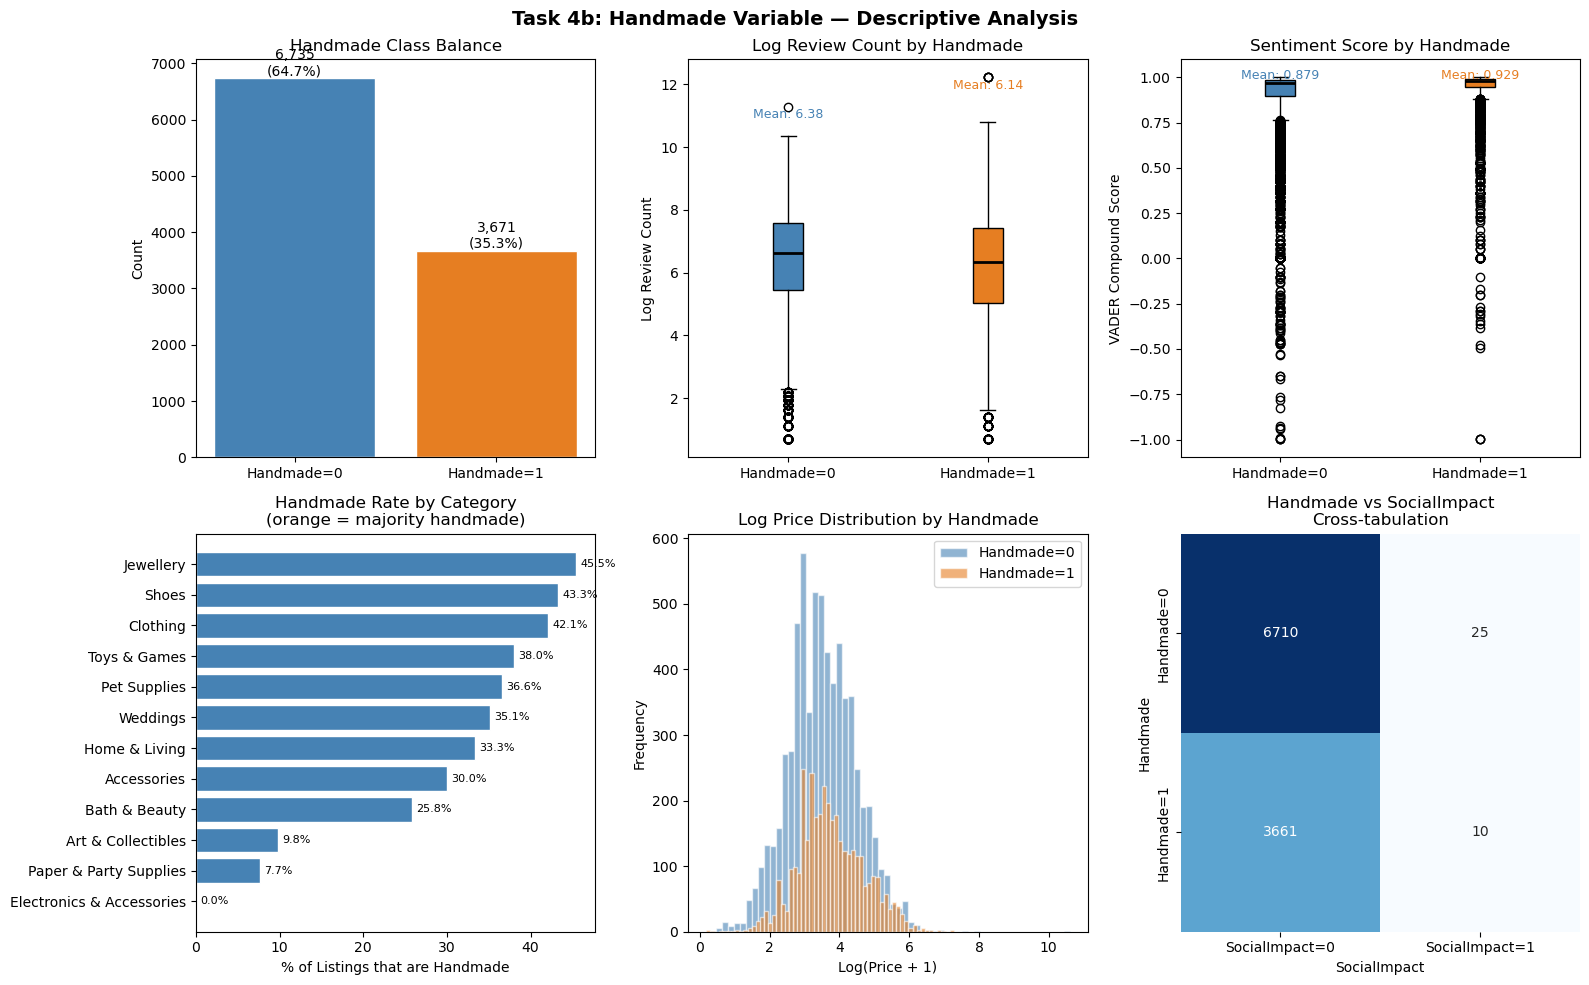


Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task4_eda/handmade_analysis.png


In [62]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Task 4b: Handmade Variable — Descriptive Analysis',
             fontsize=14, fontweight='bold')

# Plot 1: Class balance
axes[0,0].bar(['Handmade=0', 'Handmade=1'],
               [hm0, hm1],
               color=['steelblue', '#e67e22'], edgecolor='white')
axes[0,0].set_title('Handmade Class Balance')
axes[0,0].set_ylabel('Count')
for i, v in enumerate([hm0, hm1]):
    axes[0,0].text(i, v + 50, f'{v:,}\n({v/total*100:.1f}%)',
                   ha='center', fontsize=10)

# Plot 2: LogReviewCount by Handmade — box plot
bp = axes[0,1].boxplot([hm0_reviews, hm1_reviews],
                        labels=['Handmade=0', 'Handmade=1'],
                        patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('#e67e22')
axes[0,1].set_title('Log Review Count by Handmade')
axes[0,1].set_ylabel('Log Review Count')
axes[0,1].text(1, hm0_reviews.max()*0.97,
               f'Mean: {hm0_reviews.mean():.2f}',
               ha='center', fontsize=9, color='steelblue')
axes[0,1].text(2, hm1_reviews.max()*0.97,
               f'Mean: {hm1_reviews.mean():.2f}',
               ha='center', fontsize=9, color='#e67e22')

# Plot 3: SentimentScore by Handmade — box plot
bp2 = axes[0,2].boxplot([hm0_sent, hm1_sent],
                          labels=['Handmade=0', 'Handmade=1'],
                          patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
bp2['boxes'][0].set_facecolor('steelblue')
bp2['boxes'][1].set_facecolor('#e67e22')
axes[0,2].set_title('Sentiment Score by Handmade')
axes[0,2].set_ylabel('VADER Compound Score')
axes[0,2].text(1, hm0_sent.max()*0.99,
               f'Mean: {hm0_sent.mean():.3f}',
               ha='center', fontsize=9, color='steelblue')
axes[0,2].text(2, hm1_sent.max()*0.99,
               f'Mean: {hm1_sent.mean():.3f}',
               ha='center', fontsize=9, color='#e67e22')

# Plot 4: Handmade rate by category
cat_hm_sorted = cat_hm.sort_values('handmade_rate', ascending=True)
colors_cat = ['#e67e22' if r > 0.5 else 'steelblue'
              for r in cat_hm_sorted['handmade_rate']]
axes[1,0].barh(cat_hm_sorted.index,
               cat_hm_sorted['handmade_rate'] * 100,
               color=colors_cat, edgecolor='white')
axes[1,0].set_title('Handmade Rate by Category\n(orange = majority handmade)')
axes[1,0].set_xlabel('% of Listings that are Handmade')
for i, v in enumerate(cat_hm_sorted['handmade_rate'] * 100):
    axes[1,0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

# Plot 5: Price distribution Handmade=0 vs 1
axes[1,1].hist(np.log(hm0_price + 1), bins=60, alpha=0.6,
               color='steelblue', label='Handmade=0', edgecolor='white')
axes[1,1].hist(np.log(hm1_price + 1), bins=60, alpha=0.6,
               color='#e67e22', label='Handmade=1', edgecolor='white')
axes[1,1].set_title('Log Price Distribution by Handmade')
axes[1,1].set_xlabel('Log(Price + 1)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()

# Plot 6: Handmade vs SocialImpact overlap
overlap_data = pd.crosstab(df['Handmade'], df['SocialImpact'])
sns.heatmap(overlap_data, annot=True, fmt='d', cmap='Blues',
            ax=axes[1,2], cbar=False,
            xticklabels=['SocialImpact=0', 'SocialImpact=1'],
            yticklabels=['Handmade=0', 'Handmade=1'])
axes[1,2].set_title('Handmade vs SocialImpact\nCross-tabulation')
axes[1,2].set_xlabel('SocialImpact')
axes[1,2].set_ylabel('Handmade')

plt.tight_layout()
plt.savefig(f'{VIZ4}/handmade_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {VIZ4}/handmade_analysis.png")

In [63]:
df.to_csv(f'{MOD}/etsy_master.csv', index=False)
print(f"Saved: {MOD}/etsy_master.csv")
print(f"Columns: {df.columns.tolist()}")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/data/modified/etsy_master.csv
Columns: ['url', 'name', 'price', 'currency', 'availability', 'description', 'category', 'brand', 'average_rating', 'reviews_count', 'images', 'product_details', 'scraped_at', 'SocialImpact', 'Handmade', 'lexical_diversity', 'first_person_ratio', 'readability_score', 'personalization', 'trust_factor', 'LogReviewCount', 'SentimentScore', 'emotion_joy', 'emotion_sadness', 'emotion_surprise', 'emotion_disgust', 'emotion_anger', 'emotion_fear', 'LogPrice', 'top_category']


### Task 6B - Linguistic Features Descriptive Analysis

In [64]:
df = pd.read_csv(f'{MOD}/etsy_master.csv')
print(f"Loaded: {df.shape[0]:,} rows")

Loaded: 10,406 rows


In [65]:
ling_features     = ['lexical_diversity', 'first_person_ratio',
                     'readability_score', 'personalization', 'trust_factor']
continuous_feats  = ['lexical_diversity', 'first_person_ratio', 'readability_score']
binary_feats      = ['personalization', 'trust_factor']

In [66]:
print(f"\n{'='*65}")
print("Linguistic Features — Summary Statistics")
print(f"{'='*65}")
print(df[ling_features].describe().round(4))



Linguistic Features — Summary Statistics
       lexical_diversity  first_person_ratio  readability_score  \
count         10406.0000          10406.0000         10406.0000   
mean              0.6904              0.0121            61.2224   
std               0.1163              0.0150            14.1230   
min               0.2385              0.0000             0.0000   
25%               0.6167              0.0000            54.4152   
50%               0.6860              0.0072            62.7773   
75%               0.7619              0.0196            70.1430   
max               1.0000              0.1429           100.0000   

       personalization  trust_factor  
count       10406.0000    10406.0000  
mean            0.3564        0.1075  
std             0.4790        0.3098  
min             0.0000        0.0000  
25%             0.0000        0.0000  
50%             0.0000        0.0000  
75%             1.0000        0.0000  
max             1.0000        1.0000  


In [67]:
print(f"\n{'='*65}")
print("Linguistic Features by SocialImpact")
print(f"{'='*65}")
print(f"  {'Feature':<25} {'SI=0':>10} {'SI=1':>10} {'Diff':>10}")
print(f"  {'-'*55}")
for feat in ling_features:
    si0_mean = df[df['SocialImpact']==0][feat].mean()
    si1_mean = df[df['SocialImpact']==1][feat].mean()
    diff     = si1_mean - si0_mean
    print(f"  {feat:<25} {si0_mean:>10.4f} {si1_mean:>10.4f} {diff:>+10.4f}")


Linguistic Features by SocialImpact
  Feature                         SI=0       SI=1       Diff
  -------------------------------------------------------
  lexical_diversity             0.6906     0.6361    -0.0545
  first_person_ratio            0.0121     0.0166    +0.0045
  readability_score            61.2349    57.5039    -3.7311
  personalization               0.3564     0.3714    +0.0151
  trust_factor                  0.1064     0.4571    +0.3508


In [68]:
print(f"\n{'='*65}")
print("Linguistic Features by Handmade")
print(f"{'='*65}")
print(f"  {'Feature':<25} {'HM=0':>10} {'HM=1':>10} {'Diff':>10}")
print(f"  {'-'*55}")
for feat in ling_features:
    hm0_mean = df[df['Handmade']==0][feat].mean()
    hm1_mean = df[df['Handmade']==1][feat].mean()
    diff     = hm1_mean - hm0_mean
    print(f"  {feat:<25} {hm0_mean:>10.4f} {hm1_mean:>10.4f} {diff:>+10.4f}")


Linguistic Features by Handmade
  Feature                         HM=0       HM=1       Diff
  -------------------------------------------------------
  lexical_diversity             0.6994     0.6740    -0.0253
  first_person_ratio            0.0122     0.0120    -0.0002
  readability_score            61.5497    60.6218    -0.9279
  personalization               0.3149     0.4326    +0.1177
  trust_factor                  0.0999     0.1215    +0.0216


In [69]:
print(f"\n{'='*65}")
print("LogReviewCount by Binary Linguistic Features")
print(f"{'='*65}")
for feat in binary_feats:
    mean0 = df[df[feat]==0]['LogReviewCount'].mean()
    mean1 = df[df[feat]==1]['LogReviewCount'].mean()
    print(f"\n  {feat}:")
    print(f"    {feat}=0: mean LogReviewCount = {mean0:.4f}")
    print(f"    {feat}=1: mean LogReviewCount = {mean1:.4f}")
    print(f"    Difference: {mean1-mean0:+.4f}")


LogReviewCount by Binary Linguistic Features

  personalization:
    personalization=0: mean LogReviewCount = 6.1958
    personalization=1: mean LogReviewCount = 6.4860
    Difference: +0.2903

  trust_factor:
    trust_factor=0: mean LogReviewCount = 6.2211
    trust_factor=1: mean LogReviewCount = 6.9476
    Difference: +0.7265


In [70]:
corr_cols = ling_features + ['LogReviewCount', 'SentimentScore',
                              'SocialImpact', 'Handmade']
corr_matrix = df[corr_cols].corr()

print(f"\n{'='*65}")
print("Correlation Matrix — Linguistic Features + Key Variables")
print(f"{'='*65}")
print(corr_matrix.round(3).to_string())



Correlation Matrix — Linguistic Features + Key Variables
                    lexical_diversity  first_person_ratio  readability_score  personalization  trust_factor  LogReviewCount  SentimentScore  SocialImpact  Handmade
lexical_diversity               1.000              -0.031             -0.058           -0.279        -0.169          -0.195          -0.380        -0.027    -0.104
first_person_ratio             -0.031               1.000              0.045            0.073        -0.023           0.021           0.131         0.017    -0.006
readability_score              -0.058               0.045              1.000           -0.036        -0.025          -0.037          -0.012        -0.015    -0.031
personalization                -0.279               0.073             -0.036            1.000         0.073           0.077           0.147         0.002     0.117
trust_factor                   -0.169              -0.023             -0.025            0.073         1.000           0.12

/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_1845/1225052275.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax4.boxplot(
/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_1845/1225052275.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax5.boxplot(


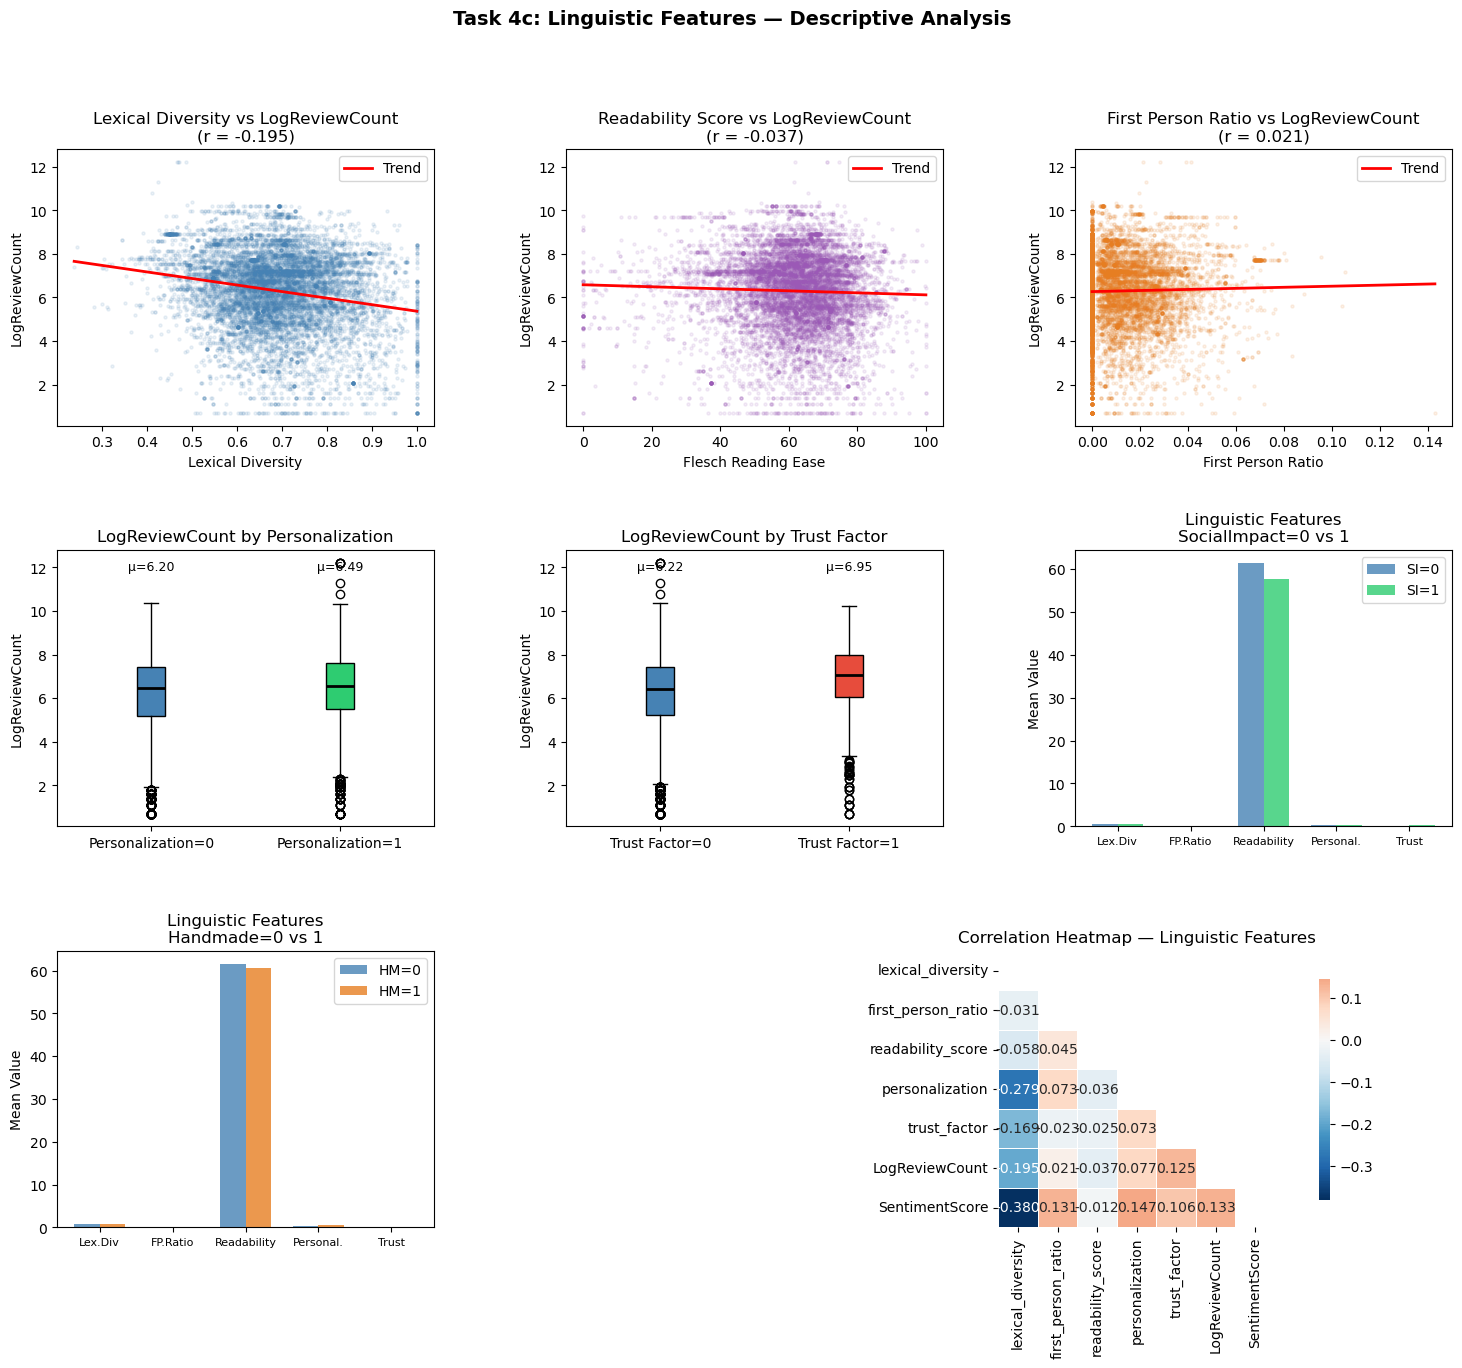

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task4_eda/linguistic_features_analysis.png


In [71]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Task 4c: Linguistic Features — Descriptive Analysis',
             fontsize=14, fontweight='bold')

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# Plot 1: LogReviewCount vs Lexical Diversity (scatter)
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(df['lexical_diversity'], df['LogReviewCount'],
            alpha=0.1, s=5, color='steelblue')
z = np.polyfit(df['lexical_diversity'].dropna(),
               df.loc[df['lexical_diversity'].notna(), 'LogReviewCount'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['lexical_diversity'].min(),
                     df['lexical_diversity'].max(), 100)
ax1.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend')
ax1.set_title(f'Lexical Diversity vs LogReviewCount\n(r = {df["lexical_diversity"].corr(df["LogReviewCount"]):.3f})')
ax1.set_xlabel('Lexical Diversity')
ax1.set_ylabel('LogReviewCount')
ax1.legend()

# Plot 2: LogReviewCount vs Readability Score (scatter)
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(df['readability_score'], df['LogReviewCount'],
            alpha=0.1, s=5, color='#9b59b6')
z2 = np.polyfit(df['readability_score'].dropna(),
                df.loc[df['readability_score'].notna(), 'LogReviewCount'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['readability_score'].min(),
                      df['readability_score'].max(), 100)
ax2.plot(x_line2, p2(x_line2), color='red', linewidth=2, label='Trend')
ax2.set_title(f'Readability Score vs LogReviewCount\n(r = {df["readability_score"].corr(df["LogReviewCount"]):.3f})')
ax2.set_xlabel('Flesch Reading Ease')
ax2.set_ylabel('LogReviewCount')
ax2.legend()

# Plot 3: LogReviewCount vs First Person Ratio (scatter)
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(df['first_person_ratio'], df['LogReviewCount'],
            alpha=0.1, s=5, color='#e67e22')
z3 = np.polyfit(df['first_person_ratio'].dropna(),
                df.loc[df['first_person_ratio'].notna(), 'LogReviewCount'], 1)
p3 = np.poly1d(z3)
x_line3 = np.linspace(df['first_person_ratio'].min(),
                      df['first_person_ratio'].max(), 100)
ax3.plot(x_line3, p3(x_line3), color='red', linewidth=2, label='Trend')
ax3.set_title(f'First Person Ratio vs LogReviewCount\n(r = {df["first_person_ratio"].corr(df["LogReviewCount"]):.3f})')
ax3.set_xlabel('First Person Ratio')
ax3.set_ylabel('LogReviewCount')
ax3.legend()

# Plot 4: LogReviewCount by Personalization — box plot
ax4 = fig.add_subplot(gs[1, 0])
bp1 = ax4.boxplot(
    [df[df['personalization']==0]['LogReviewCount'],
     df[df['personalization']==1]['LogReviewCount']],
    labels=['Personalization=0', 'Personalization=1'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
bp1['boxes'][0].set_facecolor('steelblue')
bp1['boxes'][1].set_facecolor('#2ecc71')
ax4.set_title('LogReviewCount by Personalization')
ax4.set_ylabel('LogReviewCount')
for i, grp in enumerate([0, 1]):
    mean_val = df[df['personalization']==grp]['LogReviewCount'].mean()
    ax4.text(i+1, df['LogReviewCount'].max()*0.97,
             f'μ={mean_val:.2f}', ha='center', fontsize=9)

# Plot 5: LogReviewCount by Trust Factor — box plot
ax5 = fig.add_subplot(gs[1, 1])
bp2 = ax5.boxplot(
    [df[df['trust_factor']==0]['LogReviewCount'],
     df[df['trust_factor']==1]['LogReviewCount']],
    labels=['Trust Factor=0', 'Trust Factor=1'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
bp2['boxes'][0].set_facecolor('steelblue')
bp2['boxes'][1].set_facecolor('#e74c3c')
ax5.set_title('LogReviewCount by Trust Factor')
ax5.set_ylabel('LogReviewCount')
for i, grp in enumerate([0, 1]):
    mean_val = df[df['trust_factor']==grp]['LogReviewCount'].mean()
    ax5.text(i+1, df['LogReviewCount'].max()*0.97,
             f'μ={mean_val:.2f}', ha='center', fontsize=9)

# Plot 6: Linguistic features by SocialImpact
ax6 = fig.add_subplot(gs[1, 2])
si0_means = [df[df['SocialImpact']==0][f].mean() for f in ling_features]
si1_means = [df[df['SocialImpact']==1][f].mean() for f in ling_features]
x      = np.arange(len(ling_features))
width  = 0.35
labels = ['Lex.Div', 'FP.Ratio', 'Readability', 'Personal.', 'Trust']
ax6.bar(x - width/2, si0_means, width, label='SI=0',
        color='steelblue', alpha=0.8)
ax6.bar(x + width/2, si1_means, width, label='SI=1',
        color='#2ecc71', alpha=0.8)
ax6.set_xticks(x)
ax6.set_xticklabels(labels, fontsize=8)
ax6.set_title('Linguistic Features\nSocialImpact=0 vs 1')
ax6.set_ylabel('Mean Value')
ax6.legend()

# Plot 7: Linguistic features by Handmade
ax7 = fig.add_subplot(gs[2, 0])
hm0_means = [df[df['Handmade']==0][f].mean() for f in ling_features]
hm1_means = [df[df['Handmade']==1][f].mean() for f in ling_features]
ax7.bar(x - width/2, hm0_means, width, label='HM=0',
        color='steelblue', alpha=0.8)
ax7.bar(x + width/2, hm1_means, width, label='HM=1',
        color='#e67e22', alpha=0.8)
ax7.set_xticks(x)
ax7.set_xticklabels(labels, fontsize=8)
ax7.set_title('Linguistic Features\nHandmade=0 vs 1')
ax7.set_ylabel('Mean Value')
ax7.legend()

# Plot 8: Correlation heatmap
ax8 = fig.add_subplot(gs[2, 1:])
corr_plot_cols = ling_features + ['LogReviewCount', 'SentimentScore']
corr_sub       = df[corr_plot_cols].corr()
sns.heatmap(corr_sub, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            mask=np.triu(np.ones_like(corr_sub, dtype=bool)),
            cbar_kws={"shrink": 0.8}, ax=ax8)
ax8.set_title('Correlation Heatmap — Linguistic Features')

plt.savefig(f'{VIZ4}/linguistic_features_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ4}/linguistic_features_analysis.png")

### Task 7 - Data Preparation

In [74]:
df = pd.read_csv(f'{MOD}/etsy_master.csv')
print(f"Loaded: {df.shape[0]:,} rows")
print(f"Columns: {df.columns.tolist()}")

Loaded: 10,406 rows
Columns: ['url', 'name', 'price', 'currency', 'availability', 'description', 'category', 'brand', 'average_rating', 'reviews_count', 'images', 'product_details', 'scraped_at', 'SocialImpact', 'Handmade', 'lexical_diversity', 'first_person_ratio', 'readability_score', 'personalization', 'trust_factor', 'LogReviewCount', 'SentimentScore', 'emotion_joy', 'emotion_sadness', 'emotion_surprise', 'emotion_disgust', 'emotion_anger', 'emotion_fear', 'LogPrice', 'top_category']


In [75]:
df['LogReviewCount'] = np.log(df['reviews_count'] + 1)
print(f"\n✓ LogReviewCount — min: {df['LogReviewCount'].min():.3f}, "
      f"max: {df['LogReviewCount'].max():.3f}, "
      f"mean: {df['LogReviewCount'].mean():.3f}")


✓ LogReviewCount — min: 0.693, max: 12.223, mean: 6.299


In [76]:
df['LogPrice'] = np.log(df['price'] + 1)
print(f"✓ LogPrice — min: {df['LogPrice'].min():.3f}, "
      f"max: {df['LogPrice'].max():.3f}, "
      f"mean: {df['LogPrice'].mean():.3f}")

✓ LogPrice — min: 0.182, max: 10.597, mean: 3.588


In [77]:
# =============================================================================
# 3. Create Interaction Terms (Moderation)
# =============================================================================
df['SocialImpact_x_Sentiment'] = df['SocialImpact'] * df['SentimentScore']
print(f"✓ SocialImpact_x_Sentiment created")
print(f"  Non-zero values: {(df['SocialImpact_x_Sentiment'] != 0).sum()} "
      f"(should match SocialImpact=1 count: {df['SocialImpact'].sum()})")

df['Handmade_x_Sentiment'] = df['Handmade'] * df['SentimentScore']         
print(f"✓ Handmade_x_Sentiment created")                                     
print(f"  Non-zero values: {(df['Handmade_x_Sentiment'] != 0).sum()} "      
      f"(should match Handmade=1 count: {df['Handmade'].sum()})") 

✓ SocialImpact_x_Sentiment created
  Non-zero values: 35 (should match SocialImpact=1 count: 35)
✓ Handmade_x_Sentiment created
  Non-zero values: 3638 (should match Handmade=1 count: 3671)


In [78]:
# =============================================================================
# 4. Category Dummy Variables
#    Extract top-level category and create dummies
#    Reference category: Weddings (largest group, 61% of listings)
# =============================================================================
df['top_category'] = df['category'].apply(lambda x: x.split(' < ')[0].strip())

print(f"\nTop-level category distribution:")
cat_counts = df['top_category'].value_counts()
for cat, count in cat_counts.items():
    print(f"  {cat:<35} {count:>6,}  ({count/len(df)*100:.1f}%)")

# Create dummies — drop 'Weddings' as reference category
cat_dummies = pd.get_dummies(df['top_category'], prefix='cat', drop_first=False)
cat_dummies = cat_dummies.drop(columns=['cat_Weddings'])  # reference category

print(f"\n✓ Category dummies created: {cat_dummies.columns.tolist()}")
print(f"  Reference category (dropped): Weddings")

# Append dummies to dataframe
df = pd.concat([df, cat_dummies], axis=1)


Top-level category distribution:
  Weddings                             6,385  (61.4%)
  Shoes                                2,233  (21.5%)
  Art & Collectibles                     634  (6.1%)
  Accessories                            417  (4.0%)
  Toys & Games                           287  (2.8%)
  Pet Supplies                           276  (2.7%)
  Jewellery                               66  (0.6%)
  Clothing                                57  (0.5%)
  Bath & Beauty                           31  (0.3%)
  Paper & Party Supplies                  13  (0.1%)
  Home & Living                            6  (0.1%)
  Electronics & Accessories                1  (0.0%)

✓ Category dummies created: ['cat_Accessories', 'cat_Art & Collectibles', 'cat_Bath & Beauty', 'cat_Clothing', 'cat_Electronics & Accessories', 'cat_Home & Living', 'cat_Jewellery', 'cat_Paper & Party Supplies', 'cat_Pet Supplies', 'cat_Shoes', 'cat_Toys & Games']
  Reference category (dropped): Weddings


In [79]:
# =============================================================================
# 5. Winsorize Price at 99th Percentile
# =============================================================================
price_99 = df['price'].quantile(0.99)
df['price_winsorized'] = df['price'].clip(upper=price_99)
df['LogPrice_winsorized'] = np.log(df['price_winsorized'] + 1)

print(f"\n✓ Price winsorized at 99th percentile: ${price_99:.2f}")
print(f"  Listings affected: {(df['price'] > price_99).sum():,}")
print(f"  LogPrice_winsorized — min: {df['LogPrice_winsorized'].min():.3f}, "
      f"max: {df['LogPrice_winsorized'].max():.3f}")


✓ Price winsorized at 99th percentile: $346.38
  Listings affected: 105
  LogPrice_winsorized — min: 0.182, max: 5.850


In [80]:
# =============================================================================
# 6. Standardize continuous controls
# =============================================================================
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['average_rating_std']        = scaler.fit_transform(df[['average_rating']])
df['LogPrice_winsorized_std']   = scaler.fit_transform(df[['LogPrice_winsorized']])
df['lexical_diversity_std']     = scaler.fit_transform(df[['lexical_diversity']])   # NEW
print(f"\n✓ Standardized: average_rating_std, LogPrice_winsorized_std")
print(f"✓ Standardized: lexical_diversity_std")          


✓ Standardized: average_rating_std, LogPrice_winsorized_std
✓ Standardized: lexical_diversity_std


In [81]:
df['SocialImpact_c']             = df['SocialImpact']   - df['SocialImpact'].mean()
df['SentimentScore_c']           = df['SentimentScore'] - df['SentimentScore'].mean()
df['Handmade_c']                 = df['Handmade']       - df['Handmade'].mean()
df['SocialImpact_x_Sentiment_c'] = df['SocialImpact_c'] * df['SentimentScore_c']
df['Handmade_x_Sentiment_c']     = df['Handmade_c']     * df['SentimentScore_c']
print(f"✓ Mean-centered: SocialImpact_c, SentimentScore_c, Handmade_c")
print(f"✓ Interaction terms: SocialImpact_x_Sentiment_c, Handmade_x_Sentiment_c")

✓ Mean-centered: SocialImpact_c, SentimentScore_c, Handmade_c
✓ Interaction terms: SocialImpact_x_Sentiment_c, Handmade_x_Sentiment_c


In [82]:
df['lexical_diversity_c']          = df['lexical_diversity']  - df['lexical_diversity'].mean()   
df['personalization_c']            = df['personalization']    - df['personalization'].mean()     
df['trust_factor_c']               = df['trust_factor']       - df['trust_factor'].mean()        
df['LexDiv_x_Sentiment_c']         = df['lexical_diversity_c'] * df['SentimentScore_c']         
df['Personalization_x_Sentiment_c']= df['personalization_c']  * df['SentimentScore_c']      
df['TrustFactor_x_Sentiment_c']    = df['trust_factor_c']     * df['SentimentScore_c']          
print(f"✓ Mean-centered: lexical_diversity_c, personalization_c, trust_factor_c")          
print(f"✓ Interaction terms: LexDiv_x_Sentiment_c, Personalization_x_Sentiment_c, "       
      f"TrustFactor_x_Sentiment_c") 

✓ Mean-centered: lexical_diversity_c, personalization_c, trust_factor_c
✓ Interaction terms: LexDiv_x_Sentiment_c, Personalization_x_Sentiment_c, TrustFactor_x_Sentiment_c


In [83]:
reg_cols = ['LogReviewCount', 'SocialImpact', 'Handmade',
            'SentimentScore', 'SocialImpact_x_Sentiment',
            'Handmade_x_Sentiment',
            'lexical_diversity', 'personalization', 'trust_factor',          # NEW
            'LogPrice_winsorized', 'average_rating'] + list(cat_dummies.columns)

missing = df[reg_cols].isnull().sum()
print(f"\nMissing values:")
if missing.sum() == 0:
    print("  ✓ No missing values in any regression variable")
else:
    print(missing[missing > 0])

inf_check = np.isinf(df[reg_cols].select_dtypes(include=np.number)).sum()
print(f"\nInfinite values:")
if inf_check.sum() == 0:
    print("  ✓ No infinite values in any regression variable")
else:
    print(inf_check[inf_check > 0])

print(f"\nVariance check (flag if near zero):")
for col in ['SocialImpact', 'Handmade', 'SentimentScore',
            'LogPrice_winsorized', 'average_rating',
            'lexical_diversity', 'personalization', 'trust_factor']:          # NEW
    var = df[col].var()
    flag = " ⚠️ LOW VARIANCE" if var < 0.001 else " ✓"
    print(f"  {col:<30} var = {var:.4f}{flag}")


Missing values:
  ✓ No missing values in any regression variable

Infinite values:
  ✓ No infinite values in any regression variable

Variance check (flag if near zero):
  SocialImpact                   var = 0.0034 ✓
  Handmade                       var = 0.2283 ✓
  SentimentScore                 var = 0.0478 ✓
  LogPrice_winsorized            var = 0.9030 ✓
  average_rating                 var = 0.0525 ✓
  lexical_diversity              var = 0.0135 ✓
  personalization                var = 0.2294 ✓
  trust_factor                   var = 0.0960 ✓


In [84]:
regression_cols = [
    'url', 'name',
    # Dependent variable
    'LogReviewCount',
    # Independent variables
    'SocialImpact', 'SocialImpact_c',
    'Handmade',     'Handmade_c',
    # Moderator
    'SentimentScore', 'SentimentScore_c',
    # Interaction terms — SocialImpact & Handmade
    'SocialImpact_x_Sentiment', 'SocialImpact_x_Sentiment_c',
    'Handmade_x_Sentiment',     'Handmade_x_Sentiment_c',
    # Linguistic features — raw                                               
    'lexical_diversity', 'lexical_diversity_std',                            
    'personalization',                                                       
    'trust_factor',                                                          
    # Linguistic features — mean-centered                                   
    'lexical_diversity_c', 'personalization_c', 'trust_factor_c',           
    # Linguistic interaction terms                                             
    'LexDiv_x_Sentiment_c',                                                 
    'Personalization_x_Sentiment_c',                                        
    'TrustFactor_x_Sentiment_c',                                             
    # Controls
    'LogPrice_winsorized', 'LogPrice_winsorized_std',
    'average_rating',      'average_rating_std',
    # Raw (reference)
    'reviews_count', 'price', 'LogPrice',
    # Emotion scores
    'emotion_joy', 'emotion_sadness', 'emotion_surprise',
    'emotion_disgust', 'emotion_anger', 'emotion_fear',
    # Category dummies
] + list(cat_dummies.columns)

df_reg = df[regression_cols].copy()


In [85]:
print(f"\n{'='*55}")
print("Final Regression Dataset")
print(f"{'='*55}")
print(f"  Rows:    {len(df_reg):,}")
print(f"  Columns: {len(df_reg.columns)}")
print(f"\n  Variable roles:")
print(f"  {'LogReviewCount':<35} Dependent variable (DV)")
print(f"  {'SocialImpact':<35} IV — cause marketing (0/1)")
print(f"  {'Handmade':<35} IV — handmade product (0/1)")
print(f"  {'SentimentScore':<35} Moderator")
print(f"  {'SocialImpact_x_Sentiment_c':<35} Interaction — Model 3")
print(f"  {'Handmade_x_Sentiment_c':<35} Interaction — Model 5")
print(f"  {'lexical_diversity':<35} Linguistic IV (NEW)")                    
print(f"  {'personalization':<35} Linguistic IV (NEW)")                      
print(f"  {'trust_factor':<35} Linguistic IV (NEW)")                        
print(f"  {'LexDiv_x_Sentiment_c':<35} Interaction — Task 11 (NEW)")       
print(f"  {'Personalization_x_Sentiment_c':<35} Interaction — Task 11 (NEW)")
print(f"  {'TrustFactor_x_Sentiment_c':<35} Interaction — Task 11 (NEW)")  
print(f"  {'LogPrice_winsorized_std':<35} Control — price (standardized)")
print(f"  {'average_rating_std':<35} Control — rating (standardized)")
print(f"  {'cat_* (11 dummies)':<35} Control — category (ref: Weddings)")

print(f"\n  Descriptive stats for key regression variables:")
print(df_reg[['LogReviewCount', 'SocialImpact', 'Handmade',
              'SentimentScore', 'lexical_diversity',                          
              'personalization', 'trust_factor',                              
              'LogPrice_winsorized', 'average_rating']].describe().round(3))



Final Regression Dataset
  Rows:    10,406
  Columns: 47

  Variable roles:
  LogReviewCount                      Dependent variable (DV)
  SocialImpact                        IV — cause marketing (0/1)
  Handmade                            IV — handmade product (0/1)
  SentimentScore                      Moderator
  SocialImpact_x_Sentiment_c          Interaction — Model 3
  Handmade_x_Sentiment_c              Interaction — Model 5
  lexical_diversity                   Linguistic IV (NEW)
  personalization                     Linguistic IV (NEW)
  trust_factor                        Linguistic IV (NEW)
  LexDiv_x_Sentiment_c                Interaction — Task 11 (NEW)
  Personalization_x_Sentiment_c       Interaction — Task 11 (NEW)
  TrustFactor_x_Sentiment_c           Interaction — Task 11 (NEW)
  LogPrice_winsorized_std             Control — price (standardized)
  average_rating_std                  Control — rating (standardized)
  cat_* (11 dummies)                  Control — cat

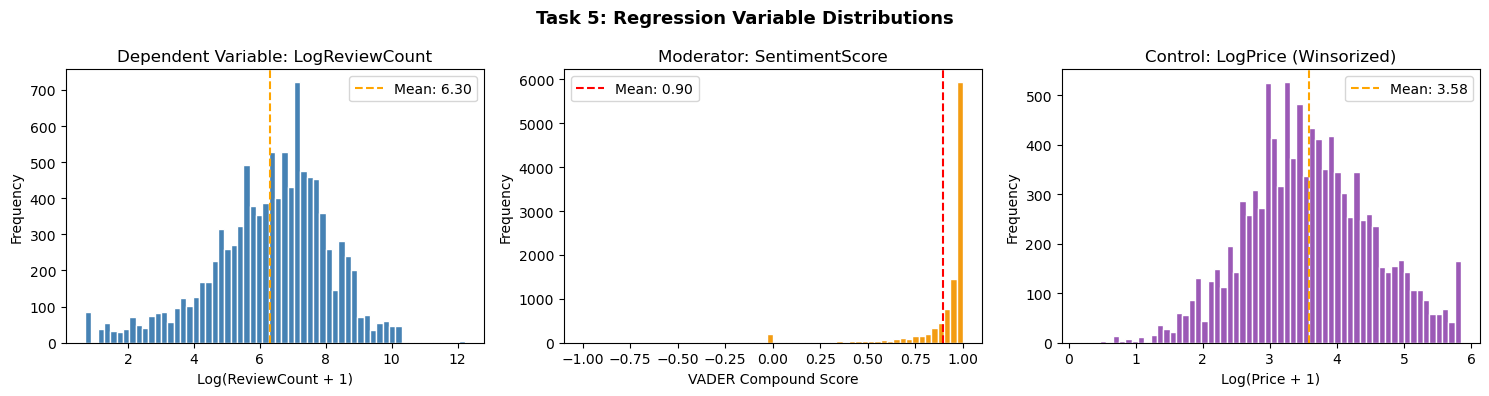


Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression/fig1_regression_variables.png


In [86]:
# =============================================================================
# 8. Visualization — Regression Variable Distributions
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Task 5: Regression Variable Distributions',
             fontsize=13, fontweight='bold')

axes[0].hist(df_reg['LogReviewCount'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Dependent Variable: LogReviewCount')
axes[0].set_xlabel('Log(ReviewCount + 1)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_reg['LogReviewCount'].mean(), color='orange',
                linestyle='--', label=f"Mean: {df_reg['LogReviewCount'].mean():.2f}")
axes[0].legend()

axes[1].hist(df_reg['SentimentScore'], bins=60, color='#f39c12', edgecolor='white')
axes[1].set_title('Moderator: SentimentScore')
axes[1].set_xlabel('VADER Compound Score')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_reg['SentimentScore'].mean(), color='red',
                linestyle='--', label=f"Mean: {df_reg['SentimentScore'].mean():.2f}")
axes[1].legend()

axes[2].hist(df_reg['LogPrice_winsorized'], bins=60, color='#9b59b6', edgecolor='white')
axes[2].set_title('Control: LogPrice (Winsorized)')
axes[2].set_xlabel('Log(Price + 1)')
axes[2].set_ylabel('Frequency')
axes[2].axvline(df_reg['LogPrice_winsorized'].mean(), color='orange',
                linestyle='--', label=f"Mean: {df_reg['LogPrice_winsorized'].mean():.2f}")
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{VIZ5}/fig1_regression_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {VIZ5}/fig1_regression_variables.png")

In [90]:
# =============================================================================
# 9. Save Regression Dataset
# =============================================================================
out = f'{MOD}/etsy_regression.csv'
df_reg.to_csv(out, index=False)
print(f"Saved: {out}")
print(f"\n✓ Task 7 Complete — regression dataset ready for modeling")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/data/modified/etsy_regression.csv

✓ Task 7 Complete — regression dataset ready for modeling


### Task 8 - Baseline Regression Model 

In [88]:
# =============================================================================
# TASK 6: Model 1 — Baseline Regression
# LogReviewCount = β0 + β1(SocialImpact) + Controls + ε
# Controls: LogPrice_winsorized, average_rating, category dummies
# =============================================================================

from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [64]:
scaler = StandardScaler()
df['average_rating_std']      = scaler.fit_transform(df[['average_rating']])
df['LogPrice_winsorized_std'] = scaler.fit_transform(df[['LogPrice_winsorized']])

# Save updated regression CSV
df.to_csv(f'{MOD}/etsy_regression.csv', index=False)
print("✓ Standardized variables created and saved.")

✓ Standardized variables created and saved.


In [65]:
cat_dummy_cols = [c for c in df.columns if c.startswith('cat_')]

X1_cols = (
    ['SocialImpact'] +
    ['LogPrice_winsorized_std'] +
    ['average_rating_std'] +
    cat_dummy_cols
)

X1 = df[X1_cols].copy()

# Convert booleans to int
bool_cols = X1.select_dtypes(include='bool').columns.tolist()
X1[bool_cols] = X1[bool_cols].astype(int)

X1 = sm.add_constant(X1)
y  = df['LogReviewCount']

print(f"\nModel 1 variables:")
print(f"  DV:       LogReviewCount")
print(f"  IV:       SocialImpact")
print(f"  Controls: LogPrice_winsorized_std, average_rating_std, "
      f"{len(cat_dummy_cols)} category dummies")


Model 1 variables:
  DV:       LogReviewCount
  IV:       SocialImpact
  Controls: LogPrice_winsorized_std, average_rating_std, 11 category dummies


In [66]:
model1 = sm.OLS(y, X1).fit()
print("\n" + "="*60)
print(model1.summary())


                            OLS Regression Results                            
Dep. Variable:         LogReviewCount   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     72.86
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          7.22e-199
Time:                        22:11:47   Log-Likelihood:                -20363.
No. Observations:               10406   AIC:                         4.076e+04
Df Residuals:                   10391   BIC:                         4.087e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const        

In [67]:
# =============================================================================
# VIF Check
# =============================================================================
print(f"\n{'='*55}")
print("Variance Inflation Factor (VIF) Check")
print(f"{'='*55}")
print(f"  {'Variable':<35} {'VIF':>8}")
print(f"  {'-'*45}")

X1_vif = X1.drop(columns=['const'])
vif_data = pd.DataFrame({
    'Variable': X1_vif.columns,
    'VIF': [variance_inflation_factor(X1_vif.values, i)
            for i in range(X1_vif.shape[1])]
}).sort_values('VIF', ascending=False)

for _, row in vif_data.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Variable']:<35} {row['VIF']:>8.3f}{flag}")


Variance Inflation Factor (VIF) Check
  Variable                                 VIF
  ---------------------------------------------
  LogPrice_winsorized_std                1.053 ✓
  cat_Art & Collectibles                 1.022 ✓
  cat_Accessories                        1.016 ✓
  cat_Shoes                              1.012 ✓
  average_rating_std                     1.010 ✓
  cat_Pet Supplies                       1.006 ✓
  SocialImpact                           1.004 ✓
  cat_Bath & Beauty                      1.003 ✓
  cat_Paper & Party Supplies             1.003 ✓
  cat_Toys & Games                       1.001 ✓
  cat_Clothing                           1.001 ✓
  cat_Home & Living                      1.000 ✓
  cat_Jewellery                          1.000 ✓
  cat_Electronics & Accessories          1.000 ✓


In [68]:
# =============================================================================
# Key Results Summary
# =============================================================================
print(f"\n{'='*55}")
print("Model 1 — Key Results Summary")
print(f"{'='*55}")
print(f"  R²:            {model1.rsquared:.4f}")
print(f"  Adj. R²:       {model1.rsquared_adj:.4f}")
print(f"  F-statistic:   {model1.fvalue:.4f}")
print(f"  F p-value:     {model1.f_pvalue:.6f}")
print(f"  N:             {int(model1.nobs):,}")

si_coef  = model1.params['SocialImpact']
si_se    = model1.bse['SocialImpact']
si_t     = model1.tvalues['SocialImpact']
si_p     = model1.pvalues['SocialImpact']
si_ci_lo = model1.conf_int().loc['SocialImpact', 0]
si_ci_hi = model1.conf_int().loc['SocialImpact', 1]

print(f"\n  SocialImpact (β₁):")
print(f"    Coefficient:  {si_coef:>8.4f}")
print(f"    Std Error:    {si_se:>8.4f}")
print(f"    t-statistic:  {si_t:>8.4f}")
print(f"    p-value:      {si_p:>8.4f}  "
      f"{'✓ Significant (p<0.05)' if si_p < 0.05 else '✗ Not significant'}")
print(f"    95% CI:       [{si_ci_lo:.4f}, {si_ci_hi:.4f}]")
print(f"\n  Interpretation:")
direction = "higher" if si_coef > 0 else "lower"
print(f"    Social impact listings are associated with {abs(si_coef):.4f} {direction}")
print(f"    LogReviewCount, holding price, rating and category constant.")
print(f"    Sign of β₁: {'POSITIVE — cause marketing associated with MORE demand' if si_coef > 0 else 'NEGATIVE — cause marketing associated with LESS demand'}")



Model 1 — Key Results Summary
  R²:            0.0894
  Adj. R²:       0.0882
  F-statistic:   72.8610
  F p-value:     0.000000
  N:             10,406

  SocialImpact (β₁):
    Coefficient:    0.2197
    Std Error:      0.2905
    t-statistic:    0.7562
    p-value:        0.4495  ✗ Not significant
    95% CI:       [-0.3497, 0.7890]

  Interpretation:
    Social impact listings are associated with 0.2197 higher
    LogReviewCount, holding price, rating and category constant.
    Sign of β₁: POSITIVE — cause marketing associated with MORE demand


/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_10567/3411826452.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels([c.replace('cat_', '') for c in cat_coefs.index])


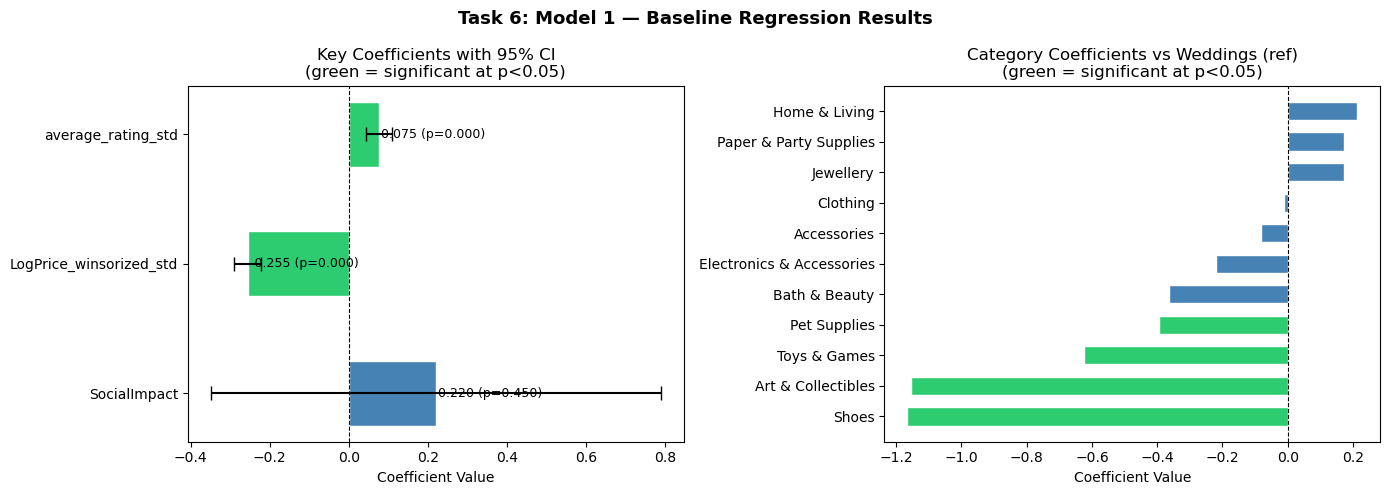


Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression/model1_results.png


In [69]:
# =============================================================================
# Coefficient Plot
# =============================================================================
key_vars = ['SocialImpact', 'LogPrice_winsorized_std', 'average_rating_std']
coefs    = model1.params[key_vars]
cis      = model1.conf_int().loc[key_vars]
colors   = ['#2ecc71' if model1.pvalues[v] < 0.05 else 'steelblue'
            for v in key_vars]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 6: Model 1 — Baseline Regression Results',
             fontsize=13, fontweight='bold')

# Plot 1: Key variable coefficients
axes[0].barh(key_vars, coefs.values,
             xerr=[(coefs.values - cis[0].values),
                   (cis[1].values - coefs.values)],
             color=colors, edgecolor='white', height=0.5,
             error_kw=dict(ecolor='black', capsize=5))
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Key Coefficients with 95% CI\n(green = significant at p<0.05)')
axes[0].set_xlabel('Coefficient Value')
for i, v in enumerate(key_vars):
    coef = model1.params[v]
    p    = model1.pvalues[v]
    axes[0].text(coef + 0.005, i, f'{coef:.3f} (p={p:.3f})',
                 va='center', fontsize=9)

# Plot 2: Category dummy coefficients
cat_coefs  = model1.params[cat_dummy_cols].sort_values()
cat_colors = ['#2ecc71' if model1.pvalues[c] < 0.05 else 'steelblue'
              for c in cat_coefs.index]
axes[1].barh(cat_coefs.index, cat_coefs.values,
             color=cat_colors, edgecolor='white', height=0.6)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Category Coefficients vs Weddings (ref)\n'
                  '(green = significant at p<0.05)')
axes[1].set_xlabel('Coefficient Value')
axes[1].set_yticklabels([c.replace('cat_', '') for c in cat_coefs.index])

plt.tight_layout()
plt.savefig(f'{VIZ5}/model1_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {VIZ5}/model1_results.png")

In [70]:
# Save summary
import os
os.makedirs(OUTPUTS, exist_ok=True)
with open(f'{OUTPUTS}/model1_summary.txt', 'w') as f:
    f.write(model1.summary().as_text())
print(f"Saved: {OUTPUTS}/model1_summary.txt")

# Store for Task 9
model1_results = {
    'model':            'Model 1 (Baseline)',
    'r2':               model1.rsquared,
    'adj_r2':           model1.rsquared_adj,
    'n':                int(model1.nobs),
    'si_coef':          model1.params['SocialImpact'],
    'si_se':            model1.bse['SocialImpact'],
    'si_p':             model1.pvalues['SocialImpact'],
    'sentiment_coef':   None,
    'sentiment_p':      None,
    'interaction_coef': None,
    'interaction_p':    None,
}
print(f"\n✓ Task 6 Complete — model1_results stored for Task 9")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/outputs/model1_summary.txt

✓ Task 6 Complete — model1_results stored for Task 9


### Task 9 - Sentiment Model

In [71]:
df = pd.read_csv(f'{MOD}/etsy_regression.csv')

cat_dummy_cols = [c for c in df.columns if c.startswith('cat_')]

In [72]:
# =============================================================================
# 1. Define Variables — Model 2 adds SentimentScore to Model 1
# =============================================================================
X2_cols = (
    ['SocialImpact'] +
    ['SentimentScore'] +              # NEW — moderator added as main effect
    ['LogPrice_winsorized_std'] +
    ['average_rating_std'] +
    cat_dummy_cols
)

X2 = df[X2_cols].copy()
bool_cols = X2.select_dtypes(include='bool').columns.tolist()
X2[bool_cols] = X2[bool_cols].astype(int)
X2 = sm.add_constant(X2)
y  = df['LogReviewCount']

print(f"\nModel 2 variables:")
print(f"  DV:        LogReviewCount")
print(f"  IV:        SocialImpact")
print(f"  Moderator: SentimentScore (added as main effect)")
print(f"  Controls:  LogPrice_winsorized_std, average_rating_std, "
      f"{len(cat_dummy_cols)} category dummies")


Model 2 variables:
  DV:        LogReviewCount
  IV:        SocialImpact
  Moderator: SentimentScore (added as main effect)
  Controls:  LogPrice_winsorized_std, average_rating_std, 11 category dummies


In [73]:
# =============================================================================
# 2. Fit Model 2
# =============================================================================
model2 = sm.OLS(y, X2).fit()
print("\n" + "="*60)
print(model2.summary())



                            OLS Regression Results                            
Dep. Variable:         LogReviewCount   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     81.83
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          4.06e-238
Time:                        22:11:48   Log-Likelihood:                -20270.
No. Observations:               10406   AIC:                         4.057e+04
Df Residuals:                   10390   BIC:                         4.069e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const        

In [74]:
# =============================================================================
# 3. VIF Check
# =============================================================================
print(f"\n{'='*55}")
print("VIF Check — Model 2")
print(f"{'='*55}")
X2_vif = X2.drop(columns=['const'])
vif_data = pd.DataFrame({
    'Variable': X2_vif.columns,
    'VIF': [variance_inflation_factor(X2_vif.values, i)
            for i in range(X2_vif.shape[1])]
}).sort_values('VIF', ascending=False)

for _, row in vif_data.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Variable']:<35} {row['VIF']:>8.3f}{flag}")



VIF Check — Model 2
  SentimentScore                         1.585 ✓
  cat_Shoes                              1.331 ✓
  cat_Art & Collectibles                 1.128 ✓
  cat_Accessories                        1.084 ✓
  LogPrice_winsorized_std                1.073 ✓
  cat_Pet Supplies                       1.047 ✓
  cat_Toys & Games                       1.037 ✓
  cat_Jewellery                          1.011 ✓
  average_rating_std                     1.010 ✓
  cat_Bath & Beauty                      1.009 ✓
  cat_Clothing                           1.008 ✓
  cat_Paper & Party Supplies             1.006 ✓
  SocialImpact                           1.006 ✓
  cat_Home & Living                      1.001 ✓
  cat_Electronics & Accessories          1.000 ✓


In [75]:
# =============================================================================
# 4. Key Results
# =============================================================================
print(f"\n{'='*55}")
print("Model 2 — Key Results Summary")
print(f"{'='*55}")
print(f"  R²:            {model2.rsquared:.4f}")
print(f"  Adj. R²:       {model2.rsquared_adj:.4f}")
print(f"  F-statistic:   {model2.fvalue:.4f}")
print(f"  F p-value:     {model2.f_pvalue:.6f}")
print(f"  N:             {int(model2.nobs):,}")

# SocialImpact
si_coef  = model2.params['SocialImpact']
si_p     = model2.pvalues['SocialImpact']
si_ci_lo = model2.conf_int().loc['SocialImpact', 0]
si_ci_hi = model2.conf_int().loc['SocialImpact', 1]

# SentimentScore
sent_coef  = model2.params['SentimentScore']
sent_se    = model2.bse['SentimentScore']
sent_t     = model2.tvalues['SentimentScore']
sent_p     = model2.pvalues['SentimentScore']
sent_ci_lo = model2.conf_int().loc['SentimentScore', 0]
sent_ci_hi = model2.conf_int().loc['SentimentScore', 1]

print(f"\n  SocialImpact (β₁):")
print(f"    Coefficient:  {si_coef:>8.4f}")
print(f"    p-value:      {si_p:>8.4f}  "
      f"{'✓ Significant' if si_p < 0.05 else '✗ Not significant'}")
print(f"    95% CI:       [{si_ci_lo:.4f}, {si_ci_hi:.4f}]")

print(f"\n  SentimentScore (β₂):")
print(f"    Coefficient:  {sent_coef:>8.4f}")
print(f"    Std Error:    {sent_se:>8.4f}")
print(f"    t-statistic:  {sent_t:>8.4f}")
print(f"    p-value:      {sent_p:>8.4f}  "
      f"{'✓ Significant' if sent_p < 0.05 else '✗ Not significant'}")
print(f"    95% CI:       [{sent_ci_lo:.4f}, {sent_ci_hi:.4f}]")

# R² change from Model 1
r2_m1 = 0.0894  # from Model 1
r2_change = model2.rsquared - r2_m1
print(f"\n  R² change from Model 1: +{r2_change:.4f}")
print(f"  {'SentimentScore adds meaningful explanatory power' if r2_change > 0.005 else 'SentimentScore adds minimal additional explanatory power'}")


Model 2 — Key Results Summary
  R²:            0.1057
  Adj. R²:       0.1044
  F-statistic:   81.8299
  F p-value:     0.000000
  N:             10,406

  SocialImpact (β₁):
    Coefficient:    0.1755
    p-value:        0.5420  ✗ Not significant
    95% CI:       [-0.3888, 0.7399]

  SentimentScore (β₂):
    Coefficient:    1.0554
    Std Error:      0.0768
    t-statistic:   13.7457
    p-value:        0.0000  ✓ Significant
    95% CI:       [0.9049, 1.2059]

  R² change from Model 1: +0.0163
  SentimentScore adds meaningful explanatory power


In [76]:
# =============================================================================
# 5. Model Comparison — Model 1 vs Model 2
# =============================================================================
print(f"\n{'='*55}")
print("Model Comparison: Model 1 vs Model 2")
print(f"{'='*55}")
print(f"  {'Metric':<25} {'Model 1':>12} {'Model 2':>12} {'Change':>10}")
print(f"  {'-'*60}")
print(f"  {'R²':<25} {r2_m1:>12.4f} {model2.rsquared:>12.4f} {r2_change:>+10.4f}")
print(f"  {'Adj. R²':<25} {0.0882:>12.4f} {model2.rsquared_adj:>12.4f} {model2.rsquared_adj-0.0882:>+10.4f}")
print(f"  {'SocialImpact coef':<25} {0.2197:>12.4f} {si_coef:>12.4f} {si_coef-0.2197:>+10.4f}")
print(f"  {'SocialImpact p-val':<25} {0.4495:>12.4f} {si_p:>12.4f} {si_p-0.4495:>+10.4f}")



Model Comparison: Model 1 vs Model 2
  Metric                         Model 1      Model 2     Change
  ------------------------------------------------------------
  R²                              0.0894       0.1057    +0.0163
  Adj. R²                         0.0882       0.1044    +0.0162
  SocialImpact coef               0.2197       0.1755    -0.0442
  SocialImpact p-val              0.4495       0.5420    +0.0925


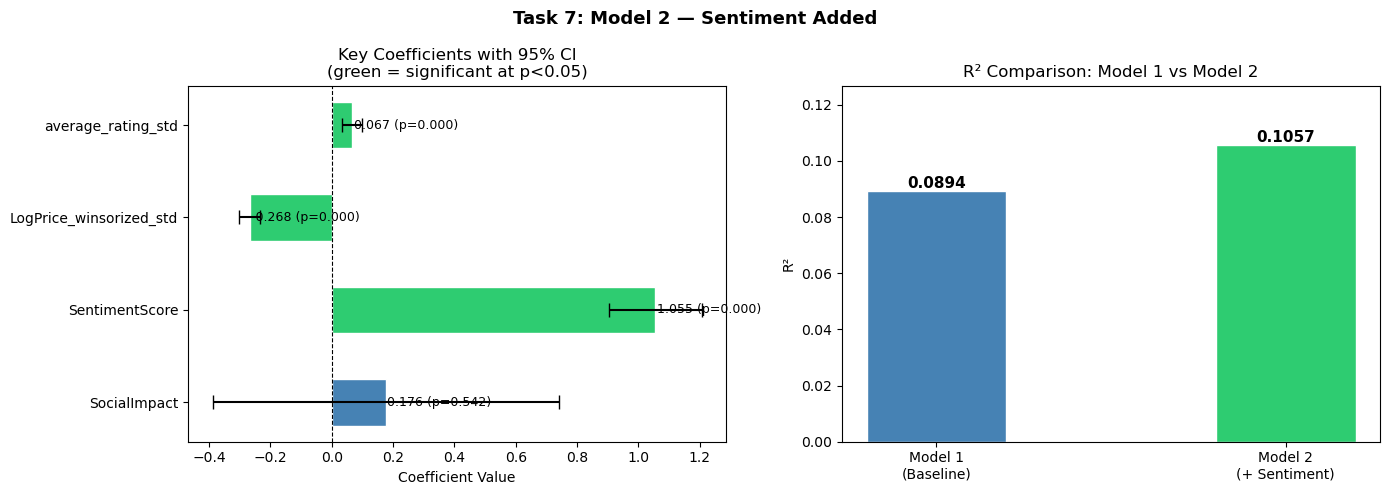


Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression/model2_results.png
Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/outputs/model2_summary.txt

✓ Task 7 Complete — model2_results stored for Task 9


In [77]:
# =============================================================================
# 6. Visualization
# =============================================================================
key_vars   = ['SocialImpact', 'SentimentScore',
              'LogPrice_winsorized_std', 'average_rating_std']
coefs      = model2.params[key_vars]
cis        = model2.conf_int().loc[key_vars]
colors     = ['#2ecc71' if model2.pvalues[v] < 0.05 else 'steelblue'
              for v in key_vars]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 7: Model 2 — Sentiment Added',
             fontsize=13, fontweight='bold')

# Plot 1: Key coefficients
axes[0].barh(key_vars, coefs.values,
             xerr=[(coefs.values - cis[0].values),
                   (cis[1].values - coefs.values)],
             color=colors, edgecolor='white', height=0.5,
             error_kw=dict(ecolor='black', capsize=5))
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Key Coefficients with 95% CI\n(green = significant at p<0.05)')
axes[0].set_xlabel('Coefficient Value')
for i, v in enumerate(key_vars):
    coef = model2.params[v]
    p    = model2.pvalues[v]
    axes[0].text(coef + 0.005, i, f'{coef:.3f} (p={p:.3f})',
                 va='center', fontsize=9)

# Plot 2: R² comparison Model 1 vs Model 2
models      = ['Model 1\n(Baseline)', 'Model 2\n(+ Sentiment)']
r2_values   = [r2_m1, model2.rsquared]
bar_colors  = ['steelblue', '#2ecc71']
bars = axes[1].bar(models, r2_values, color=bar_colors,
                   edgecolor='white', width=0.4)
axes[1].set_title('R² Comparison: Model 1 vs Model 2')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, max(r2_values) * 1.2)
for bar, val in zip(bars, r2_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{VIZ5}/model2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {VIZ5}/model2_results.png")

# Save summary
with open(f'{OUTPUTS}/model2_summary.txt', 'w') as f:
    f.write(model2.summary().as_text())
print(f"Saved: {OUTPUTS}/model2_summary.txt")

# Store for Task 9
model2_results = {
    'model':            'Model 2 (+ Sentiment)',
    'r2':               model2.rsquared,
    'adj_r2':           model2.rsquared_adj,
    'n':                int(model2.nobs),
    'si_coef':          model2.params['SocialImpact'],
    'si_se':            model2.bse['SocialImpact'],
    'si_p':             model2.pvalues['SocialImpact'],
    'sentiment_coef':   model2.params['SentimentScore'],
    'sentiment_p':      model2.pvalues['SentimentScore'],
    'interaction_coef': None,
    'interaction_p':    None,
}
print(f"\n✓ Task 7 Complete — model2_results stored for Task 9")

### Task 10 - SocialImpact Moderation Model

In [78]:
# Mean-center SocialImpact and SentimentScore
df['SocialImpact_c']    = df['SocialImpact']    - df['SocialImpact'].mean()
df['SentimentScore_c']  = df['SentimentScore']  - df['SentimentScore'].mean()

# Recreate interaction term with centered variables
df['SocialImpact_x_Sentiment_c'] = df['SocialImpact_c'] * df['SentimentScore_c']

print("Mean-centering applied:")
print(f"  SocialImpact mean:        {df['SocialImpact'].mean():.4f}")
print(f"  SentimentScore mean:      {df['SentimentScore'].mean():.4f}")
print(f"  SocialImpact_c mean:      {df['SocialImpact_c'].mean():.6f}  (should be ~0)")
print(f"  SentimentScore_c mean:    {df['SentimentScore_c'].mean():.6f}  (should be ~0)")

# Save updated CSV
df.to_csv(f'{MOD}/etsy_regression.csv', index=False)
print("\n✓ Centered variables saved to etsy_regression.csv")

Mean-centering applied:
  SocialImpact mean:        0.0034
  SentimentScore mean:      0.8964
  SocialImpact_c mean:      -0.000000  (should be ~0)
  SentimentScore_c mean:    -0.000000  (should be ~0)

✓ Centered variables saved to etsy_regression.csv


In [79]:
cat_dummy_cols = [c for c in df.columns if c.startswith('cat_')]

X3_cols = (
    ['SocialImpact_c'] +
    ['SentimentScore_c'] +
    ['SocialImpact_x_Sentiment_c'] +
    ['LogPrice_winsorized_std'] +
    ['average_rating_std'] +
    cat_dummy_cols
)

X3 = df[X3_cols].copy()
bool_cols = X3.select_dtypes(include='bool').columns.tolist()
X3[bool_cols] = X3[bool_cols].astype(int)
X3 = sm.add_constant(X3)
y  = df['LogReviewCount']


In [80]:
model3 = sm.OLS(y, X3).fit()
print("\n" + "="*60)
print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:         LogReviewCount   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     76.71
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          3.72e-237
Time:                        22:11:49   Log-Likelihood:                -20270.
No. Observations:               10406   AIC:                         4.057e+04
Df Residuals:                   10389   BIC:                         4.070e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const        

In [81]:
# VIF recheck
print(f"\n{'='*55}")
print("VIF Check — Model 3 (after mean-centering)")
print(f"{'='*55}")
X3_vif   = X3.drop(columns=['const'])
vif_data = pd.DataFrame({
    'Variable': X3_vif.columns,
    'VIF': [variance_inflation_factor(X3_vif.values, i)
            for i in range(X3_vif.shape[1])]
}).sort_values('VIF', ascending=False)

for _, row in vif_data.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Variable']:<35} {row['VIF']:>8.3f}{flag}")


VIF Check — Model 3 (after mean-centering)
  SocialImpact_x_Sentiment_c             1.106 ✓
  SocialImpact_c                         1.106 ✓
  LogPrice_winsorized_std                1.056 ✓
  cat_Art & Collectibles                 1.022 ✓
  SentimentScore_c                       1.019 ✓
  cat_Accessories                        1.017 ✓
  cat_Shoes                              1.013 ✓
  average_rating_std                     1.011 ✓
  cat_Electronics & Accessories          1.007 ✓
  cat_Pet Supplies                       1.007 ✓
  cat_Bath & Beauty                      1.003 ✓
  cat_Paper & Party Supplies             1.003 ✓
  cat_Toys & Games                       1.003 ✓
  cat_Clothing                           1.001 ✓
  cat_Jewellery                          1.000 ✓
  cat_Home & Living                      1.000 ✓


In [82]:
# Key results
print(f"\n{'='*55}")
print("Model 3 — Key Results (MAIN MODEL)")
print(f"{'='*55}")
print(f"  R²:            {model3.rsquared:.4f}")
print(f"  Adj. R²:       {model3.rsquared_adj:.4f}")
print(f"  N:             {int(model3.nobs):,}")

si_coef   = model3.params['SocialImpact_c']
si_p      = model3.pvalues['SocialImpact_c']
sent_coef = model3.params['SentimentScore_c']
sent_p    = model3.pvalues['SentimentScore_c']
int_coef  = model3.params['SocialImpact_x_Sentiment_c']
int_se    = model3.bse['SocialImpact_x_Sentiment_c']
int_t     = model3.tvalues['SocialImpact_x_Sentiment_c']
int_p     = model3.pvalues['SocialImpact_x_Sentiment_c']
int_ci_lo = model3.conf_int().loc['SocialImpact_x_Sentiment_c', 0]
int_ci_hi = model3.conf_int().loc['SocialImpact_x_Sentiment_c', 1]

print(f"\n  SocialImpact_c (β₁):")
print(f"    Coefficient:  {si_coef:>8.4f}")
print(f"    p-value:      {si_p:>8.4f}  "
      f"{'✓ Significant' if si_p < 0.05 else '✗ Not significant'}")
print(f"    Sign: {'POSITIVE — cause marketing → MORE demand' if si_coef > 0 else 'NEGATIVE'}")

print(f"\n  SentimentScore_c (β₂):")
print(f"    Coefficient:  {sent_coef:>8.4f}")
print(f"    p-value:      {sent_p:>8.4f}  "
      f"{'✓ Significant' if sent_p < 0.05 else '✗ Not significant'}")

print(f"\n  Interaction β₃ (SocialImpact × Sentiment) — KEY FINDING:")
print(f"    Coefficient:  {int_coef:>8.4f}")
print(f"    Std Error:    {int_se:>8.4f}")
print(f"    t-statistic:  {int_t:>8.4f}")
print(f"    p-value:      {int_p:>8.4f}  "
      f"{'✓ Significant' if int_p < 0.05 else '✗ Not significant'}")
print(f"    95% CI:       [{int_ci_lo:.4f}, {int_ci_hi:.4f}]")
print(f"    Sign of β₃:   {'POSITIVE — sentiment STRENGTHENS social impact effect' if int_coef > 0 else 'NEGATIVE — sentiment DAMPENS social impact effect'}")



Model 3 — Key Results (MAIN MODEL)
  R²:            0.1057
  Adj. R²:       0.1043
  N:             10,406

  SocialImpact_c (β₁):
    Coefficient:    0.1857
    p-value:        0.5393  ✗ Not significant
    Sign: POSITIVE — cause marketing → MORE demand

  SentimentScore_c (β₂):
    Coefficient:    1.0550
    p-value:        0.0000  ✓ Significant

  Interaction β₃ (SocialImpact × Sentiment) — KEY FINDING:
    Coefficient:   -0.2136
    Std Error:      1.9542
    t-statistic:   -0.1093
    p-value:        0.9130  ✗ Not significant
    95% CI:       [-4.0443, 3.6171]
    Sign of β₃:   NEGATIVE — sentiment DAMPENS social impact effect


In [83]:
# Moderation plot
sentiment_levels = {
    'Low (-1 SD)':  df['SentimentScore'].mean() - df['SentimentScore'].std(),
    'Mean':         df['SentimentScore'].mean(),
    'High (+1 SD)': df['SentimentScore'].mean() + df['SentimentScore'].std(),
}

cat_zeros = {col: 0 for col in cat_dummy_cols}
predictions = {}
for label, sent_val in sentiment_levels.items():
    preds = {}
    for si_val in [0, 1]:
        si_c    = si_val   - df['SocialImpact'].mean()
        sent_c  = sent_val - df['SentimentScore'].mean()
        row = {
            'const': 1,
            'SocialImpact_c': si_c,
            'SentimentScore_c': sent_c,
            'SocialImpact_x_Sentiment_c': si_c * sent_c,
            'LogPrice_winsorized_std': 0,
            'average_rating_std': 0,
        }
        row.update(cat_zeros)
        x_pred = pd.DataFrame([row])[X3.columns]
        preds[si_val] = model3.predict(x_pred)[0]
    predictions[label] = preds


/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_10567/2532379481.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(['SocialImpact', 'SentimentScore',


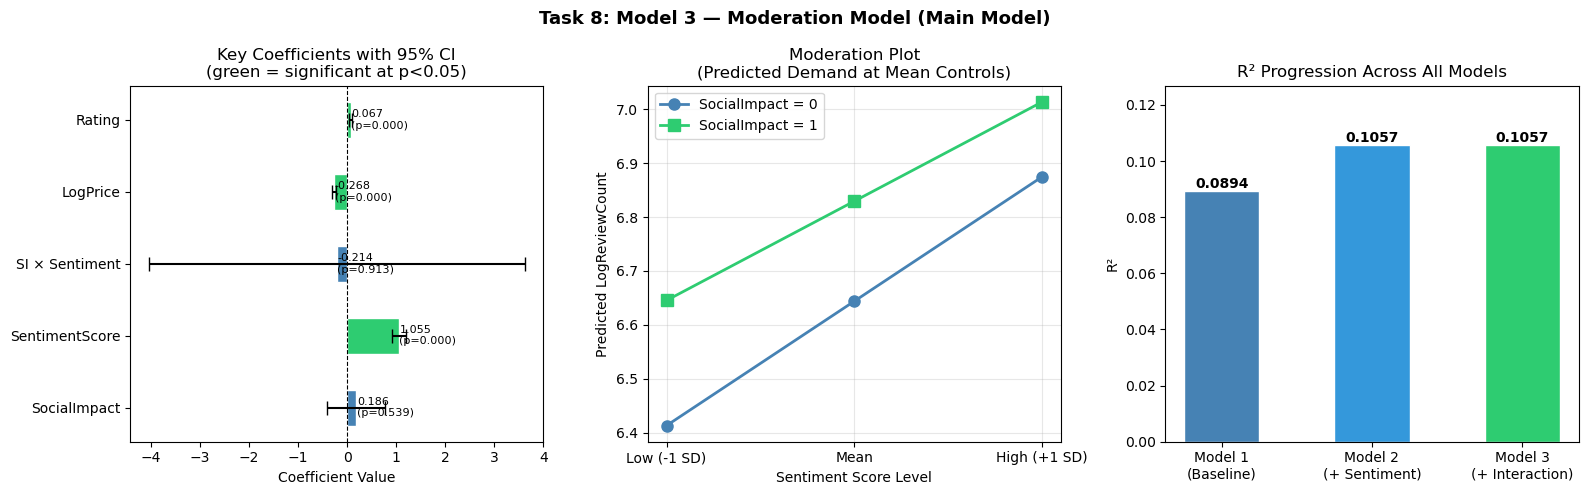


Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression/model3_results.png


In [84]:
# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Task 8: Model 3 — Moderation Model (Main Model)',
             fontsize=13, fontweight='bold')

# Plot 1: Key coefficients
key_vars = ['SocialImpact_c', 'SentimentScore_c', 'SocialImpact_x_Sentiment_c',
            'LogPrice_winsorized_std', 'average_rating_std']
coefs    = model3.params[key_vars]
cis      = model3.conf_int().loc[key_vars]
colors   = ['#2ecc71' if model3.pvalues[v] < 0.05 else 'steelblue'
            for v in key_vars]

axes[0].barh(key_vars, coefs.values,
             xerr=[(coefs.values - cis[0].values),
                   (cis[1].values - coefs.values)],
             color=colors, edgecolor='white', height=0.5,
             error_kw=dict(ecolor='black', capsize=5))
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Key Coefficients with 95% CI\n(green = significant at p<0.05)')
axes[0].set_xlabel('Coefficient Value')
axes[0].set_yticklabels(['SocialImpact', 'SentimentScore',
                          'SI × Sentiment', 'LogPrice', 'Rating'])
for i, v in enumerate(key_vars):
    coef = model3.params[v]
    p    = model3.pvalues[v]
    axes[0].text(coef + 0.01, i, f'{coef:.3f}\n(p={p:.3f})',
                 va='center', fontsize=8)

# Plot 2: Moderation plot
sent_labels = list(sentiment_levels.keys())
si0_vals    = [predictions[l][0] for l in sent_labels]
si1_vals    = [predictions[l][1] for l in sent_labels]
x           = np.arange(len(sent_labels))

axes[1].plot(x, si0_vals, 'o-', color='steelblue', linewidth=2,
             markersize=8, label='SocialImpact = 0')
axes[1].plot(x, si1_vals, 's-', color='#2ecc71', linewidth=2,
             markersize=8, label='SocialImpact = 1')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sent_labels)
axes[1].set_xlabel('Sentiment Score Level')
axes[1].set_ylabel('Predicted LogReviewCount')
axes[1].set_title('Moderation Plot\n(Predicted Demand at Mean Controls)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: R² progression
models_labels = ['Model 1\n(Baseline)', 'Model 2\n(+ Sentiment)',
                 'Model 3\n(+ Interaction)']
r2_values     = [0.0894, 0.1057, model3.rsquared]
bar_colors    = ['steelblue', '#3498db', '#2ecc71']
bars = axes[2].bar(models_labels, r2_values, color=bar_colors,
                   edgecolor='white', width=0.5)
axes[2].set_title('R² Progression Across All Models')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, max(r2_values) * 1.2)
for bar, val in zip(bars, r2_values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{VIZ5}/model3_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {VIZ5}/model3_results.png")

In [85]:
with open(f'{OUTPUTS}/model3_summary.txt', 'w') as f:
    f.write(model3.summary().as_text())
print(f"Saved: {OUTPUTS}/model3_summary.txt")

model3_results = {
    'model':            'Model 3 (Moderation)',
    'r2':               model3.rsquared,
    'adj_r2':           model3.rsquared_adj,
    'n':                int(model3.nobs),
    'si_coef':          model3.params['SocialImpact_c'],
    'si_se':            model3.bse['SocialImpact_c'],
    'si_p':             model3.pvalues['SocialImpact_c'],
    'sentiment_coef':   model3.params['SentimentScore_c'],
    'sentiment_p':      model3.pvalues['SentimentScore_c'],
    'interaction_coef': model3.params['SocialImpact_x_Sentiment_c'],
    'interaction_p':    model3.pvalues['SocialImpact_x_Sentiment_c'],
}
print(f"\n✓ Task 8 Complete — model3_results stored for Task 9")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/outputs/model3_summary.txt

✓ Task 8 Complete — model3_results stored for Task 9


### Task 11 - Handmade Variable Model

In [86]:
df = pd.read_csv(f'{MOD}/etsy_regression.csv')

In [87]:
cat_dummy_cols = [c for c in df.columns if c.startswith('cat_')]
y = df['LogReviewCount']

In [88]:
def prep_X(X):
    bool_cols = X.select_dtypes(include='bool').columns.tolist()
    X[bool_cols] = X[bool_cols].astype(int)
    return sm.add_constant(X)

In [89]:
print("\n" + "="*60)
print("MODEL 4: Main Effect")
print("="*60)

X4_cols = (
    ['SocialImpact'] +
    ['SentimentScore'] +
    ['Handmade'] +                    # NEW main effect
    ['LogPrice_winsorized_std'] +
    ['average_rating_std'] +
    cat_dummy_cols
)

X4 = prep_X(df[X4_cols].copy())
model4 = sm.OLS(y, X4).fit()
print(model4.summary())


MODEL 4: Main Effect
                            OLS Regression Results                            
Dep. Variable:         LogReviewCount   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     79.73
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          2.01e-246
Time:                        22:11:49   Log-Likelihood:                -20248.
No. Observations:               10406   AIC:                         4.053e+04
Df Residuals:                   10389   BIC:                         4.065e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [90]:
print(f"\n{'='*55}")
print("VIF Check — Model 4")
print(f"{'='*55}")
X4_vif  = X4.drop(columns=['const'])
vif_data = pd.DataFrame({
    'Variable': X4_vif.columns,
    'VIF': [variance_inflation_factor(X4_vif.values, i)
            for i in range(X4_vif.shape[1])]
}).sort_values('VIF', ascending=False)
for _, row in vif_data.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Variable']:<35} {row['VIF']:>8.3f}{flag}")



VIF Check — Model 4
  SentimentScore                         2.115 ✓
  Handmade                               1.620 ✓
  cat_Shoes                              1.347 ✓
  cat_Art & Collectibles                 1.140 ✓
  LogPrice_winsorized_std                1.085 ✓
  cat_Accessories                        1.084 ✓
  cat_Pet Supplies                       1.047 ✓
  cat_Toys & Games                       1.037 ✓
  cat_Jewellery                          1.011 ✓
  average_rating_std                     1.011 ✓
  cat_Bath & Beauty                      1.009 ✓
  cat_Clothing                           1.008 ✓
  cat_Paper & Party Supplies             1.006 ✓
  SocialImpact                           1.006 ✓
  cat_Home & Living                      1.001 ✓
  cat_Electronics & Accessories          1.000 ✓


In [91]:
print(f"\n{'='*55}")
print("Model 4 — Key Results")
print(f"{'='*55}")
print(f"  R²:          {model4.rsquared:.4f}")
print(f"  Adj. R²:     {model4.rsquared_adj:.4f}")
print(f"  R² change from Model 2: {model4.rsquared - model2.rsquared:+.4f}")
print(f"  N:           {int(model4.nobs):,}")

for var, label in [('SocialImpact', 'SocialImpact (β₁)'),
                    ('SentimentScore', 'SentimentScore (β₂)'),
                    ('Handmade', 'Handmade (β₃)')]:
    coef = model4.params[var]
    se   = model4.bse[var]
    p    = model4.pvalues[var]
    ci   = model4.conf_int().loc[var]
    sig  = '✓ Significant' if p < 0.05 else '✗ Not significant'
    print(f"\n  {label}:")
    print(f"    Coefficient: {coef:>8.4f}")
    print(f"    Std Error:   {se:>8.4f}")
    print(f"    p-value:     {p:>8.4f}  {sig}")
    print(f"    95% CI:      [{ci[0]:.4f}, {ci[1]:.4f}]")
    if var == 'Handmade':
        direction = 'MORE' if coef > 0 else 'LESS'
        print(f"    → Handmade listings get {direction} demand than non-handmade")



Model 4 — Key Results
  R²:          0.1094
  Adj. R²:     0.1080
  R² change from Model 2: +0.0037
  N:           10,406

  SocialImpact (β₁):
    Coefficient:   0.1537
    Std Error:     0.2873
    p-value:       0.5928  ✗ Not significant
    95% CI:      [-0.4096, 0.7169]

  SentimentScore (β₂):
    Coefficient:   1.1119
    Std Error:     0.0771
    p-value:       0.0000  ✓ Significant
    95% CI:      [0.9607, 1.2630]

  Handmade (β₃):
    Coefficient:  -0.2347
    Std Error:     0.0357
    p-value:       0.0000  ✓ Significant
    95% CI:      [-0.3046, -0.1647]
    → Handmade listings get LESS demand than non-handmade


In [92]:
with open(f'{OUTPUTS}/model4_summary.txt', 'w') as f:
    f.write(model4.summary().as_text())
print(f"\nSaved: {OUTPUTS}/model4_summary.txt")


Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/outputs/model4_summary.txt


### Task 12 - Handmade Moderation Model

In [93]:
print("\n" + "="*60)
print("MODEL 5: Moderation (MAIN MODEL for Handmade)")
print("="*60)

X5_cols = (
    ['SocialImpact_c'] +
    ['SentimentScore_c'] +
    ['Handmade_c'] +                        # mean-centered
    ['SocialImpact_x_Sentiment_c'] +
    ['Handmade_x_Sentiment_c'] +            # NEW interaction
    ['LogPrice_winsorized_std'] +
    ['average_rating_std'] +
    cat_dummy_cols
)

X5 = prep_X(df[X5_cols].copy())
model5 = sm.OLS(y, X5).fit()
print(model5.summary())


MODEL 5: Moderation (MAIN MODEL for Handmade)
                            OLS Regression Results                            
Dep. Variable:         LogReviewCount   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     70.90
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          1.12e-244
Time:                        22:11:49   Log-Likelihood:                -20248.
No. Observations:               10406   AIC:                         4.053e+04
Df Residuals:                   10387   BIC:                         4.067e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [94]:
print(f"\n{'='*55}")
print("VIF Check — Model 5")
print(f"{'='*55}")
X5_vif   = X5.drop(columns=['const'])
vif_data5 = pd.DataFrame({
    'Variable': X5_vif.columns,
    'VIF': [variance_inflation_factor(X5_vif.values, i)
            for i in range(X5_vif.shape[1])]
}).sort_values('VIF', ascending=False)
for _, row in vif_data5.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Variable']:<35} {row['VIF']:>8.3f}{flag}")


VIF Check — Model 5
  SentimentScore_c                       1.134 ✓
  Handmade_x_Sentiment_c                 1.125 ✓
  SocialImpact_x_Sentiment_c             1.107 ✓
  SocialImpact_c                         1.106 ✓
  LogPrice_winsorized_std                1.070 ✓
  Handmade_c                             1.064 ✓
  cat_Art & Collectibles                 1.038 ✓
  cat_Shoes                              1.029 ✓
  cat_Accessories                        1.017 ✓
  average_rating_std                     1.012 ✓
  cat_Electronics & Accessories          1.009 ✓
  cat_Pet Supplies                       1.008 ✓
  cat_Toys & Games                       1.005 ✓
  cat_Bath & Beauty                      1.003 ✓
  cat_Paper & Party Supplies             1.003 ✓
  cat_Jewellery                          1.001 ✓
  cat_Clothing                           1.001 ✓
  cat_Home & Living                      1.000 ✓


In [95]:
print(f"\n{'='*55}")
print("Model 5 — Key Results (MAIN MODEL for Handmade)")
print(f"{'='*55}")
print(f"  R²:          {model5.rsquared:.4f}")
print(f"  Adj. R²:     {model5.rsquared_adj:.4f}")
print(f"  R² change from Model 4: {model5.rsquared - model4.rsquared:+.4f}")
print(f"  N:           {int(model5.nobs):,}")

for var, label in [
    ('SocialImpact_c',           'SocialImpact (β₁)'),
    ('SentimentScore_c',         'SentimentScore (β₂)'),
    ('Handmade_c',               'Handmade (β₃)'),
    ('SocialImpact_x_Sentiment_c','SI × Sentiment (β₄)'),
    ('Handmade_x_Sentiment_c',   'Handmade × Sentiment (β₅) — KEY'),
]:
    coef = model5.params[var]
    se   = model5.bse[var]
    p    = model5.pvalues[var]
    ci   = model5.conf_int().loc[var]
    sig  = '✓ Significant' if p < 0.05 else '✗ Not significant'
    print(f"\n  {label}:")
    print(f"    Coefficient: {coef:>8.4f}")
    print(f"    Std Error:   {se:>8.4f}")
    print(f"    p-value:     {p:>8.4f}  {sig}")
    print(f"    95% CI:      [{ci[0]:.4f}, {ci[1]:.4f}]")
    if var == 'Handmade_x_Sentiment_c':
        direction = 'STRENGTHENS' if coef > 0 else 'DAMPENS'
        print(f"    → Sentiment {direction} the handmade effect on demand")


Model 5 — Key Results (MAIN MODEL for Handmade)
  R²:          0.1094
  Adj. R²:     0.1079
  R² change from Model 4: +0.0001
  N:           10,406

  SocialImpact (β₁):
    Coefficient:   0.1617
    Std Error:     0.3019
    p-value:       0.5921  ✗ Not significant
    95% CI:      [-0.4300, 0.7534]

  SentimentScore (β₂):
    Coefficient:   1.0908
    Std Error:     0.0810
    p-value:       0.0000  ✓ Significant
    95% CI:      [0.9320, 1.2495]

  Handmade (β₃):
    Coefficient:  -0.2315
    Std Error:     0.0359
    p-value:       0.0000  ✓ Significant
    95% CI:      [-0.3018, -0.1611]

  SI × Sentiment (β₄):
    Coefficient:  -0.1650
    Std Error:     1.9506
    p-value:       0.9326  ✗ Not significant
    95% CI:      [-3.9886, 3.6585]

  Handmade × Sentiment (β₅) — KEY:
    Coefficient:  -0.1576
    Std Error:     0.1853
    p-value:       0.3950  ✗ Not significant
    95% CI:      [-0.5208, 0.2056]
    → Sentiment DAMPENS the handmade effect on demand


In [96]:
with open(f'{OUTPUTS}/model5_summary.txt', 'w') as f:
    f.write(model5.summary().as_text())
print(f"\nSaved: {OUTPUTS}/model5_summary.txt")


Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/outputs/model5_summary.txt


### Task 13 - Lexical Diversity Model

In [91]:
df = pd.read_csv(f'{MOD}/etsy_regression.csv')

In [93]:
cat_dummy_cols = [c for c in df.columns if c.startswith('cat_')]
y = df['LogReviewCount']

def prep_X(X):
    bool_cols = X.select_dtypes(include='bool').columns.tolist()
    X[bool_cols] = X[bool_cols].astype(int)
    return sm.add_constant(X)

In [94]:
X6_cols = (
    ['SocialImpact'] +
    ['SentimentScore'] +
    ['Handmade'] +
    ['lexical_diversity_std'] +        # NEW — lexical diversity standardized
    ['LogPrice_winsorized_std'] +
    ['average_rating_std'] +
    cat_dummy_cols
)

In [95]:
X6 = prep_X(df[X6_cols].copy())
model6 = sm.OLS(y, X6).fit()

print("\n" + "="*60)
print(model6.summary())



                            OLS Regression Results                            
Dep. Variable:         LogReviewCount   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     99.14
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          1.43e-322
Time:                        19:03:53   Log-Likelihood:                -20068.
No. Observations:               10406   AIC:                         4.017e+04
Df Residuals:                   10388   BIC:                         4.030e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const        

In [96]:
# =============================================================================
# VIF Check
# =============================================================================
print(f"\n{'='*55}")
print("VIF Check — Model 6")
print(f"{'='*55}")
X6_vif  = X6.drop(columns=['const'])
vif_data = pd.DataFrame({
    'Variable': X6_vif.columns,
    'VIF': [variance_inflation_factor(X6_vif.values, i)
            for i in range(X6_vif.shape[1])]
}).sort_values('VIF', ascending=False)
for _, row in vif_data.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Variable']:<35} {row['VIF']:>8.3f}{flag}")



VIF Check — Model 6
  SentimentScore                         2.122 ✓
  Handmade                               1.623 ✓
  cat_Shoes                              1.354 ✓
  cat_Art & Collectibles                 1.142 ✓
  LogPrice_winsorized_std                1.088 ✓
  cat_Accessories                        1.085 ✓
  cat_Pet Supplies                       1.050 ✓
  cat_Toys & Games                       1.037 ✓
  lexical_diversity_std                  1.034 ✓
  average_rating_std                     1.016 ✓
  cat_Jewellery                          1.011 ✓
  cat_Bath & Beauty                      1.009 ✓
  cat_Clothing                           1.008 ✓
  cat_Paper & Party Supplies             1.006 ✓
  SocialImpact                           1.006 ✓
  cat_Home & Living                      1.001 ✓
  cat_Electronics & Accessories          1.000 ✓


In [97]:
# =============================================================================
# Key Results
# =============================================================================
print(f"\n{'='*55}")
print("Model 6 — Key Results (Lexical Diversity Main Effect)")
print(f"{'='*55}")
print(f"  R²:          {model6.rsquared:.4f}")
print(f"  Adj. R²:     {model6.rsquared_adj:.4f}")
print(f"  N:           {int(model6.nobs):,}")

for var, label in [
    ('SocialImpact',        'SocialImpact (β₁)'),
    ('SentimentScore',      'SentimentScore (β₂)'),
    ('Handmade',            'Handmade (β₃)'),
    ('lexical_diversity_std','LexicalDiversity (β₄)'),
]:
    coef = model6.params[var]
    se   = model6.bse[var]
    p    = model6.pvalues[var]
    ci   = model6.conf_int().loc[var]
    sig  = '✓ Significant' if p < 0.05 else '✗ Not significant'
    print(f"\n  {label}:")
    print(f"    Coefficient: {coef:>8.4f}")
    print(f"    Std Error:   {se:>8.4f}")
    print(f"    p-value:     {p:>8.4f}  {sig}")
    print(f"    95% CI:      [{ci[0]:.4f}, {ci[1]:.4f}]")

# R² change from Model 4
r2_m4    = 0.1094
r2_change = model6.rsquared - r2_m4
print(f"\n  R² change from Model 4: {r2_change:+.4f}")



Model 6 — Key Results (Lexical Diversity Main Effect)
  R²:          0.1396
  Adj. R²:     0.1382
  N:           10,406

  SocialImpact (β₁):
    Coefficient:   0.0452
    Std Error:     0.2825
    p-value:       0.8730  ✗ Not significant
    95% CI:      [-0.5085, 0.5989]

  SentimentScore (β₂):
    Coefficient:   0.5348
    Std Error:     0.0816
    p-value:       0.0000  ✓ Significant
    95% CI:      [0.3749, 0.6947]

  Handmade (β₃):
    Coefficient:  -0.2826
    Std Error:     0.0352
    p-value:       0.0000  ✓ Significant
    95% CI:      [-0.3515, -0.2136]

  LexicalDiversity (β₄):
    Coefficient:  -0.3420
    Std Error:     0.0179
    p-value:       0.0000  ✓ Significant
    95% CI:      [-0.3770, -0.3069]

  R² change from Model 4: +0.0302


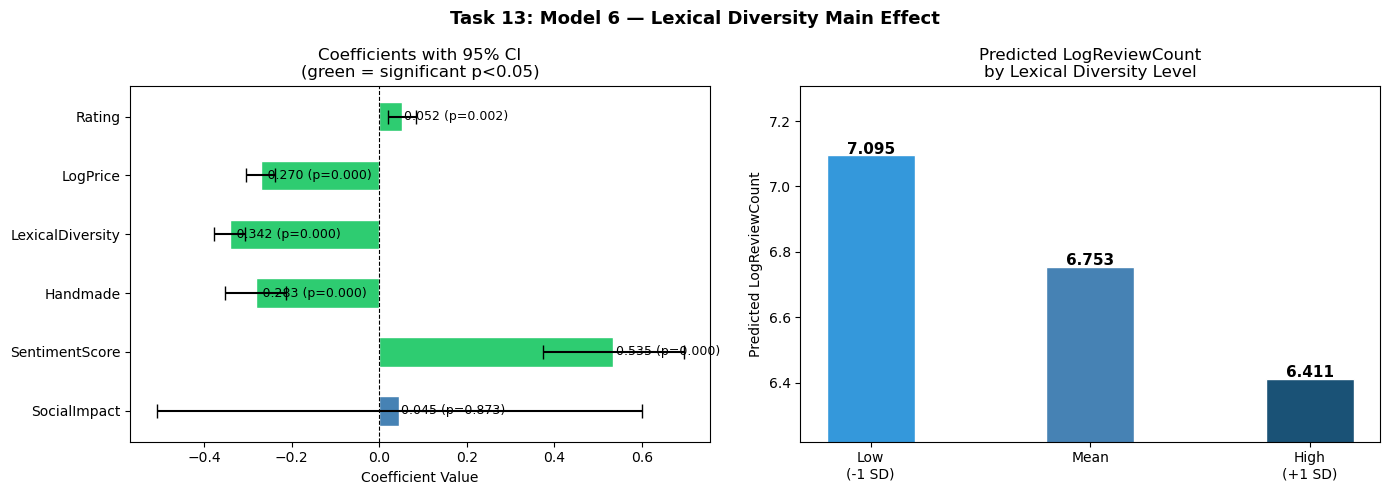

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression/model6_results.png


In [98]:
# =============================================================================
# Visualization — 2 subplots
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 13: Model 6 — Lexical Diversity Main Effect',
             fontsize=13, fontweight='bold')

# Plot 1: Coefficient plot
key_vars6 = ['SocialImpact', 'SentimentScore', 'Handmade',
             'lexical_diversity_std',
             'LogPrice_winsorized_std', 'average_rating_std']
coefs6    = model6.params[key_vars6]
cis6      = model6.conf_int().loc[key_vars6]
colors6   = ['#2ecc71' if model6.pvalues[v] < 0.05 else 'steelblue'
             for v in key_vars6]
labels6   = ['SocialImpact', 'SentimentScore', 'Handmade',
             'LexicalDiversity', 'LogPrice', 'Rating']

axes[0].barh(labels6, coefs6.values,
             xerr=[(coefs6.values - cis6[0].values),
                   (cis6[1].values - coefs6.values)],
             color=colors6, edgecolor='white', height=0.5,
             error_kw=dict(ecolor='black', capsize=5))
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Coefficients with 95% CI\n(green = significant p<0.05)')
axes[0].set_xlabel('Coefficient Value')
for i, v in enumerate(key_vars6):
    coef = model6.params[v]
    p    = model6.pvalues[v]
    axes[0].text(coef + 0.005, i, f'{coef:.3f} (p={p:.3f})',
                 va='center', fontsize=9)

# Plot 2: Predicted LogReviewCount at Low/Mean/High Lexical Diversity
cat_zeros     = {col: 0 for col in cat_dummy_cols}
lex_levels    = {
    'Low\n(-1 SD)':  df['lexical_diversity'].mean() - df['lexical_diversity'].std(),
    'Mean':          df['lexical_diversity'].mean(),
    'High\n(+1 SD)': df['lexical_diversity'].mean() + df['lexical_diversity'].std(),
}

preds_lex = {}
for label, lex_val in lex_levels.items():
    lex_std = (lex_val - df['lexical_diversity'].mean()) / df['lexical_diversity'].std()
    row = {
        'const': 1,
        'SocialImpact': 0,
        'SentimentScore': df['SentimentScore'].mean(),
        'Handmade': 0,
        'lexical_diversity_std': lex_std,
        'LogPrice_winsorized_std': 0,
        'average_rating_std': 0,
    }
    row.update(cat_zeros)
    x_pred = pd.DataFrame([row])[X6.columns]
    preds_lex[label] = model6.predict(x_pred)[0]

bars = axes[1].bar(list(preds_lex.keys()),
                   list(preds_lex.values()),
                   color=['#3498db', 'steelblue', '#1a5276'],
                   edgecolor='white', width=0.4)
axes[1].set_title('Predicted LogReviewCount\nby Lexical Diversity Level')
axes[1].set_ylabel('Predicted LogReviewCount')
axes[1].set_ylim(min(preds_lex.values()) * 0.97,
                 max(preds_lex.values()) * 1.03)
for bar, val in zip(bars, preds_lex.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{VIZ5}/model6_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ5}/model6_results.png")


In [99]:
with open(f'{OUTPUTS}/model6_summary.txt', 'w') as f:
    f.write(model6.summary().as_text())
print(f"Saved: {OUTPUTS}/model6_summary.txt")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/outputs/model6_summary.txt


### Task 14 - Lexical Diversity Moderation Model

In [100]:
df = pd.read_csv(f'{MOD}/etsy_regression.csv')
print(f"Loaded: {df.shape[0]:,} rows")

cat_dummy_cols = [c for c in df.columns if c.startswith('cat_')]
y = df['LogReviewCount']

def prep_X(X):
    bool_cols = X.select_dtypes(include='bool').columns.tolist()
    X[bool_cols] = X[bool_cols].astype(int)
    return sm.add_constant(X)

Loaded: 10,406 rows


In [101]:
X7_cols = (
    ['SocialImpact_c'] +
    ['SentimentScore_c'] +
    ['Handmade_c'] +
    ['lexical_diversity_c'] +              # mean-centered
    ['LexDiv_x_Sentiment_c'] +             # interaction term
    ['LogPrice_winsorized_std'] +
    ['average_rating_std'] +
    cat_dummy_cols
)

X7 = prep_X(df[X7_cols].copy())
model7 = sm.OLS(y, X7).fit()

print("\n" + "="*60)
print(model7.summary())


                            OLS Regression Results                            
Dep. Variable:         LogReviewCount   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     93.70
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          8.25e-322
Time:                        22:18:58   Log-Likelihood:                -20068.
No. Observations:               10406   AIC:                         4.017e+04
Df Residuals:                   10387   BIC:                         4.031e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const        

In [102]:
print(f"\n{'='*55}")
print("VIF Check — Model 7")
print(f"{'='*55}")
X7_vif   = X7.drop(columns=['const'])
vif_data = pd.DataFrame({
    'Variable': X7_vif.columns,
    'VIF': [variance_inflation_factor(X7_vif.values, i)
            for i in range(X7_vif.shape[1])]
}).sort_values('VIF', ascending=False)
for _, row in vif_data.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Variable']:<35} {row['VIF']:>8.3f}{flag}")


VIF Check — Model 7
  SentimentScore_c                       1.635 ✓
  LexDiv_x_Sentiment_c                   1.564 ✓
  lexical_diversity_c                    1.212 ✓
  LogPrice_winsorized_std                1.073 ✓
  Handmade_c                             1.059 ✓
  cat_Shoes                              1.052 ✓
  cat_Art & Collectibles                 1.052 ✓
  cat_Accessories                        1.021 ✓
  cat_Pet Supplies                       1.018 ✓
  average_rating_std                     1.016 ✓
  cat_Electronics & Accessories          1.012 ✓
  cat_Toys & Games                       1.009 ✓
  cat_Paper & Party Supplies             1.004 ✓
  cat_Bath & Beauty                      1.004 ✓
  SocialImpact_c                         1.003 ✓
  cat_Jewellery                          1.002 ✓
  cat_Clothing                           1.002 ✓
  cat_Home & Living                      1.001 ✓


In [103]:
print(f"\n{'='*55}")
print("Model 7 — Key Results (Lexical Diversity Moderation)")
print(f"{'='*55}")
print(f"  R²:          {model7.rsquared:.4f}")
print(f"  Adj. R²:     {model7.rsquared_adj:.4f}")
print(f"  N:           {int(model7.nobs):,}")

for var, label in [
    ('SocialImpact_c',       'SocialImpact (β₁)'),
    ('SentimentScore_c',     'SentimentScore (β₂)'),
    ('Handmade_c',           'Handmade (β₃)'),
    ('lexical_diversity_c',  'LexicalDiversity (β₄)'),
    ('LexDiv_x_Sentiment_c', 'LexDiv × Sentiment (β₅) — KEY'),
]:
    coef = model7.params[var]
    se   = model7.bse[var]
    p    = model7.pvalues[var]
    ci   = model7.conf_int().loc[var]
    sig  = '✓ Significant' if p < 0.05 else '✗ Not significant'
    print(f"\n  {label}:")
    print(f"    Coefficient: {coef:>8.4f}")
    print(f"    Std Error:   {se:>8.4f}")
    print(f"    p-value:     {p:>8.4f}  {sig}")
    print(f"    95% CI:      [{ci[0]:.4f}, {ci[1]:.4f}]")
    if var == 'LexDiv_x_Sentiment_c':
        direction = 'STRENGTHENS' if coef > 0 else 'DAMPENS'
        print(f"    → Sentiment {direction} the lexical diversity effect")

r2_m6     = 0.1396
r2_change = model7.rsquared - r2_m6
print(f"\n  R² change from Model 6: {r2_change:+.4f}")



Model 7 — Key Results (Lexical Diversity Moderation)
  R²:          0.1397
  Adj. R²:     0.1382
  N:           10,406

  SocialImpact (β₁):
    Coefficient:   0.0458
    Std Error:     0.2825
    p-value:       0.8713  ✗ Not significant
    95% CI:      [-0.5079, 0.5995]

  SentimentScore (β₂):
    Coefficient:   0.5897
    Std Error:     0.0965
    p-value:       0.0000  ✓ Significant
    95% CI:      [0.4007, 0.7788]

  Handmade (β₃):
    Coefficient:  -0.2840
    Std Error:     0.0352
    p-value:       0.0000  ✓ Significant
    95% CI:      [-0.3529, -0.2150]

  LexicalDiversity (β₄):
    Coefficient:  -2.9572
    Std Error:     0.1547
    p-value:       0.0000  ✓ Significant
    95% CI:      [-3.2604, -2.6541]

  LexDiv × Sentiment (β₅) — KEY:
    Coefficient:  -0.5833
    Std Error:     0.5463
    p-value:       0.2857  ✗ Not significant
    95% CI:      [-1.6543, 0.4876]
    → Sentiment DAMPENS the lexical diversity effect

  R² change from Model 6: +0.0001


In [104]:
sentiment_levels = {
    'Low\n(-1 SD)':  df['SentimentScore'].mean() - df['SentimentScore'].std(),
    'Mean':          df['SentimentScore'].mean(),
    'High\n(+1 SD)': df['SentimentScore'].mean() + df['SentimentScore'].std(),
}
cat_zeros    = {col: 0 for col in cat_dummy_cols}
predictions  = {}

for sent_label, sent_val in sentiment_levels.items():
    preds = {}
    for lex_label, lex_val in [
        ('Low (-1 SD)',  df['lexical_diversity'].mean() - df['lexical_diversity'].std()),
        ('High (+1 SD)', df['lexical_diversity'].mean() + df['lexical_diversity'].std()),
    ]:
        si_c   = 0
        hm_c   = 0
        sent_c = sent_val - df['SentimentScore'].mean()
        lex_c  = lex_val  - df['lexical_diversity'].mean()
        row = {
            'const': 1,
            'SocialImpact_c': si_c,
            'SentimentScore_c': sent_c,
            'Handmade_c': hm_c,
            'lexical_diversity_c': lex_c,
            'LexDiv_x_Sentiment_c': lex_c * sent_c,
            'LogPrice_winsorized_std': 0,
            'average_rating_std': 0,
        }
        row.update(cat_zeros)
        x_pred = pd.DataFrame([row])[X7.columns]
        preds[lex_label] = model7.predict(x_pred)[0]
    predictions[sent_label] = preds

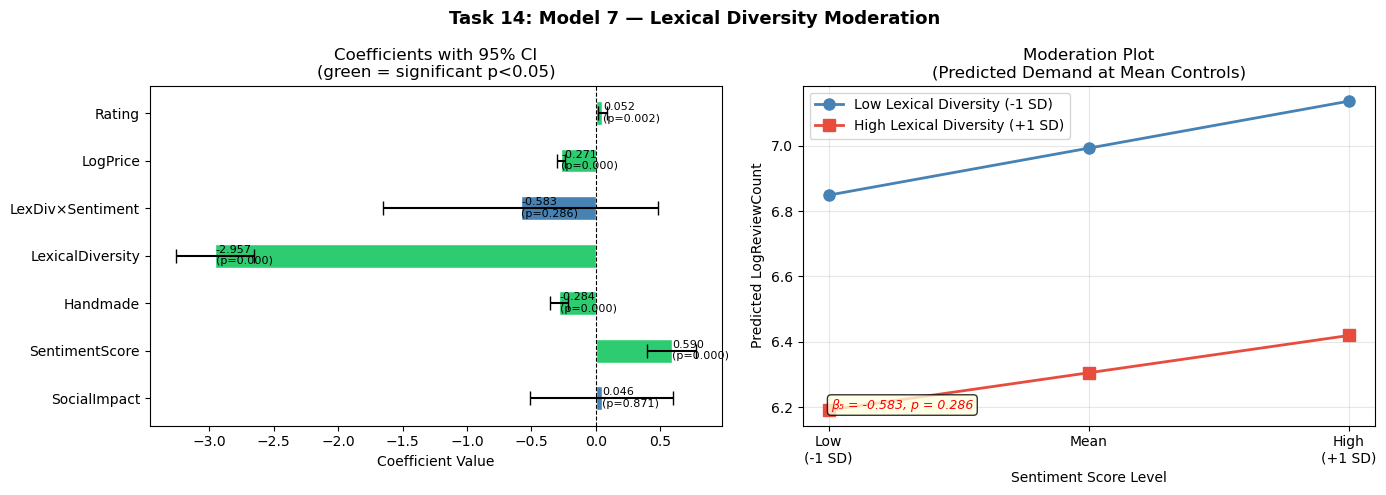

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression/model7_results.png


In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 14: Model 7 — Lexical Diversity Moderation',
             fontsize=13, fontweight='bold')

# Plot 1: Coefficient plot
key_vars7 = ['SocialImpact_c', 'SentimentScore_c', 'Handmade_c',
             'lexical_diversity_c', 'LexDiv_x_Sentiment_c',
             'LogPrice_winsorized_std', 'average_rating_std']
coefs7    = model7.params[key_vars7]
cis7      = model7.conf_int().loc[key_vars7]
colors7   = ['#2ecc71' if model7.pvalues[v] < 0.05 else 'steelblue'
             for v in key_vars7]
labels7   = ['SocialImpact', 'SentimentScore', 'Handmade',
             'LexicalDiversity', 'LexDiv×Sentiment', 'LogPrice', 'Rating']

axes[0].barh(labels7, coefs7.values,
             xerr=[(coefs7.values - cis7[0].values),
                   (cis7[1].values - coefs7.values)],
             color=colors7, edgecolor='white', height=0.5,
             error_kw=dict(ecolor='black', capsize=5))
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Coefficients with 95% CI\n(green = significant p<0.05)')
axes[0].set_xlabel('Coefficient Value')
for i, v in enumerate(key_vars7):
    coef = model7.params[v]
    p    = model7.pvalues[v]
    axes[0].text(coef + 0.005, i, f'{coef:.3f}\n(p={p:.3f})',
                 va='center', fontsize=8)

# Plot 2: Moderation plot
sent_labels_plot = list(sentiment_levels.keys())
low_lex_vals  = [predictions[l]['Low (-1 SD)']  for l in sent_labels_plot]
high_lex_vals = [predictions[l]['High (+1 SD)'] for l in sent_labels_plot]
x             = np.arange(len(sent_labels_plot))

axes[1].plot(x, low_lex_vals,  'o-', color='steelblue', linewidth=2,
             markersize=8, label='Low Lexical Diversity (-1 SD)')
axes[1].plot(x, high_lex_vals, 's-', color='#e74c3c',   linewidth=2,
             markersize=8, label='High Lexical Diversity (+1 SD)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sent_labels_plot)
axes[1].set_xlabel('Sentiment Score Level')
axes[1].set_ylabel('Predicted LogReviewCount')
axes[1].set_title('Moderation Plot\n(Predicted Demand at Mean Controls)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

int_p = model7.pvalues['LexDiv_x_Sentiment_c']
sig_text = f'β₅ = {model7.params["LexDiv_x_Sentiment_c"]:.3f}, p = {int_p:.3f}'
style    = 'normal' if int_p < 0.05 else 'italic'
color    = '#2ecc71' if int_p < 0.05 else 'red'
axes[1].text(0.05, 0.05, sig_text,
             transform=axes[1].transAxes, fontsize=9,
             color=color, style=style,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{VIZ5}/model7_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ5}/model7_results.png")

In [106]:
with open(f'{OUTPUTS}/model7_summary.txt', 'w') as f:
    f.write(model7.summary().as_text())
print(f"Saved: {OUTPUTS}/model7_summary.txt")
print(f"\n✓ Task 14 Complete — Model 7 fitted")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/outputs/model7_summary.txt

✓ Task 14 Complete — Model 7 fitted


### Task 15 - Personalization Model

In [107]:
df = pd.read_csv(f'{MOD}/etsy_regression.csv')
print(f"Loaded: {df.shape[0]:,} rows")

cat_dummy_cols = [c for c in df.columns if c.startswith('cat_')]
y = df['LogReviewCount']

def prep_X(X):
    bool_cols = X.select_dtypes(include='bool').columns.tolist()
    X[bool_cols] = X[bool_cols].astype(int)
    return sm.add_constant(X)


Loaded: 10,406 rows


In [108]:
X8_cols = (
    ['SocialImpact'] +
    ['SentimentScore'] +
    ['Handmade'] +
    ['personalization'] +               # NEW — personalization binary
    ['LogPrice_winsorized_std'] +
    ['average_rating_std'] +
    cat_dummy_cols
)

X8 = prep_X(df[X8_cols].copy())
model8 = sm.OLS(y, X8).fit()

print("\n" + "="*60)
print(model8.summary())


                            OLS Regression Results                            
Dep. Variable:         LogReviewCount   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     77.15
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          2.46e-252
Time:                        22:22:57   Log-Likelihood:                -20232.
No. Observations:               10406   AIC:                         4.050e+04
Df Residuals:                   10388   BIC:                         4.063e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const        

In [109]:
print(f"\n{'='*55}")
print("VIF Check — Model 8")
print(f"{'='*55}")
X8_vif   = X8.drop(columns=['const'])
vif_data = pd.DataFrame({
    'Variable': X8_vif.columns,
    'VIF': [variance_inflation_factor(X8_vif.values, i)
            for i in range(X8_vif.shape[1])]
}).sort_values('VIF', ascending=False)
for _, row in vif_data.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Variable']:<35} {row['VIF']:>8.3f}{flag}")


VIF Check — Model 8
  SentimentScore                         2.651 ✓
  Handmade                               1.637 ✓
  personalization                        1.632 ✓
  cat_Shoes                              1.351 ✓
  cat_Art & Collectibles                 1.143 ✓
  LogPrice_winsorized_std                1.086 ✓
  cat_Accessories                        1.085 ✓
  cat_Pet Supplies                       1.054 ✓
  cat_Toys & Games                       1.037 ✓
  cat_Jewellery                          1.011 ✓
  average_rating_std                     1.011 ✓
  cat_Bath & Beauty                      1.009 ✓
  cat_Clothing                           1.008 ✓
  cat_Paper & Party Supplies             1.007 ✓
  SocialImpact                           1.006 ✓
  cat_Home & Living                      1.001 ✓
  cat_Electronics & Accessories          1.000 ✓


In [110]:
print(f"\n{'='*55}")
print("Model 8 — Key Results (Personalization Main Effect)")
print(f"{'='*55}")
print(f"  R²:          {model8.rsquared:.4f}")
print(f"  Adj. R²:     {model8.rsquared_adj:.4f}")
print(f"  N:           {int(model8.nobs):,}")

for var, label in [
    ('SocialImpact',   'SocialImpact (β₁)'),
    ('SentimentScore', 'SentimentScore (β₂)'),
    ('Handmade',       'Handmade (β₃)'),
    ('personalization','Personalization (β₄)'),
]:
    coef = model8.params[var]
    se   = model8.bse[var]
    p    = model8.pvalues[var]
    ci   = model8.conf_int().loc[var]
    sig  = '✓ Significant' if p < 0.05 else '✗ Not significant'
    print(f"\n  {label}:")
    print(f"    Coefficient: {coef:>8.4f}")
    print(f"    Std Error:   {se:>8.4f}")
    print(f"    p-value:     {p:>8.4f}  {sig}")
    print(f"    95% CI:      [{ci[0]:.4f}, {ci[1]:.4f}]")
    if var == 'personalization':
        direction = 'MORE' if coef > 0 else 'LESS'
        print(f"    → Personalized listings get {direction} demand")

r2_m4     = 0.1094
r2_change = model8.rsquared - r2_m4
print(f"\n  R² change from Model 4: {r2_change:+.4f}")



Model 8 — Key Results (Personalization Main Effect)
  R²:          0.1121
  Adj. R²:     0.1107
  N:           10,406

  SocialImpact (β₁):
    Coefficient:   0.1582
    Std Error:     0.2869
    p-value:       0.5813  ✗ Not significant
    95% CI:      [-0.4042, 0.7206]

  SentimentScore (β₂):
    Coefficient:   1.0555
    Std Error:     0.0776
    p-value:       0.0000  ✓ Significant
    95% CI:      [0.9033, 1.2076]

  Handmade (β₃):
    Coefficient:  -0.2547
    Std Error:     0.0358
    p-value:       0.0000  ✓ Significant
    95% CI:      [-0.3248, -0.1845]

  Personalization (β₄):
    Coefficient:   0.2012
    Std Error:     0.0355
    p-value:       0.0000  ✓ Significant
    95% CI:      [0.1315, 0.2708]
    → Personalized listings get MORE demand

  R² change from Model 4: +0.0027


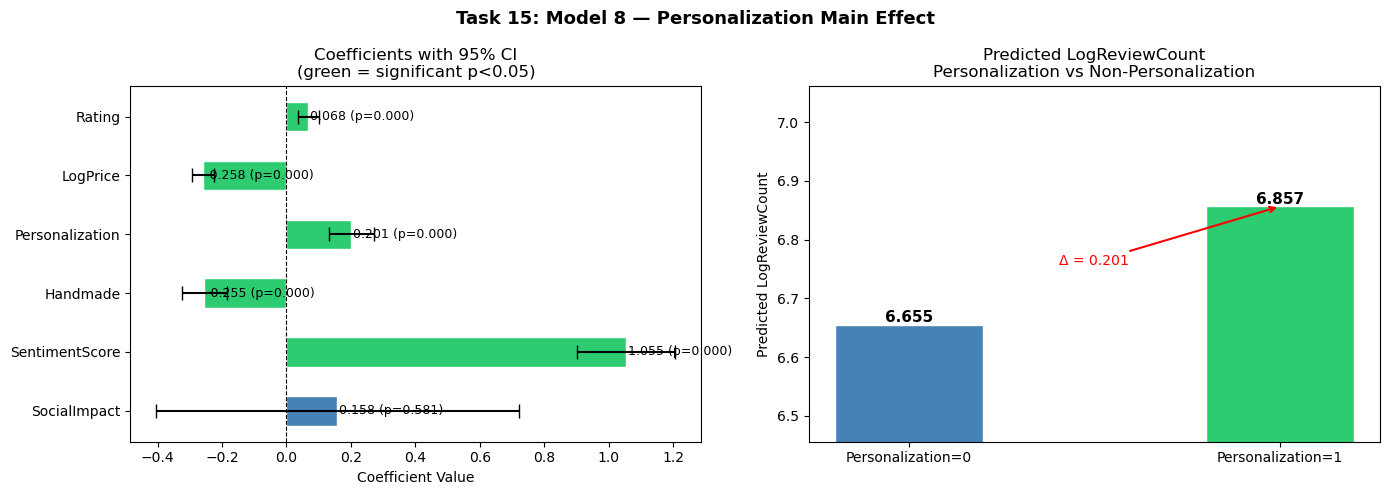

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression/model8_results.png


In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 15: Model 8 — Personalization Main Effect',
             fontsize=13, fontweight='bold')

# Plot 1: Coefficient plot
key_vars8 = ['SocialImpact', 'SentimentScore', 'Handmade',
             'personalization',
             'LogPrice_winsorized_std', 'average_rating_std']
coefs8    = model8.params[key_vars8]
cis8      = model8.conf_int().loc[key_vars8]
colors8   = ['#2ecc71' if model8.pvalues[v] < 0.05 else 'steelblue'
             for v in key_vars8]
labels8   = ['SocialImpact', 'SentimentScore', 'Handmade',
             'Personalization', 'LogPrice', 'Rating']

axes[0].barh(labels8, coefs8.values,
             xerr=[(coefs8.values - cis8[0].values),
                   (cis8[1].values - coefs8.values)],
             color=colors8, edgecolor='white', height=0.5,
             error_kw=dict(ecolor='black', capsize=5))
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Coefficients with 95% CI\n(green = significant p<0.05)')
axes[0].set_xlabel('Coefficient Value')
for i, v in enumerate(key_vars8):
    coef = model8.params[v]
    p    = model8.pvalues[v]
    axes[0].text(coef + 0.005, i, f'{coef:.3f} (p={p:.3f})',
                 va='center', fontsize=9)

# Plot 2: Predicted LogReviewCount — Personalization=0 vs 1
cat_zeros = {col: 0 for col in cat_dummy_cols}
preds_p   = {}
for p_val in [0, 1]:
    row = {
        'const': 1,
        'SocialImpact': 0,
        'SentimentScore': df['SentimentScore'].mean(),
        'Handmade': 0,
        'personalization': p_val,
        'LogPrice_winsorized_std': 0,
        'average_rating_std': 0,
    }
    row.update(cat_zeros)
    x_pred = pd.DataFrame([row])[X8.columns]
    preds_p[p_val] = model8.predict(x_pred)[0]

bars = axes[1].bar(
    ['Personalization=0', 'Personalization=1'],
    [preds_p[0], preds_p[1]],
    color=['steelblue', '#2ecc71'],
    edgecolor='white', width=0.4
)
axes[1].set_title('Predicted LogReviewCount\nPersonalization vs Non-Personalization')
axes[1].set_ylabel('Predicted LogReviewCount')
axes[1].set_ylim(min(preds_p.values()) * 0.97,
                 max(preds_p.values()) * 1.03)
for bar, val in zip(bars, preds_p.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

diff = preds_p[1] - preds_p[0]
axes[1].annotate(
    f'Δ = {diff:.3f}',
    xy=(1, preds_p[1]),
    xytext=(0.5, (preds_p[0] + preds_p[1]) / 2),
    fontsize=10, ha='center', color='red',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5)
)

plt.tight_layout()
plt.savefig(f'{VIZ5}/model8_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ5}/model8_results.png")


In [112]:
with open(f'{OUTPUTS}/model8_summary.txt', 'w') as f:
    f.write(model8.summary().as_text())
print(f"Saved: {OUTPUTS}/model8_summary.txt")
print(f"\n✓ Task 15 Complete — Model 8 fitted")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/outputs/model8_summary.txt

✓ Task 15 Complete — Model 8 fitted


### Task 16 - Personalization Moderation Model

In [113]:
df = pd.read_csv(f'{MOD}/etsy_regression.csv')
print(f"Loaded: {df.shape[0]:,} rows")

cat_dummy_cols = [c for c in df.columns if c.startswith('cat_')]
y = df['LogReviewCount']

def prep_X(X):
    bool_cols = X.select_dtypes(include='bool').columns.tolist()
    X[bool_cols] = X[bool_cols].astype(int)
    return sm.add_constant(X)

Loaded: 10,406 rows


In [114]:
X9_cols = (
    ['SocialImpact_c'] +
    ['SentimentScore_c'] +
    ['Handmade_c'] +
    ['personalization_c'] +                  # mean-centered
    ['Personalization_x_Sentiment_c'] +      # interaction term
    ['LogPrice_winsorized_std'] +
    ['average_rating_std'] +
    cat_dummy_cols
)

X9 = prep_X(df[X9_cols].copy())
model9 = sm.OLS(y, X9).fit()

print("\n" + "="*60)
print(model9.summary())


                            OLS Regression Results                            
Dep. Variable:         LogReviewCount   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     72.86
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          2.20e-251
Time:                        22:46:57   Log-Likelihood:                -20232.
No. Observations:               10406   AIC:                         4.050e+04
Df Residuals:                   10387   BIC:                         4.064e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const        

In [115]:
print(f"\n{'='*55}")
print("VIF Check — Model 9")
print(f"{'='*55}")
X9_vif   = X9.drop(columns=['const'])
vif_data = pd.DataFrame({
    'Variable': X9_vif.columns,
    'VIF': [variance_inflation_factor(X9_vif.values, i)
            for i in range(X9_vif.shape[1])]
}).sort_values('VIF', ascending=False)
for _, row in vif_data.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Variable']:<35} {row['VIF']:>8.3f}{flag}")


VIF Check — Model 9
  SentimentScore_c                       1.275 ✓
  Personalization_x_Sentiment_c          1.251 ✓
  personalization_c                      1.083 ✓
  LogPrice_winsorized_std                1.069 ✓
  Handmade_c                             1.063 ✓
  cat_Art & Collectibles                 1.041 ✓
  cat_Shoes                              1.029 ✓
  cat_Pet Supplies                       1.018 ✓
  cat_Accessories                        1.018 ✓
  average_rating_std                     1.012 ✓
  cat_Electronics & Accessories          1.008 ✓
  cat_Paper & Party Supplies             1.005 ✓
  cat_Bath & Beauty                      1.004 ✓
  cat_Toys & Games                       1.003 ✓
  SocialImpact_c                         1.002 ✓
  cat_Clothing                           1.001 ✓
  cat_Jewellery                          1.001 ✓
  cat_Home & Living                      1.001 ✓


In [116]:
print(f"\n{'='*55}")
print("Model 9 — Key Results (Personalization Moderation)")
print(f"{'='*55}")
print(f"  R²:          {model9.rsquared:.4f}")
print(f"  Adj. R²:     {model9.rsquared_adj:.4f}")
print(f"  N:           {int(model9.nobs):,}")

for var, label in [
    ('SocialImpact_c',               'SocialImpact (β₁)'),
    ('SentimentScore_c',             'SentimentScore (β₂)'),
    ('Handmade_c',                   'Handmade (β₃)'),
    ('personalization_c',            'Personalization (β₄)'),
    ('Personalization_x_Sentiment_c','Personalization × Sentiment (β₅) — KEY'),
]:
    coef = model9.params[var]
    se   = model9.bse[var]
    p    = model9.pvalues[var]
    ci   = model9.conf_int().loc[var]
    sig  = '✓ Significant' if p < 0.05 else '✗ Not significant'
    print(f"\n  {label}:")
    print(f"    Coefficient: {coef:>8.4f}")
    print(f"    Std Error:   {se:>8.4f}")
    print(f"    p-value:     {p:>8.4f}  {sig}")
    print(f"    95% CI:      [{ci[0]:.4f}, {ci[1]:.4f}]")
    if var == 'Personalization_x_Sentiment_c':
        direction = 'STRENGTHENS' if coef > 0 else 'DAMPENS'
        print(f"    → Sentiment {direction} the personalization effect")

r2_m8     = 0.1121
r2_change = model9.rsquared - r2_m8
print(f"\n  R² change from Model 8: {r2_change:+.4f}")


Model 9 — Key Results (Personalization Moderation)
  R²:          0.1121
  Adj. R²:     0.1106
  N:           10,406

  SocialImpact (β₁):
    Coefficient:   0.1582
    Std Error:     0.2869
    p-value:       0.5813  ✗ Not significant
    95% CI:      [-0.4042, 0.7206]

  SentimentScore (β₂):
    Coefficient:   1.0554
    Std Error:     0.0860
    p-value:       0.0000  ✓ Significant
    95% CI:      [0.8869, 1.2239]

  Handmade (β₃):
    Coefficient:  -0.2547
    Std Error:     0.0358
    p-value:       0.0000  ✓ Significant
    95% CI:      [-0.3249, -0.1845]

  Personalization (β₄):
    Coefficient:   0.2012
    Std Error:     0.0361
    p-value:       0.0000  ✓ Significant
    95% CI:      [0.1305, 0.2719]

  Personalization × Sentiment (β₅) — KEY:
    Coefficient:  -0.0004
    Std Error:     0.2026
    p-value:       0.9983  ✗ Not significant
    95% CI:      [-0.3975, 0.3967]
    → Sentiment DAMPENS the personalization effect

  R² change from Model 8: +0.0000


In [117]:
sentiment_levels = {
    'Low\n(-1 SD)':  df['SentimentScore'].mean() - df['SentimentScore'].std(),
    'Mean':          df['SentimentScore'].mean(),
    'High\n(+1 SD)': df['SentimentScore'].mean() + df['SentimentScore'].std(),
}
cat_zeros    = {col: 0 for col in cat_dummy_cols}
predictions  = {}

for sent_label, sent_val in sentiment_levels.items():
    preds = {}
    for p_val in [0, 1]:
        si_c   = 0
        hm_c   = 0
        sent_c = sent_val - df['SentimentScore'].mean()
        p_c    = p_val    - df['personalization'].mean()
        row = {
            'const': 1,
            'SocialImpact_c': si_c,
            'SentimentScore_c': sent_c,
            'Handmade_c': hm_c,
            'personalization_c': p_c,
            'Personalization_x_Sentiment_c': p_c * sent_c,
            'LogPrice_winsorized_std': 0,
            'average_rating_std': 0,
        }
        row.update(cat_zeros)
        x_pred = pd.DataFrame([row])[X9.columns]
        preds[p_val] = model9.predict(x_pred)[0]
    predictions[sent_label] = preds


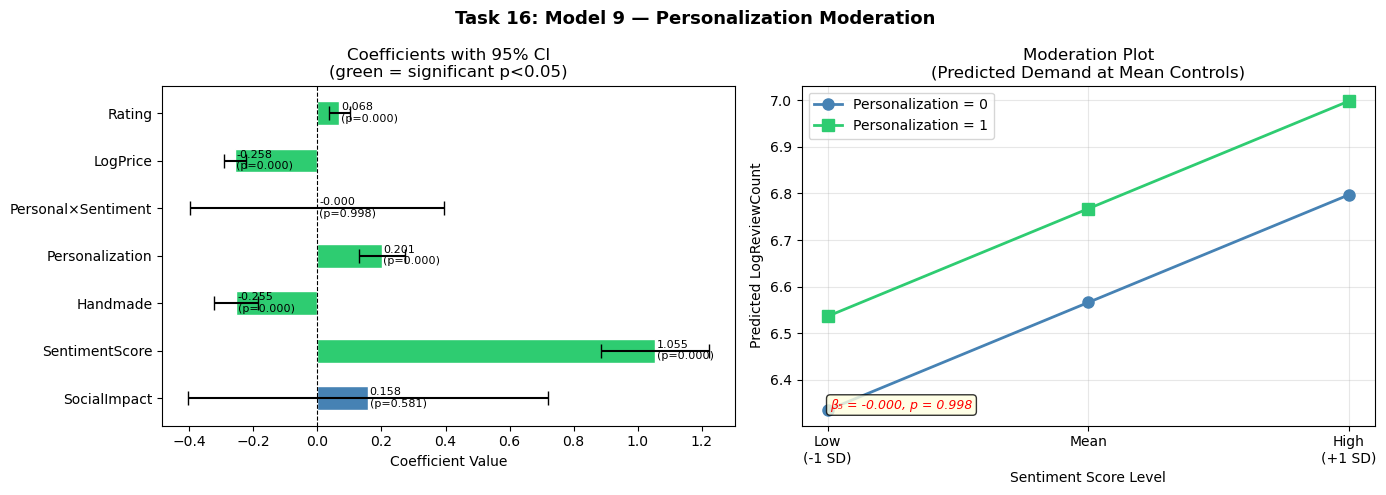

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression/model9_results.png


In [118]:
# =============================================================================
# Visualization — 2 subplots
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 16: Model 9 — Personalization Moderation',
             fontsize=13, fontweight='bold')

# Plot 1: Coefficient plot
key_vars9 = ['SocialImpact_c', 'SentimentScore_c', 'Handmade_c',
             'personalization_c', 'Personalization_x_Sentiment_c',
             'LogPrice_winsorized_std', 'average_rating_std']
coefs9    = model9.params[key_vars9]
cis9      = model9.conf_int().loc[key_vars9]
colors9   = ['#2ecc71' if model9.pvalues[v] < 0.05 else 'steelblue'
             for v in key_vars9]
labels9   = ['SocialImpact', 'SentimentScore', 'Handmade',
             'Personalization', 'Personal×Sentiment', 'LogPrice', 'Rating']

axes[0].barh(labels9, coefs9.values,
             xerr=[(coefs9.values - cis9[0].values),
                   (cis9[1].values - coefs9.values)],
             color=colors9, edgecolor='white', height=0.5,
             error_kw=dict(ecolor='black', capsize=5))
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Coefficients with 95% CI\n(green = significant p<0.05)')
axes[0].set_xlabel('Coefficient Value')
for i, v in enumerate(key_vars9):
    coef = model9.params[v]
    p    = model9.pvalues[v]
    axes[0].text(coef + 0.005, i, f'{coef:.3f}\n(p={p:.3f})',
                 va='center', fontsize=8)

# Plot 2: Moderation plot
sent_labels_plot = list(sentiment_levels.keys())
p0_vals  = [predictions[l][0] for l in sent_labels_plot]
p1_vals  = [predictions[l][1] for l in sent_labels_plot]
x        = np.arange(len(sent_labels_plot))

axes[1].plot(x, p0_vals, 'o-', color='steelblue', linewidth=2,
             markersize=8, label='Personalization = 0')
axes[1].plot(x, p1_vals, 's-', color='#2ecc71',   linewidth=2,
             markersize=8, label='Personalization = 1')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sent_labels_plot)
axes[1].set_xlabel('Sentiment Score Level')
axes[1].set_ylabel('Predicted LogReviewCount')
axes[1].set_title('Moderation Plot\n(Predicted Demand at Mean Controls)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

int_p    = model9.pvalues['Personalization_x_Sentiment_c']
sig_text = f'β₅ = {model9.params["Personalization_x_Sentiment_c"]:.3f}, p = {int_p:.3f}'
style    = 'normal' if int_p < 0.05 else 'italic'
color    = '#2ecc71' if int_p < 0.05 else 'red'
axes[1].text(0.05, 0.05, sig_text,
             transform=axes[1].transAxes, fontsize=9,
             color=color, style=style,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{VIZ5}/model9_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ5}/model9_results.png")


In [119]:
with open(f'{OUTPUTS}/model9_summary.txt', 'w') as f:
    f.write(model9.summary().as_text())
print(f"Saved: {OUTPUTS}/model9_summary.txt")
print(f"\n✓ Task 16 Complete — Model 9 fitted")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/outputs/model9_summary.txt

✓ Task 16 Complete — Model 9 fitted


### Task 17 - Trust Factor Model

In [120]:
df = pd.read_csv(f'{MOD}/etsy_regression.csv')
print(f"Loaded: {df.shape[0]:,} rows")

cat_dummy_cols = [c for c in df.columns if c.startswith('cat_')]
y = df['LogReviewCount']

def prep_X(X):
    bool_cols = X.select_dtypes(include='bool').columns.tolist()
    X[bool_cols] = X[bool_cols].astype(int)
    return sm.add_constant(X)


Loaded: 10,406 rows


In [121]:
X10_cols = (
    ['SocialImpact'] +
    ['SentimentScore'] +
    ['Handmade'] +
    ['trust_factor'] +                  # NEW — trust factor binary
    ['LogPrice_winsorized_std'] +
    ['average_rating_std'] +
    cat_dummy_cols
)

X10 = prep_X(df[X10_cols].copy())
model10 = sm.OLS(y, X10).fit()

print("\n" + "="*60)
print(model10.summary())



                            OLS Regression Results                            
Dep. Variable:         LogReviewCount   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     85.38
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          7.58e-279
Time:                        22:50:43   Log-Likelihood:                -20170.
No. Observations:               10406   AIC:                         4.038e+04
Df Residuals:                   10388   BIC:                         4.051e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const        

In [122]:
print(f"\n{'='*55}")
print("VIF Check — Model 10")
print(f"{'='*55}")
X10_vif  = X10.drop(columns=['const'])
vif_data = pd.DataFrame({
    'Variable': X10_vif.columns,
    'VIF': [variance_inflation_factor(X10_vif.values, i)
            for i in range(X10_vif.shape[1])]
}).sort_values('VIF', ascending=False)
for _, row in vif_data.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Variable']:<35} {row['VIF']:>8.3f}{flag}")



VIF Check — Model 10
  SentimentScore                         2.232 ✓
  Handmade                               1.621 ✓
  cat_Shoes                              1.347 ✓
  trust_factor                           1.143 ✓
  cat_Art & Collectibles                 1.141 ✓
  LogPrice_winsorized_std                1.085 ✓
  cat_Accessories                        1.084 ✓
  cat_Pet Supplies                       1.048 ✓
  cat_Toys & Games                       1.038 ✓
  cat_Jewellery                          1.011 ✓
  average_rating_std                     1.011 ✓
  SocialImpact                           1.010 ✓
  cat_Bath & Beauty                      1.009 ✓
  cat_Clothing                           1.008 ✓
  cat_Paper & Party Supplies             1.006 ✓
  cat_Electronics & Accessories          1.001 ✓
  cat_Home & Living                      1.001 ✓


In [123]:
print(f"\n{'='*55}")
print("Model 10 — Key Results (Trust Factor Main Effect)")
print(f"{'='*55}")
print(f"  R²:          {model10.rsquared:.4f}")
print(f"  Adj. R²:     {model10.rsquared_adj:.4f}")
print(f"  N:           {int(model10.nobs):,}")

for var, label in [
    ('SocialImpact',   'SocialImpact (β₁)'),
    ('SentimentScore', 'SentimentScore (β₂)'),
    ('Handmade',       'Handmade (β₃)'),
    ('trust_factor',   'TrustFactor (β₄)'),
]:
    coef = model10.params[var]
    se   = model10.bse[var]
    p    = model10.pvalues[var]
    ci   = model10.conf_int().loc[var]
    sig  = '✓ Significant' if p < 0.05 else '✗ Not significant'
    print(f"\n  {label}:")
    print(f"    Coefficient: {coef:>8.4f}")
    print(f"    Std Error:   {se:>8.4f}")
    print(f"    p-value:     {p:>8.4f}  {sig}")
    print(f"    95% CI:      [{ci[0]:.4f}, {ci[1]:.4f}]")
    if var == 'trust_factor':
        direction = 'MORE' if coef > 0 else 'LESS'
        print(f"    → Trust listings get {direction} demand")

r2_m4     = 0.1094
r2_change = model10.rsquared - r2_m4
print(f"\n  R² change from Model 4: {r2_change:+.4f}")



Model 10 — Key Results (Trust Factor Main Effect)
  R²:          0.1226
  Adj. R²:     0.1212
  N:           10,406

  SocialImpact (β₁):
    Coefficient:  -0.0764
    Std Error:     0.2858
    p-value:       0.7893  ✗ Not significant
    95% CI:      [-0.6366, 0.4838]

  SentimentScore (β₂):
    Coefficient:   1.0107
    Std Error:     0.0770
    p-value:       0.0000  ✓ Significant
    95% CI:      [0.8599, 1.1616]

  Handmade (β₃):
    Coefficient:  -0.2430
    Std Error:     0.0354
    p-value:       0.0000  ✓ Significant
    95% CI:      [-0.3124, -0.1735]

  TrustFactor (β₄):
    Coefficient:   0.6730
    Std Error:     0.0538
    p-value:       0.0000  ✓ Significant
    95% CI:      [0.5676, 0.7784]
    → Trust listings get MORE demand

  R² change from Model 4: +0.0132


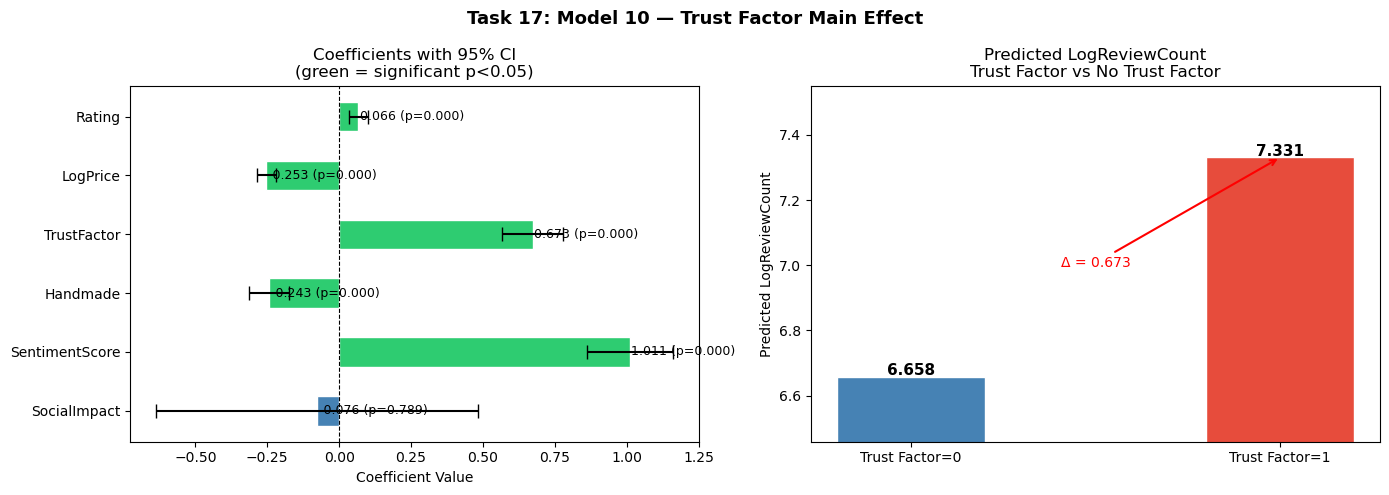

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression/model10_results.png


In [124]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 17: Model 10 — Trust Factor Main Effect',
             fontsize=13, fontweight='bold')

# Plot 1: Coefficient plot
key_vars10 = ['SocialImpact', 'SentimentScore', 'Handmade',
              'trust_factor',
              'LogPrice_winsorized_std', 'average_rating_std']
coefs10    = model10.params[key_vars10]
cis10      = model10.conf_int().loc[key_vars10]
colors10   = ['#2ecc71' if model10.pvalues[v] < 0.05 else 'steelblue'
              for v in key_vars10]
labels10   = ['SocialImpact', 'SentimentScore', 'Handmade',
              'TrustFactor', 'LogPrice', 'Rating']

axes[0].barh(labels10, coefs10.values,
             xerr=[(coefs10.values - cis10[0].values),
                   (cis10[1].values - coefs10.values)],
             color=colors10, edgecolor='white', height=0.5,
             error_kw=dict(ecolor='black', capsize=5))
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Coefficients with 95% CI\n(green = significant p<0.05)')
axes[0].set_xlabel('Coefficient Value')
for i, v in enumerate(key_vars10):
    coef = model10.params[v]
    p    = model10.pvalues[v]
    axes[0].text(coef + 0.005, i, f'{coef:.3f} (p={p:.3f})',
                 va='center', fontsize=9)

# Plot 2: Predicted LogReviewCount — Trust=0 vs Trust=1
cat_zeros  = {col: 0 for col in cat_dummy_cols}
preds_t    = {}
for t_val in [0, 1]:
    row = {
        'const': 1,
        'SocialImpact': 0,
        'SentimentScore': df['SentimentScore'].mean(),
        'Handmade': 0,
        'trust_factor': t_val,
        'LogPrice_winsorized_std': 0,
        'average_rating_std': 0,
    }
    row.update(cat_zeros)
    x_pred = pd.DataFrame([row])[X10.columns]
    preds_t[t_val] = model10.predict(x_pred)[0]

bars = axes[1].bar(
    ['Trust Factor=0', 'Trust Factor=1'],
    [preds_t[0], preds_t[1]],
    color=['steelblue', '#e74c3c'],
    edgecolor='white', width=0.4
)
axes[1].set_title('Predicted LogReviewCount\nTrust Factor vs No Trust Factor')
axes[1].set_ylabel('Predicted LogReviewCount')
axes[1].set_ylim(min(preds_t.values()) * 0.97,
                 max(preds_t.values()) * 1.03)
for bar, val in zip(bars, preds_t.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

diff = preds_t[1] - preds_t[0]
axes[1].annotate(
    f'Δ = {diff:.3f}',
    xy=(1, preds_t[1]),
    xytext=(0.5, (preds_t[0] + preds_t[1]) / 2),
    fontsize=10, ha='center', color='red',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5)
)

plt.tight_layout()
plt.savefig(f'{VIZ5}/model10_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ5}/model10_results.png")

In [125]:
with open(f'{OUTPUTS}/model10_summary.txt', 'w') as f:
    f.write(model10.summary().as_text())
print(f"Saved: {OUTPUTS}/model10_summary.txt")
print(f"\n✓ Task 17 Complete — Model 10 fitted")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/outputs/model10_summary.txt

✓ Task 17 Complete — Model 10 fitted


### Task 18 - Trust Factor Moderation Model

In [126]:
df = pd.read_csv(f'{MOD}/etsy_regression.csv')
print(f"Loaded: {df.shape[0]:,} rows")

cat_dummy_cols = [c for c in df.columns if c.startswith('cat_')]
y = df['LogReviewCount']

def prep_X(X):
    bool_cols = X.select_dtypes(include='bool').columns.tolist()
    X[bool_cols] = X[bool_cols].astype(int)
    return sm.add_constant(X)


Loaded: 10,406 rows


In [127]:
X11_cols = (
    ['SocialImpact_c'] +
    ['SentimentScore_c'] +
    ['Handmade_c'] +
    ['trust_factor_c'] +                    # mean-centered
    ['TrustFactor_x_Sentiment_c'] +         # interaction term
    ['LogPrice_winsorized_std'] +
    ['average_rating_std'] +
    cat_dummy_cols
)

X11 = prep_X(df[X11_cols].copy())
model11 = sm.OLS(y, X11).fit()

print("\n" + "="*60)
print(model11.summary())


                            OLS Regression Results                            
Dep. Variable:         LogReviewCount   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     80.68
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          4.82e-278
Time:                        22:55:40   Log-Likelihood:                -20170.
No. Observations:               10406   AIC:                         4.038e+04
Df Residuals:                   10387   BIC:                         4.052e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const        

In [128]:
print(f"\n{'='*55}")
print("VIF Check — Model 11")
print(f"{'='*55}")
X11_vif  = X11.drop(columns=['const'])
vif_data = pd.DataFrame({
    'Variable': X11_vif.columns,
    'VIF': [variance_inflation_factor(X11_vif.values, i)
            for i in range(X11_vif.shape[1])]
}).sort_values('VIF', ascending=False)
for _, row in vif_data.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Variable']:<35} {row['VIF']:>8.3f}{flag}")


VIF Check — Model 11
  TrustFactor_x_Sentiment_c              3.223 ✓
  SentimentScore_c                       1.983 ✓
  trust_factor_c                         1.911 ✓
  cat_Electronics & Accessories          1.704 ✓
  LogPrice_winsorized_std                1.069 ✓
  Handmade_c                             1.055 ✓
  cat_Shoes                              1.050 ✓
  cat_Art & Collectibles                 1.047 ✓
  cat_Accessories                        1.025 ✓
  average_rating_std                     1.012 ✓
  cat_Pet Supplies                       1.011 ✓
  SocialImpact_c                         1.008 ✓
  cat_Toys & Games                       1.004 ✓
  cat_Bath & Beauty                      1.004 ✓
  cat_Paper & Party Supplies             1.004 ✓
  cat_Jewellery                          1.002 ✓
  cat_Clothing                           1.001 ✓
  cat_Home & Living                      1.001 ✓


In [129]:
print(f"\n{'='*55}")
print("Model 11 — Key Results (Trust Factor Moderation)")
print(f"{'='*55}")
print(f"  R²:          {model11.rsquared:.4f}")
print(f"  Adj. R²:     {model11.rsquared_adj:.4f}")
print(f"  N:           {int(model11.nobs):,}")

for var, label in [
    ('SocialImpact_c',           'SocialImpact (β₁)'),
    ('SentimentScore_c',         'SentimentScore (β₂)'),
    ('Handmade_c',               'Handmade (β₃)'),
    ('trust_factor_c',           'TrustFactor (β₄)'),
    ('TrustFactor_x_Sentiment_c','TrustFactor × Sentiment (β₅) — KEY'),
]:
    coef = model11.params[var]
    se   = model11.bse[var]
    p    = model11.pvalues[var]
    ci   = model11.conf_int().loc[var]
    sig  = '✓ Significant' if p < 0.05 else '✗ Not significant'
    print(f"\n  {label}:")
    print(f"    Coefficient: {coef:>8.4f}")
    print(f"    Std Error:   {se:>8.4f}")
    print(f"    p-value:     {p:>8.4f}  {sig}")
    print(f"    95% CI:      [{ci[0]:.4f}, {ci[1]:.4f}]")
    if var == 'TrustFactor_x_Sentiment_c':
        direction = 'STRENGTHENS' if coef > 0 else 'DAMPENS'
        print(f"    → Sentiment {direction} the trust factor effect")

r2_m10    = 0.1226
r2_change = model11.rsquared - r2_m10
print(f"\n  R² change from Model 10: {r2_change:+.4f}")


Model 11 — Key Results (Trust Factor Moderation)
  R²:          0.1227
  Adj. R²:     0.1211
  N:           10,406

  SocialImpact (β₁):
    Coefficient:  -0.0860
    Std Error:     0.2860
    p-value:       0.7635  ✗ Not significant
    95% CI:      [-0.6466, 0.4746]

  SentimentScore (β₂):
    Coefficient:   1.0782
    Std Error:     0.1082
    p-value:       0.0000  ✓ Significant
    95% CI:      [0.8661, 1.2903]

  Handmade (β₃):
    Coefficient:  -0.2446
    Std Error:     0.0355
    p-value:       0.0000  ✓ Significant
    95% CI:      [-0.3142, -0.1751]

  TrustFactor (β₄):
    Coefficient:   0.6269
    Std Error:     0.0748
    p-value:       0.0000  ✓ Significant
    95% CI:      [0.4802, 0.7735]

  TrustFactor × Sentiment (β₅) — KEY:
    Coefficient:   0.6865
    Std Error:     0.7737
    p-value:       0.3750  ✗ Not significant
    95% CI:      [-0.8301, 2.2031]
    → Sentiment STRENGTHENS the trust factor effect

  R² change from Model 10: +0.0001


In [130]:
# =============================================================================
# Moderation Plot
# =============================================================================
sentiment_levels = {
    'Low\n(-1 SD)':  df['SentimentScore'].mean() - df['SentimentScore'].std(),
    'Mean':          df['SentimentScore'].mean(),
    'High\n(+1 SD)': df['SentimentScore'].mean() + df['SentimentScore'].std(),
}
cat_zeros   = {col: 0 for col in cat_dummy_cols}
predictions = {}

for sent_label, sent_val in sentiment_levels.items():
    preds = {}
    for t_val in [0, 1]:
        si_c   = 0
        hm_c   = 0
        sent_c = sent_val - df['SentimentScore'].mean()
        t_c    = t_val    - df['trust_factor'].mean()
        row = {
            'const': 1,
            'SocialImpact_c': si_c,
            'SentimentScore_c': sent_c,
            'Handmade_c': hm_c,
            'trust_factor_c': t_c,
            'TrustFactor_x_Sentiment_c': t_c * sent_c,
            'LogPrice_winsorized_std': 0,
            'average_rating_std': 0,
        }
        row.update(cat_zeros)
        x_pred = pd.DataFrame([row])[X11.columns]
        preds[t_val] = model11.predict(x_pred)[0]
    predictions[sent_label] = preds

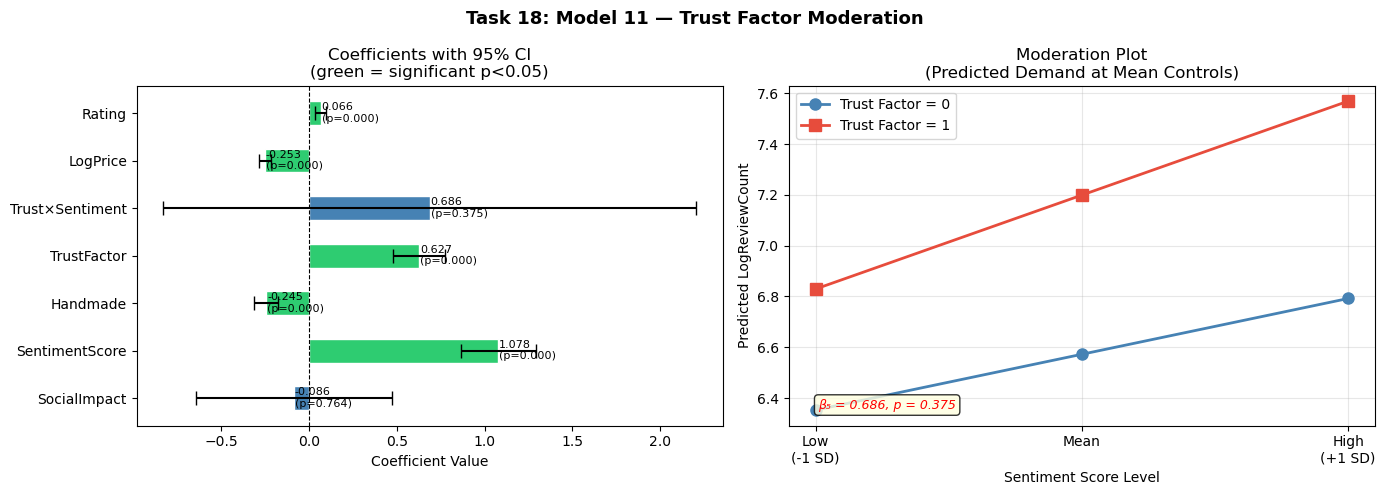

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression/model11_results.png


In [131]:
# =============================================================================
# Visualization — 2 subplots
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 18: Model 11 — Trust Factor Moderation',
             fontsize=13, fontweight='bold')

# Plot 1: Coefficient plot
key_vars11 = ['SocialImpact_c', 'SentimentScore_c', 'Handmade_c',
              'trust_factor_c', 'TrustFactor_x_Sentiment_c',
              'LogPrice_winsorized_std', 'average_rating_std']
coefs11    = model11.params[key_vars11]
cis11      = model11.conf_int().loc[key_vars11]
colors11   = ['#2ecc71' if model11.pvalues[v] < 0.05 else 'steelblue'
              for v in key_vars11]
labels11   = ['SocialImpact', 'SentimentScore', 'Handmade',
              'TrustFactor', 'Trust×Sentiment', 'LogPrice', 'Rating']

axes[0].barh(labels11, coefs11.values,
             xerr=[(coefs11.values - cis11[0].values),
                   (cis11[1].values - coefs11.values)],
             color=colors11, edgecolor='white', height=0.5,
             error_kw=dict(ecolor='black', capsize=5))
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Coefficients with 95% CI\n(green = significant p<0.05)')
axes[0].set_xlabel('Coefficient Value')
for i, v in enumerate(key_vars11):
    coef = model11.params[v]
    p    = model11.pvalues[v]
    axes[0].text(coef + 0.005, i, f'{coef:.3f}\n(p={p:.3f})',
                 va='center', fontsize=8)

# Plot 2: Moderation plot
sent_labels_plot = list(sentiment_levels.keys())
t0_vals  = [predictions[l][0] for l in sent_labels_plot]
t1_vals  = [predictions[l][1] for l in sent_labels_plot]
x        = np.arange(len(sent_labels_plot))

axes[1].plot(x, t0_vals, 'o-', color='steelblue', linewidth=2,
             markersize=8, label='Trust Factor = 0')
axes[1].plot(x, t1_vals, 's-', color='#e74c3c', linewidth=2,
             markersize=8, label='Trust Factor = 1')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sent_labels_plot)
axes[1].set_xlabel('Sentiment Score Level')
axes[1].set_ylabel('Predicted LogReviewCount')
axes[1].set_title('Moderation Plot\n(Predicted Demand at Mean Controls)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

int_p    = model11.pvalues['TrustFactor_x_Sentiment_c']
sig_text = f'β₅ = {model11.params["TrustFactor_x_Sentiment_c"]:.3f}, p = {int_p:.3f}'
style    = 'normal' if int_p < 0.05 else 'italic'
color    = '#2ecc71' if int_p < 0.05 else 'red'
axes[1].text(0.05, 0.05, sig_text,
             transform=axes[1].transAxes, fontsize=9,
             color=color, style=style,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{VIZ5}/model11_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ5}/model11_results.png")

In [132]:
with open(f'{OUTPUTS}/model11_summary.txt', 'w') as f:
    f.write(model11.summary().as_text())
print(f"Saved: {OUTPUTS}/model11_summary.txt")
print(f"\n✓ Task 18 Complete — Model 11 fitted")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/outputs/model11_summary.txt

✓ Task 18 Complete — Model 11 fitted


### Task 19 - Comparisons

In [133]:
df = pd.read_csv(f'{MOD}/etsy_regression.csv')
cat_dummy_cols = [c for c in df.columns if c.startswith('cat_')]
y  = df['LogReviewCount']

def prep_X(X):
    bool_cols = X.select_dtypes(include='bool').columns.tolist()
    X[bool_cols] = X[bool_cols].astype(int)
    return sm.add_constant(X)

In [134]:
# =============================================================================
# Rebuild all 11 models
# =============================================================================
# Model 1 — Baseline
X1 = prep_X(df[['SocialImpact', 'LogPrice_winsorized_std',
                  'average_rating_std'] + cat_dummy_cols].copy())
model1 = sm.OLS(y, X1).fit()

# Model 2 — Sentiment
X2 = prep_X(df[['SocialImpact', 'SentimentScore',
                  'LogPrice_winsorized_std',
                  'average_rating_std'] + cat_dummy_cols].copy())
model2 = sm.OLS(y, X2).fit()

# Model 3 — SI Moderation
X3 = prep_X(df[['SocialImpact_c', 'SentimentScore_c',
                  'SocialImpact_x_Sentiment_c',
                  'LogPrice_winsorized_std',
                  'average_rating_std'] + cat_dummy_cols].copy())
model3 = sm.OLS(y, X3).fit()

# Model 4 — Handmade
X4 = prep_X(df[['SocialImpact', 'SentimentScore', 'Handmade',
                  'LogPrice_winsorized_std',
                  'average_rating_std'] + cat_dummy_cols].copy())
model4 = sm.OLS(y, X4).fit()

# Model 5 — HM Moderation
X5 = prep_X(df[['SocialImpact_c', 'SentimentScore_c', 'Handmade_c',
                  'SocialImpact_x_Sentiment_c',
                  'Handmade_x_Sentiment_c',
                  'LogPrice_winsorized_std',
                  'average_rating_std'] + cat_dummy_cols].copy())
model5 = sm.OLS(y, X5).fit()

# Model 6 — Lexical Diversity
X6 = prep_X(df[['SocialImpact', 'SentimentScore', 'Handmade',
                  'lexical_diversity_std',
                  'LogPrice_winsorized_std',
                  'average_rating_std'] + cat_dummy_cols].copy())
model6 = sm.OLS(y, X6).fit()

# Model 7 — LexDiv Moderation
X7 = prep_X(df[['SocialImpact_c', 'SentimentScore_c', 'Handmade_c',
                  'lexical_diversity_c', 'LexDiv_x_Sentiment_c',
                  'LogPrice_winsorized_std',
                  'average_rating_std'] + cat_dummy_cols].copy())
model7 = sm.OLS(y, X7).fit()

# Model 8 — Personalization
X8 = prep_X(df[['SocialImpact', 'SentimentScore', 'Handmade',
                  'personalization',
                  'LogPrice_winsorized_std',
                  'average_rating_std'] + cat_dummy_cols].copy())
model8 = sm.OLS(y, X8).fit()

# Model 9 — Personalization Moderation
X9 = prep_X(df[['SocialImpact_c', 'SentimentScore_c', 'Handmade_c',
                  'personalization_c', 'Personalization_x_Sentiment_c',
                  'LogPrice_winsorized_std',
                  'average_rating_std'] + cat_dummy_cols].copy())
model9 = sm.OLS(y, X9).fit()

# Model 10 — Trust Factor
X10 = prep_X(df[['SocialImpact', 'SentimentScore', 'Handmade',
                   'trust_factor',
                   'LogPrice_winsorized_std',
                   'average_rating_std'] + cat_dummy_cols].copy())
model10 = sm.OLS(y, X10).fit()

# Model 11 — Trust Moderation
X11 = prep_X(df[['SocialImpact_c', 'SentimentScore_c', 'Handmade_c',
                   'trust_factor_c', 'TrustFactor_x_Sentiment_c',
                   'LogPrice_winsorized_std',
                   'average_rating_std'] + cat_dummy_cols].copy())
model11 = sm.OLS(y, X11).fit()

all_models = [model1, model2, model3, model4, model5,
              model6, model7, model8, model9, model10, model11]
model_names = [
    'M1\nBaseline',
    'M2\nSentiment',
    'M3\nSI Mod.',
    'M4\nHandmade',
    'M5\nHM Mod.',
    'M6\nLexDiv',
    'M7\nLexDiv Mod.',
    'M8\nPersonal.',
    'M9\nPersonal. Mod.',
    'M10\nTrust',
    'M11\nTrust Mod.',
]

print("✓ All 11 models rebuilt")


✓ All 11 models rebuilt


In [135]:
def stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    return ''

def fmt(coef, se, p):
    return f"{coef:.3f}{stars(p)}\n({se:.3f})"

def get(model, var):
    if var in model.params:
        return fmt(model.params[var], model.bse[var], model.pvalues[var])
    return '—'

si_vars   = ['SocialImpact', 'SocialImpact', 'SocialImpact_c',
             'SocialImpact', 'SocialImpact_c', 'SocialImpact',
             'SocialImpact_c', 'SocialImpact', 'SocialImpact_c',
             'SocialImpact', 'SocialImpact_c']
sent_vars = ['—', 'SentimentScore', 'SentimentScore_c',
             'SentimentScore', 'SentimentScore_c', 'SentimentScore',
             'SentimentScore_c', 'SentimentScore', 'SentimentScore_c',
             'SentimentScore', 'SentimentScore_c']
hm_vars   = ['—', '—', '—',
             'Handmade', 'Handmade_c', 'Handmade',
             'Handmade_c', 'Handmade', 'Handmade_c',
             'Handmade', 'Handmade_c']

rows = {
    'SocialImpact (β₁)': [
        get(m, v) for m, v in zip(all_models, si_vars)],
    'SentimentScore (β₂)': [
        get(m, v) if v != '—' else '—'
        for m, v in zip(all_models, sent_vars)],
    'Handmade (β₃)': [
        get(m, v) if v != '—' else '—'
        for m, v in zip(all_models, hm_vars)],
    'LexicalDiversity (β)': [
        '—','—','—','—','—',
        get(model6, 'lexical_diversity_std'),
        get(model7, 'lexical_diversity_c'),
        '—','—','—','—'],
    'Personalization (β)': [
        '—','—','—','—','—','—','—',
        get(model8, 'personalization'),
        get(model9, 'personalization_c'),
        '—','—'],
    'TrustFactor (β)': [
        '—','—','—','—','—','—','—','—','—',
        get(model10, 'trust_factor'),
        get(model11, 'trust_factor_c')],
    'SI×Sentiment': [
        '—','—',
        get(model3, 'SocialImpact_x_Sentiment_c'),
        '—',
        get(model5, 'SocialImpact_x_Sentiment_c'),
        '—','—','—','—','—',
        '—'],
    'HM×Sentiment': [
        '—','—','—','—',
        get(model5, 'Handmade_x_Sentiment_c'),
        '—','—','—','—','—','—'],
    'LexDiv×Sentiment': [
        '—','—','—','—','—','—',
        get(model7, 'LexDiv_x_Sentiment_c'),
        '—','—','—','—'],
    'Personal×Sentiment': [
        '—','—','—','—','—','—','—','—',
        get(model9, 'Personalization_x_Sentiment_c'),
        '—','—'],
    'Trust×Sentiment': [
        '—','—','—','—','—','—','—','—','—','—',
        get(model11, 'TrustFactor_x_Sentiment_c')],
    'LogPrice (β)': [
        get(m, 'LogPrice_winsorized_std') for m in all_models],
    'Rating (β)': [
        get(m, 'average_rating_std') for m in all_models],
    'Category Dummies': ['Yes'] * 11,
    'N':       [f"{int(m.nobs):,}" for m in all_models],
    'R²':      [f"{m.rsquared:.4f}" for m in all_models],
    'Adj. R²': [f"{m.rsquared_adj:.4f}" for m in all_models],
    'F-stat':  [f"{m.fvalue:.2f}***" for m in all_models],
}

table = pd.DataFrame(rows, index=model_names).T

print(f"\n{'='*120}")
print("FULL REGRESSION TABLE — ALL 11 MODELS")
print(f"{'='*120}")
print("Coefficients with standard errors in parentheses")
print("Significance: * p<0.05  ** p<0.01  *** p<0.001")
print(f"{'='*120}")
print(table.to_string())

table.to_csv(f'{OUTPUTS}/regression_table_all.csv')
print(f"\nSaved: {OUTPUTS}/regression_table_all.csv")


FULL REGRESSION TABLE — ALL 11 MODELS
Coefficients with standard errors in parentheses
Significance: * p<0.05  ** p<0.01  *** p<0.001
                            M1\nBaseline       M2\nSentiment         M3\nSI Mod.        M4\nHandmade         M5\nHM Mod.          M6\nLexDiv     M7\nLexDiv Mod.       M8\nPersonal.  M9\nPersonal. Mod.          M10\nTrust     M11\nTrust Mod.
SocialImpact (β₁)         0.220\n(0.290)      0.176\n(0.288)      0.186\n(0.302)      0.154\n(0.287)      0.162\n(0.302)      0.045\n(0.282)      0.046\n(0.282)      0.158\n(0.287)      0.158\n(0.287)     -0.076\n(0.286)     -0.086\n(0.286)
SentimentScore (β₂)                    —   1.055***\n(0.077)   1.055***\n(0.077)   1.112***\n(0.077)   1.091***\n(0.081)   0.535***\n(0.082)   0.590***\n(0.096)   1.055***\n(0.078)   1.055***\n(0.086)   1.011***\n(0.077)   1.078***\n(0.108)
Handmade (β₃)                          —                   —                   —  -0.235***\n(0.036)  -0.231***\n(0.036)  -0.283***\n(0.035)  

In [143]:
# =============================================================================
# Regression Table — Clean Display
# =============================================================================

import pandas as pd
from IPython.display import display

df_table = pd.read_csv(f'{OUTPUTS}/regression_table_all.csv', index_col=0)

# Rename columns to shorter names
df_table.columns = [
    'M1\nBaseline',
    'M2\nSentiment',
    'M3\nSI Mod.',
    'M4\nHandmade',
    'M5\nHM Mod.',
    'M6\nLexDiv',
    'M7\nLexDiv Mod.',
    'M8\nPersonal.',
    'M9\nPersonal. Mod.',
    'M10\nTrust',
    'M11\nTrust Mod.',
]

# =============================================================================
# Styling function
# =============================================================================
def style_table(df):

    def color_cell(val):
        if not isinstance(val, str) or val == '—':
            return 'color: lightgrey'
        if '***' in val:
            return 'color: #1a5276; font-weight: bold'
        elif '**' in val:
            return 'color: #1e8449; font-weight: bold'
        elif '*' in val:
            return 'color: #b7770d; font-weight: bold'
        elif val in ['Yes', 'No']:
            return 'color: #555'
        else:
            return 'color: #888'

    def highlight_rows(row):
        stat_rows = ['N', 'R²', 'Adj. R²', 'F-stat', 'Category Dummies']
        if row.name in stat_rows:
            return ['background-color: #eaf2fb; font-weight: bold'] * len(row)
        return [''] * len(row)

    def highlight_best_r2(row):
        if row.name == 'R²':
            vals    = row.astype(float)
            max_col = vals.idxmax()
            return [
                'background-color: #d4efdf; font-weight: bold'
                if col == max_col else ''
                for col in row.index
            ]
        return [''] * len(row)

    styled = (
        df.style
        .applymap(color_cell)
        .apply(highlight_rows, axis=1)
        .apply(highlight_best_r2, axis=1)
        .set_properties(**{
            'text-align': 'center',
            'font-size':  '11px',
            'padding':    '5px 8px',
            'white-space':'pre-wrap',
            'border':     '0.5px solid #ddd',
        })
        .set_properties(subset=df.columns[:0],
                        **{'text-align': 'left'})
        .set_table_styles([
            # Table overall
            {'selector': 'table',
             'props': [('border-collapse', 'collapse'),
                       ('width',           '100%'),
                       ('font-family',     'monospace'),
                       ('font-size',       '11px')]},
            # Header
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'),
                       ('color',            'white'),
                       ('font-size',        '10px'),
                       ('padding',          '7px 8px'),
                       ('text-align',       'center'),
                       ('white-space',      'pre-wrap'),
                       ('border',           '0.5px solid #555')]},
            # Index column
            {'selector': 'th.row_heading',
             'props': [('text-align',       'left'),
                       ('font-style',       'italic'),
                       ('font-size',        '11px'),
                       ('background-color', '#f4f6f7'),
                       ('color',            '#333'),
                       ('min-width',        '170px'),
                       ('padding',          '5px 10px')]},
            # Row hover
            {'selector': 'tr:hover td',
             'props': [('background-color', '#fdfdf0')]},
            # Caption
            {'selector': 'caption',
             'props': [('caption-side',     'top'),
                       ('font-size',        '13px'),
                       ('font-weight',      'bold'),
                       ('color',            '#2c3e50'),
                       ('padding-bottom',   '10px'),
                       ('text-align',       'left')]},
        ])
        .set_caption(
            "Regression Results — All 11 Models  |  "
            "DV: LogReviewCount  |  N = 10,406  |  "
            "*** p<0.001  ** p<0.01  * p<0.05  |  "
            "Standard errors in parentheses  |  "
            "Green highlight = best R²"
        )
    )

    return styled

# Display
styled_table = style_table(df_table)
display(styled_table)

/var/folders/xn/nzvbrvgs02b1h2n4dc33hsx40000gn/T/ipykernel_1845/3156958957.py:63: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_cell)


,M1 Baseline,M2 Sentiment,M3 SI Mod.,M4 Handmade,M5 HM Mod.,M6 LexDiv,M7 LexDiv Mod.,M8 Personal.,M9 Personal. Mod.,M10 Trust,M11 Trust Mod.
SocialImpact (β₁),0.220 (0.290),0.176 (0.288),0.186 (0.302),0.154 (0.287),0.162 (0.302),0.045 (0.282),0.046 (0.282),0.158 (0.287),0.158 (0.287),-0.076 (0.286),-0.086 (0.286)
SentimentScore (β₂),—,1.055*** (0.077),1.055*** (0.077),1.112*** (0.077),1.091*** (0.081),0.535*** (0.082),0.590*** (0.096),1.055*** (0.078),1.055*** (0.086),1.011*** (0.077),1.078*** (0.108)
Handmade (β₃),—,—,—,-0.235*** (0.036),-0.231*** (0.036),-0.283*** (0.035),-0.284*** (0.035),-0.255*** (0.036),-0.255*** (0.036),-0.243*** (0.035),-0.245*** (0.035)
LexicalDiversity (β),—,—,—,—,—,-0.342*** (0.018),-2.957*** (0.155),—,—,—,—
Personalization (β),—,—,—,—,—,—,—,0.201*** (0.036),0.201*** (0.036),—,—
TrustFactor (β),—,—,—,—,—,—,—,—,—,0.673*** (0.054),0.627*** (0.075)
SI×Sentiment,—,—,-0.214 (1.954),—,-0.165 (1.951),—,—,—,—,—,—
HM×Sentiment,—,—,—,—,-0.158 (0.185),—,—,—,—,—,—
LexDiv×Sentiment,—,—,—,—,—,—,-0.583 (0.546),—,—,—,—
Personal×Sentiment,—,—,—,—,—,—,—,—,-0.000 (0.203),—,—


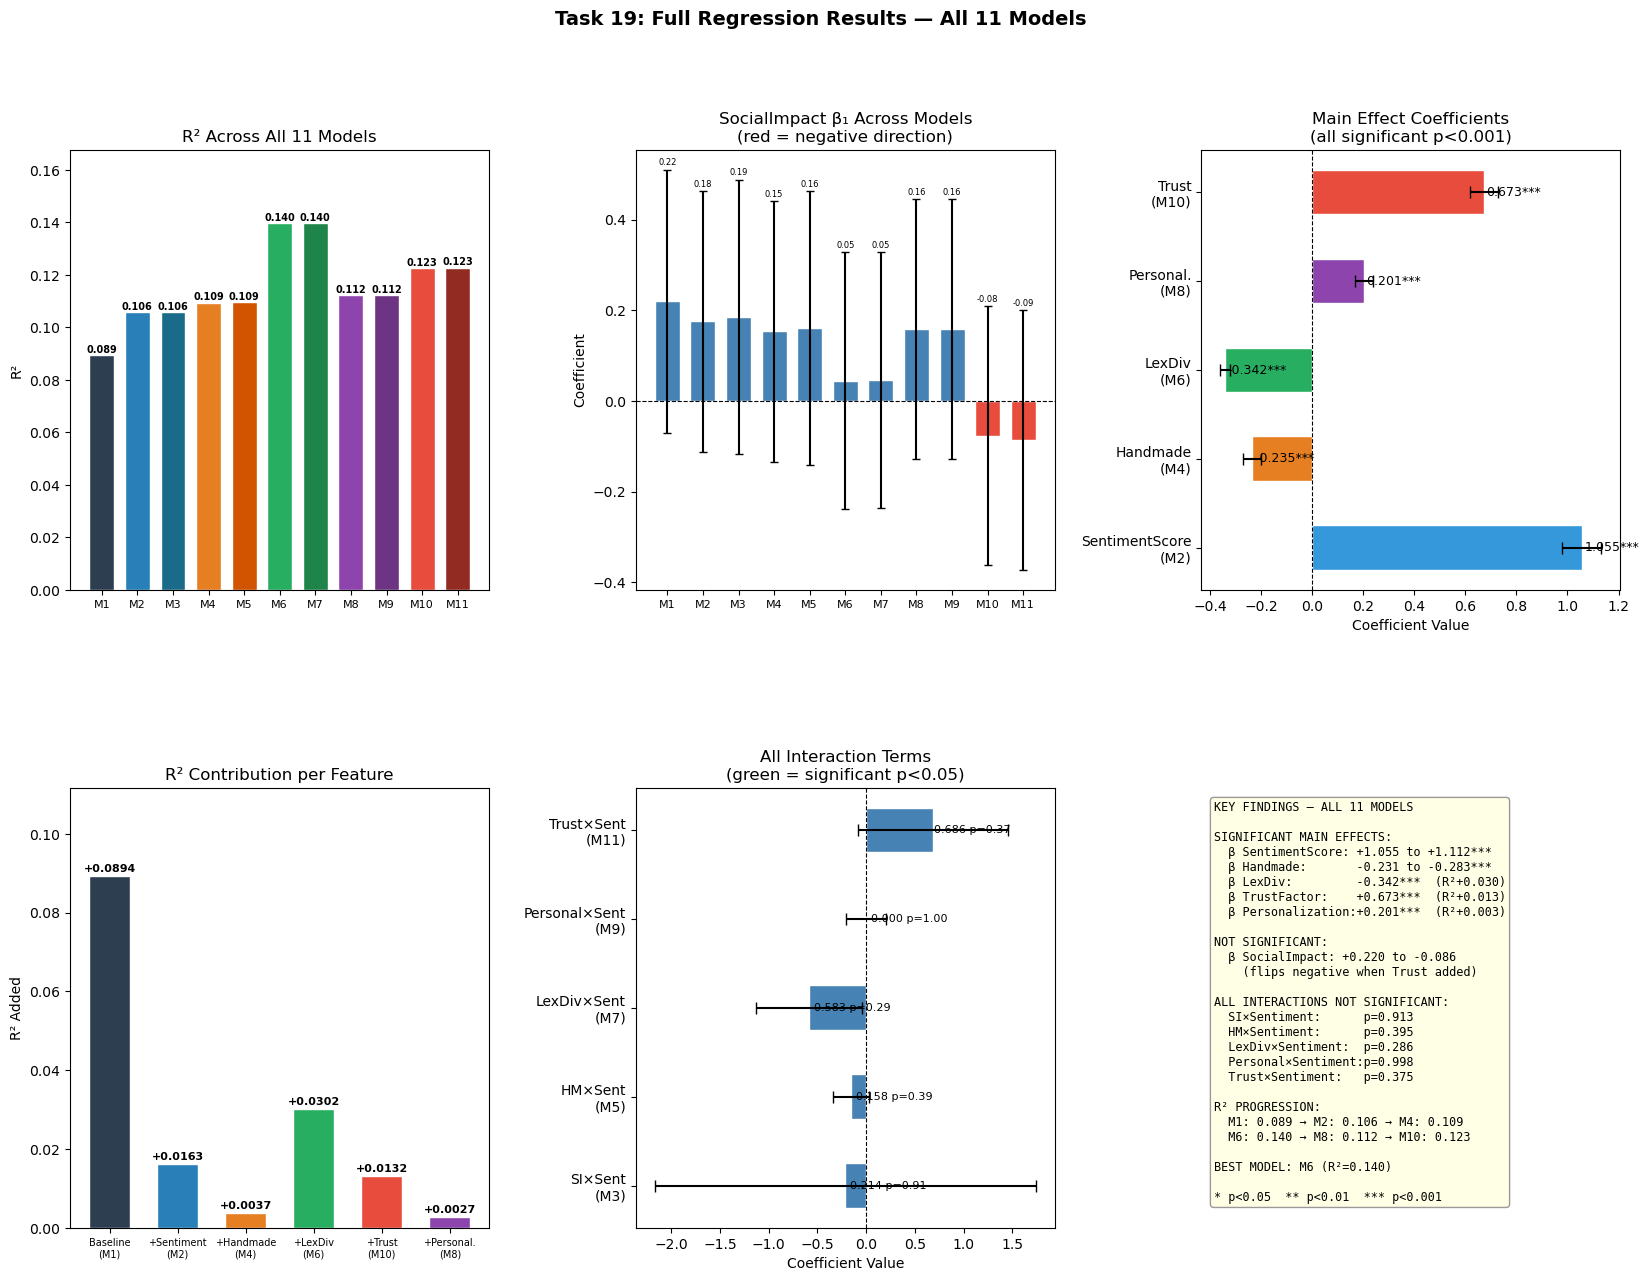

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression/model_comparison_all.png


In [136]:
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Task 19: Full Regression Results — All 11 Models',
             fontsize=14, fontweight='bold')

bar_colors = ['#2c3e50', '#2980b9', '#1a6b8a',
              '#e67e22', '#d35400',
              '#27ae60', '#1e8449',
              '#8e44ad', '#6c3483',
              '#e74c3c', '#922b21']

# Plot 1: R² progression
ax1  = fig.add_subplot(gs[0, 0])
r2s  = [m.rsquared for m in all_models]
bars = ax1.bar(range(11), r2s, color=bar_colors, edgecolor='white', width=0.7)
ax1.set_xticks(range(11))
ax1.set_xticklabels([f'M{i+1}' for i in range(11)], fontsize=8)
ax1.set_title('R² Across All 11 Models')
ax1.set_ylabel('R²')
ax1.set_ylim(0, max(r2s) * 1.2)
for bar, val in zip(bars, r2s):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{val:.3f}', ha='center', fontsize=7, fontweight='bold')

# Plot 2: SocialImpact β₁ across all models
ax2      = fig.add_subplot(gs[0, 1])
si_coefs = [m.params[v] for m, v in zip(all_models, si_vars)]
si_ses   = [m.bse[v]    for m, v in zip(all_models, si_vars)]
si_ps    = [m.pvalues[v] for m, v in zip(all_models, si_vars)]
colors_si = ['#2ecc71' if p < 0.05 else '#e74c3c' if c < 0 else 'steelblue'
             for c, p in zip(si_coefs, si_ps)]
ax2.bar(range(11), si_coefs, yerr=si_ses, color=colors_si,
        edgecolor='white', width=0.7, capsize=3,
        error_kw=dict(ecolor='black'))
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(range(11))
ax2.set_xticklabels([f'M{i+1}' for i in range(11)], fontsize=8)
ax2.set_title('SocialImpact β₁ Across Models\n(red = negative direction)')
ax2.set_ylabel('Coefficient')
for i, (v, p) in enumerate(zip(si_coefs, si_ps)):
    ax2.text(i, v + si_ses[i] + 0.01,
             f'{v:.2f}', ha='center', fontsize=6)

# Plot 3: Main effect coefficients comparison
ax3 = fig.add_subplot(gs[0, 2])
features      = ['SentimentScore\n(M2)', 'Handmade\n(M4)',
                 'LexDiv\n(M6)', 'Personal.\n(M8)', 'Trust\n(M10)']
main_coefs    = [
    model2.params['SentimentScore'],
    model4.params['Handmade'],
    model6.params['lexical_diversity_std'],
    model8.params['personalization'],
    model10.params['trust_factor'],
]
main_ses      = [
    model2.bse['SentimentScore'],
    model4.bse['Handmade'],
    model6.bse['lexical_diversity_std'],
    model8.bse['personalization'],
    model10.bse['trust_factor'],
]
feat_colors   = ['#3498db', '#e67e22', '#27ae60', '#8e44ad', '#e74c3c']
ax3.barh(features, main_coefs,
         xerr=main_ses, color=feat_colors,
         edgecolor='white', height=0.5,
         error_kw=dict(ecolor='black', capsize=4))
ax3.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax3.set_title('Main Effect Coefficients\n(all significant p<0.001)')
ax3.set_xlabel('Coefficient Value')
for i, v in enumerate(main_coefs):
    ax3.text(v + 0.01, i, f'{v:.3f}***', va='center', fontsize=9)

# Plot 4: R² contributions
ax4 = fig.add_subplot(gs[1, 0])
r2_baseline  = model1.rsquared
r2_additions = {
    'Baseline\n(M1)':     r2_baseline,
    '+Sentiment\n(M2)':   model2.rsquared - model1.rsquared,
    '+Handmade\n(M4)':    model4.rsquared - model2.rsquared,
    '+LexDiv\n(M6)':      model6.rsquared - model4.rsquared,
    '+Trust\n(M10)':      model10.rsquared - model4.rsquared,
    '+Personal.\n(M8)':   model8.rsquared - model4.rsquared,
}
add_colors = ['#2c3e50', '#2980b9', '#e67e22',
              '#27ae60', '#e74c3c', '#8e44ad']
bars4 = ax4.bar(r2_additions.keys(), r2_additions.values(),
                color=add_colors, edgecolor='white', width=0.6)
ax4.set_title('R² Contribution per Feature')
ax4.set_ylabel('R² Added')
ax4.set_ylim(0, max(r2_additions.values()) * 1.25)
for bar, val in zip(bars4, r2_additions.values()):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'+{val:.4f}', ha='center', fontsize=8, fontweight='bold')
plt.setp(ax4.get_xticklabels(), fontsize=7)

# Plot 5: Moderation effects — all 5 interaction terms
ax5 = fig.add_subplot(gs[1, 1])
int_labels = ['SI×Sent\n(M3)', 'HM×Sent\n(M5)',
              'LexDiv×Sent\n(M7)', 'Personal×Sent\n(M9)',
              'Trust×Sent\n(M11)']
int_coefs  = [
    model3.params['SocialImpact_x_Sentiment_c'],
    model5.params['Handmade_x_Sentiment_c'],
    model7.params['LexDiv_x_Sentiment_c'],
    model9.params['Personalization_x_Sentiment_c'],
    model11.params['TrustFactor_x_Sentiment_c'],
]
int_ses    = [
    model3.bse['SocialImpact_x_Sentiment_c'],
    model5.bse['Handmade_x_Sentiment_c'],
    model7.bse['LexDiv_x_Sentiment_c'],
    model9.bse['Personalization_x_Sentiment_c'],
    model11.bse['TrustFactor_x_Sentiment_c'],
]
int_ps     = [
    model3.pvalues['SocialImpact_x_Sentiment_c'],
    model5.pvalues['Handmade_x_Sentiment_c'],
    model7.pvalues['LexDiv_x_Sentiment_c'],
    model9.pvalues['Personalization_x_Sentiment_c'],
    model11.pvalues['TrustFactor_x_Sentiment_c'],
]
int_colors = ['#2ecc71' if p < 0.05 else 'steelblue' for p in int_ps]
ax5.barh(int_labels, int_coefs,
         xerr=int_ses, color=int_colors,
         edgecolor='white', height=0.5,
         error_kw=dict(ecolor='black', capsize=4))
ax5.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax5.set_title('All Interaction Terms\n(green = significant p<0.05)')
ax5.set_xlabel('Coefficient Value')
for i, (v, p) in enumerate(zip(int_coefs, int_ps)):
    sig = stars(p) if p < 0.05 else f'p={p:.2f}'
    ax5.text(v + 0.01, i, f'{v:.3f} {sig}', va='center', fontsize=8)

# Plot 6: Key findings summary
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
findings = [
    "KEY FINDINGS — ALL 11 MODELS",
    "",
    "SIGNIFICANT MAIN EFFECTS:",
    "  β SentimentScore: +1.055 to +1.112***",
    "  β Handmade:       -0.231 to -0.283***",
    "  β LexDiv:         -0.342***  (R²+0.030)",
    "  β TrustFactor:    +0.673***  (R²+0.013)",
    "  β Personalization:+0.201***  (R²+0.003)",
    "",
    "NOT SIGNIFICANT:",
    "  β SocialImpact: +0.220 to -0.086",
    "    (flips negative when Trust added)",
    "",
    "ALL INTERACTIONS NOT SIGNIFICANT:",
    "  SI×Sentiment:      p=0.913",
    "  HM×Sentiment:      p=0.395",
    "  LexDiv×Sentiment:  p=0.286",
    "  Personal×Sentiment:p=0.998",
    "  Trust×Sentiment:   p=0.375",
    "",
    "R² PROGRESSION:",
    "  M1: 0.089 → M2: 0.106 → M4: 0.109",
    "  M6: 0.140 → M8: 0.112 → M10: 0.123",
    "",
    "BEST MODEL: M6 (R²=0.140)",
    "",
    "* p<0.05  ** p<0.01  *** p<0.001",
]
ax6.text(0.03, 0.97, '\n'.join(findings),
         transform=ax6.transAxes,
         fontsize=8.5, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow',
                   alpha=0.8, edgecolor='gray'))

plt.savefig(f'{VIZ5}/model_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {VIZ5}/model_comparison_all.png")

### Task 20 - Final Model

In [144]:
df = pd.read_csv(f'{MOD}/etsy_regression.csv')
print(f"Loaded: {df.shape[0]:,} rows")

cat_dummy_cols = [c for c in df.columns if c.startswith('cat_')]
y = df['LogReviewCount']

def prep_X(X):
    bool_cols = X.select_dtypes(include='bool').columns.tolist()
    X[bool_cols] = X[bool_cols].astype(int)
    return sm.add_constant(X)

Loaded: 10,406 rows


In [145]:
X_final_cols = (
    ['SocialImpact'] +              # IV — cause marketing
    ['SentimentScore'] +            # Moderator — most robust predictor
    ['Handmade'] +                  # IV — handmade status
    ['lexical_diversity_std'] +     # Linguistic — strongest feature
    ['personalization'] +           # Linguistic — moderate predictor
    ['trust_factor'] +              # Linguistic — second strongest feature
    ['LogPrice_winsorized_std'] +   # Control — price
    ['average_rating_std'] +        # Control — rating
    cat_dummy_cols                  # Control — category
)

X_final = prep_X(df[X_final_cols].copy())
model_final = sm.OLS(y, X_final).fit()

print("\n" + "="*65)
print("FINAL COMPREHENSIVE MODEL — All Significant Predictors")
print("="*65)
print(model_final.summary())



FINAL COMPREHENSIVE MODEL — All Significant Predictors
                            OLS Regression Results                            
Dep. Variable:         LogReviewCount   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     95.06
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:40:01   Log-Likelihood:                -20016.
No. Observations:               10406   AIC:                         4.007e+04
Df Residuals:                   10386   BIC:                         4.022e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

In [146]:
print(f"\n{'='*55}")
print("VIF Check — Final Model")
print(f"{'='*55}")
X_vif    = X_final.drop(columns=['const'])
vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
for _, row in vif_data.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Variable']:<35} {row['VIF']:>8.3f}{flag}")



VIF Check — Final Model
  SentimentScore                         2.753 ✓
  personalization                        1.702 ✓
  Handmade                               1.638 ✓
  cat_Shoes                              1.358 ✓
  trust_factor                           1.166 ✓
  cat_Art & Collectibles                 1.145 ✓
  lexical_diversity_std                  1.097 ✓
  LogPrice_winsorized_std                1.088 ✓
  cat_Accessories                        1.086 ✓
  cat_Pet Supplies                       1.056 ✓
  cat_Toys & Games                       1.038 ✓
  average_rating_std                     1.016 ✓
  cat_Jewellery                          1.011 ✓
  SocialImpact                           1.010 ✓
  cat_Bath & Beauty                      1.009 ✓
  cat_Clothing                           1.009 ✓
  cat_Paper & Party Supplies             1.008 ✓
  cat_Electronics & Accessories          1.002 ✓
  cat_Home & Living                      1.001 ✓


In [147]:
print(f"\n{'='*65}")
print("FINAL MODEL — Key Results")
print(f"{'='*65}")
print(f"  R²:            {model_final.rsquared:.4f}")
print(f"  Adj. R²:       {model_final.rsquared_adj:.4f}")
print(f"  F-statistic:   {model_final.fvalue:.4f}")
print(f"  F p-value:     {model_final.f_pvalue:.6f}")
print(f"  N:             {int(model_final.nobs):,}")

# R² comparison across key models
print(f"\n  R² Progression:")
print(f"  {'Model':<35} {'R²':>8} {'Change':>10}")
print(f"  {'-'*55}")
prev_models = [
    ('Model 1  — Baseline',       0.0894, 0.0000),
    ('Model 2  — + Sentiment',    0.1057, 0.0163),
    ('Model 4  — + Handmade',     0.1094, 0.0037),
    ('Model 6  — + LexDiv',       0.1396, 0.0302),
    ('Model 8  — + Personal.',    0.1121, 0.0027),
    ('Model 10 — + Trust',        0.1226, 0.0132),
    ('Model 20 — All Combined',
     model_final.rsquared,
     model_final.rsquared - 0.1094),
]
for name, r2, change in prev_models:
    marker = ' ◀ BEST' if name.startswith('Model 20') else ''
    print(f"  {name:<35} {r2:>8.4f} {change:>+10.4f}{marker}")


FINAL MODEL — Key Results
  R²:            0.1481
  Adj. R²:       0.1466
  F-statistic:   95.0647
  F p-value:     0.000000
  N:             10,406

  R² Progression:
  Model                                     R²     Change
  -------------------------------------------------------
  Model 1  — Baseline                   0.0894    +0.0000
  Model 2  — + Sentiment                0.1057    +0.0163
  Model 4  — + Handmade                 0.1094    +0.0037
  Model 6  — + LexDiv                   0.1396    +0.0302
  Model 8  — + Personal.                0.1121    +0.0027
  Model 10 — + Trust                    0.1226    +0.0132
  Model 20 — All Combined               0.1481    +0.0387 ◀ BEST


In [151]:
print(f"\n{'='*65}")
print("Coefficient Summary — What Predicts Popularity")
print(f"{'='*65}")
print(f"  {'Variable':<30} {'β':>8} {'SE':>8} {'p':>10} {'Sig':>15}")
print(f"  {'-'*72}")

key_vars_final = [
    ('SocialImpact',          'SocialImpact'),
    ('SentimentScore',        'SentimentScore'),
    ('Handmade',              'Handmade'),
    ('lexical_diversity_std', 'LexicalDiversity'),
    ('personalization',       'Personalization'),
    ('trust_factor',          'TrustFactor'),
    ('LogPrice_winsorized_std','LogPrice'),
    ('average_rating_std',    'Rating'),
]

for var, label in key_vars_final:
    coef = model_final.params[var]
    se   = model_final.bse[var]
    p    = model_final.pvalues[var]
    if p < 0.001:   sig = '*** p<0.001'
    elif p < 0.01:  sig = '**  p<0.01'
    elif p < 0.05:  sig = '*   p<0.05'
    else:           sig = 'ns'
    direction = '↑' if coef > 0 else '↓'
    print(f"  {label:<30} {coef:>8.4f} {se:>8.4f} {p:>10.4f} {direction} {sig}")


Coefficient Summary — What Predicts Popularity
  Variable                              β       SE          p             Sig
  ------------------------------------------------------------------------
  SocialImpact                    -0.1299   0.2817     0.6447 ↓ ns
  SentimentScore                   0.4927   0.0813     0.0000 ↑ *** p<0.001
  Handmade                        -0.2888   0.0351     0.0000 ↓ *** p<0.001
  LexicalDiversity                -0.3124   0.0185     0.0000 ↓ *** p<0.001
  Personalization                  0.0373   0.0358     0.2978 ↑ ns
  TrustFactor                      0.5420   0.0535     0.0000 ↑ *** p<0.001
  LogPrice                        -0.2674   0.0170     0.0000 ↓ *** p<0.001
  Rating                           0.0502   0.0164     0.0022 ↑ **  p<0.01


In [152]:
# =============================================================================
# Ranked importance of predictors
# =============================================================================
print(f"\n{'='*65}")
print("Predictors Ranked by Absolute Coefficient Size")
print(f"{'='*65}")
ranked = sorted(key_vars_final,
                key=lambda x: abs(model_final.params[x[0]]),
                reverse=True)
print(f"  {'Rank':<6} {'Variable':<25} {'|β|':>8} {'Direction':>12}")
print(f"  {'-'*55}")
for i, (var, label) in enumerate(ranked, 1):
    coef = model_final.params[var]
    p    = model_final.pvalues[var]
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    direction = 'MORE demand' if coef > 0 else 'LESS demand'
    print(f"  {i:<6} {label:<25} {abs(coef):>8.4f} {sig:>5}  → {direction}")


Predictors Ranked by Absolute Coefficient Size
  Rank   Variable                       |β|    Direction
  -------------------------------------------------------
  1      TrustFactor                 0.5420   ***  → MORE demand
  2      SentimentScore              0.4927   ***  → MORE demand
  3      LexicalDiversity            0.3124   ***  → LESS demand
  4      Handmade                    0.2888   ***  → LESS demand
  5      LogPrice                    0.2674   ***  → LESS demand
  6      SocialImpact                0.1299    ns  → LESS demand
  7      Rating                      0.0502    **  → MORE demand
  8      Personalization             0.0373    ns  → MORE demand


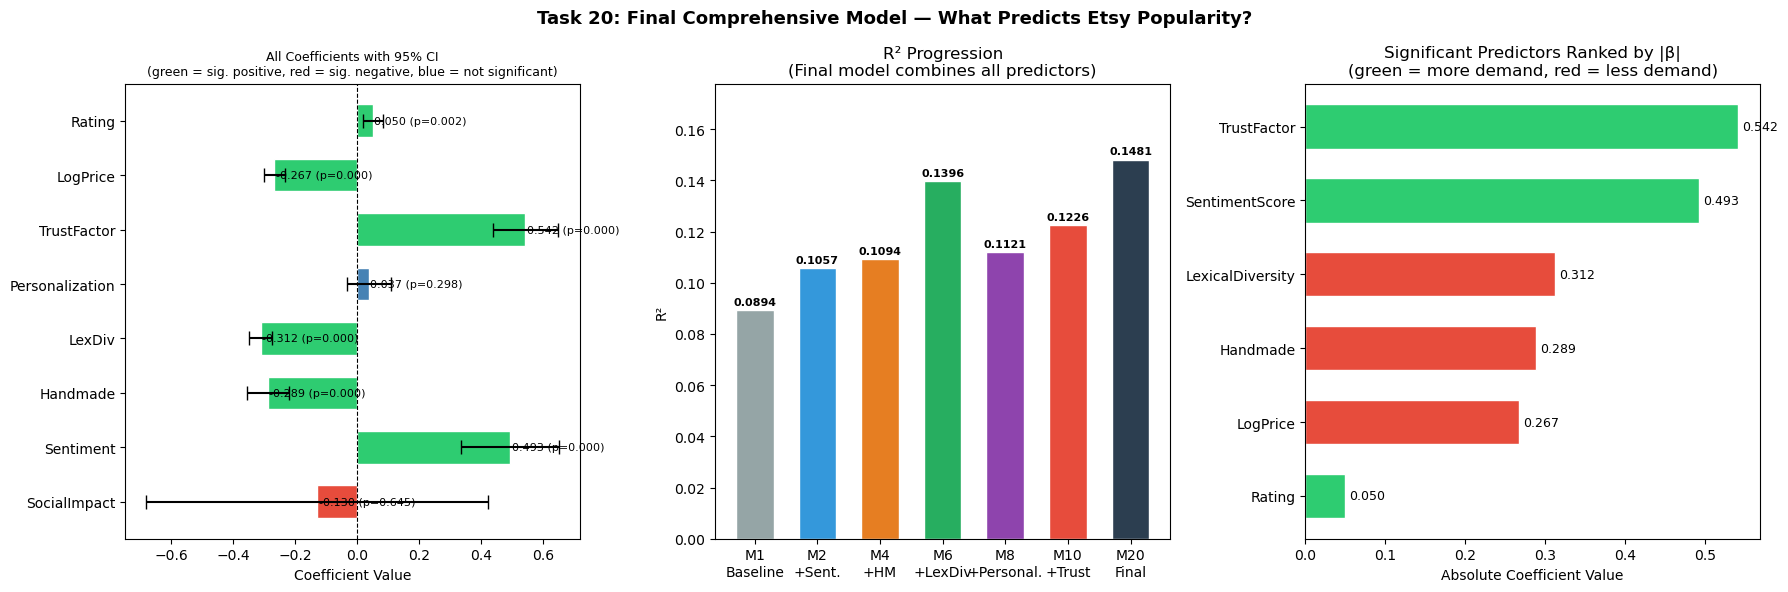


Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/viz/task5_regression/model_final.png


In [153]:
# =============================================================================
# Visualization — 3 plots
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Task 20: Final Comprehensive Model — What Predicts Etsy Popularity?',
             fontsize=13, fontweight='bold')

# Plot 1: Coefficient plot — all predictors
key_vars_plot = ['SocialImpact', 'SentimentScore', 'Handmade',
                 'lexical_diversity_std', 'personalization', 'trust_factor',
                 'LogPrice_winsorized_std', 'average_rating_std']
labels_plot   = ['SocialImpact', 'Sentiment', 'Handmade',
                 'LexDiv', 'Personalization', 'TrustFactor',
                 'LogPrice', 'Rating']
coefs_plot    = model_final.params[key_vars_plot]
cis_plot      = model_final.conf_int().loc[key_vars_plot]
colors_plot   = ['#2ecc71' if model_final.pvalues[v] < 0.05
                 else '#e74c3c' if model_final.params[v] < 0
                 else 'steelblue'
                 for v in key_vars_plot]

axes[0].barh(labels_plot, coefs_plot.values,
             xerr=[(coefs_plot.values - cis_plot[0].values),
                   (cis_plot[1].values - coefs_plot.values)],
             color=colors_plot, edgecolor='white', height=0.6,
             error_kw=dict(ecolor='black', capsize=5))
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('All Coefficients with 95% CI\n'
                  '(green = sig. positive, red = sig. negative, '
                  'blue = not significant)',
                  fontsize=9)
axes[0].set_xlabel('Coefficient Value')
for i, v in enumerate(key_vars_plot):
    coef = model_final.params[v]
    p    = model_final.pvalues[v]
    axes[0].text(coef + 0.005, i, f'{coef:.3f} (p={p:.3f})',
                 va='center', fontsize=8)

# Plot 2: R² progression — individual vs combined
model_r2s    = [0.0894, 0.1057, 0.1094, 0.1396, 0.1121, 0.1226,
                model_final.rsquared]
model_labels = ['M1\nBaseline', 'M2\n+Sent.', 'M4\n+HM',
                'M6\n+LexDiv', 'M8\n+Personal.', 'M10\n+Trust',
                'M20\nFinal']
bar_colors   = ['#95a5a6', '#3498db', '#e67e22',
                '#27ae60', '#8e44ad', '#e74c3c', '#2c3e50']
bars = axes[1].bar(model_labels, model_r2s,
                   color=bar_colors, edgecolor='white', width=0.6)
axes[1].set_title('R² Progression\n(Final model combines all predictors)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, max(model_r2s) * 1.2)
for bar, val in zip(bars, model_r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')

# Plot 3: Ranked predictor importance (absolute β, significant only)
sig_vars   = [(label, abs(model_final.params[var]),
               model_final.params[var] > 0)
              for var, label in key_vars_final
              if model_final.pvalues[var] < 0.05]
sig_vars   = sorted(sig_vars, key=lambda x: x[1])
sig_labels = [x[0] for x in sig_vars]
sig_vals   = [x[1] for x in sig_vars]
sig_colors = ['#2ecc71' if x[2] else '#e74c3c' for x in sig_vars]

axes[2].barh(sig_labels, sig_vals,
             color=sig_colors, edgecolor='white', height=0.6)
axes[2].set_title('Significant Predictors Ranked by |β|\n'
                  '(green = more demand, red = less demand)')
axes[2].set_xlabel('Absolute Coefficient Value')
for i, (label, val, pos) in enumerate(sig_vars):
    axes[2].text(val + 0.005, i,
                 f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{VIZ5}/model_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {VIZ5}/model_final.png")


In [154]:
# Save summary
with open(f'{OUTPUTS}/model_final_summary.txt', 'w') as f:
    f.write(model_final.summary().as_text())
print(f"Saved: {OUTPUTS}/model_final_summary.txt")
print(f"\n✓ Task 20 Complete — Final Comprehensive Model fitted")

Saved: /Users/suryamothukuri/Documents/IU Bloomington/Prof. Krista Li/Etsy Retail Marketing/outputs/model_final_summary.txt

✓ Task 20 Complete — Final Comprehensive Model fitted
